# Dislocation Study on Perp aggTrades

## Goal
- Fix notebook import path so `rule_backtest` can be imported reliably.
- Use cached perp aggTrades to test a dislocation strategy.
- Dislocation definition (long):
  - `vol_up` proxy: volatility > rolling 90% quantile
  - price below `rolling_high_i * (1 - xi_i)` for lookbacks `i in {5, 15, 30, 70}`
  - any i satisfied => price-down condition is true
- Mean-reversion exit (long): volatility falls back below rolling 50% quantile.
- Short side is symmetric using rolling lows.
- Record at entry: return since triggering high, vol change since triggering high, and spot/vol beta.

## Research flow
1. Load perp aggTrades and build bars.
2. Build dislocation events and entry diagnostics.
3. Run strategy-level backtest with transaction cost.
4. Run event-study forward returns.
5. Do a light parameter sweep for robustness.

In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def locate_repo_root() -> Path:
    """Locate repo root so notebook can import local modules reliably."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for c in candidates:
        if (c / "rule_backtest").exists() and (c / "utilities").exists():
            return c
    raise FileNotFoundError("Cannot locate repo root containing rule_backtest and utilities")


ROOT = locate_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from rule_backtest.data_loader import load_cached_trades, build_time_bars


SYMBOL = "SOL/USDC"
CACHE_SUBDIR = "trades_perp"  # perp aggTrades
BAR_FREQ = "1min"
CACHE_ROOT = Path("/Volumes/Lexar/mean_reversion_data/cache")
PLOT_OUTPUT_DIR = Path("/Volumes/Lexar/mean_reversion_data/plots/ofi_study")
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

trades = load_cached_trades(symbol=SYMBOL, cache_subdir=CACHE_SUBDIR, cache_dir=CACHE_ROOT)
bars = build_time_bars(trades, freq=BAR_FREQ).sort_index().copy()
bars["ret_1"] = bars["close"].pct_change().fillna(0.0)

print(f"Repo root: {ROOT}")
print(f"Cache root: {CACHE_ROOT}")
print(f"Loaded trades: {len(trades):,}")
print(f"Bars ({BAR_FREQ}): {len(bars):,}")
print(f"Bar range: {bars.index.min()} -> {bars.index.max()}")

bars.head()


Repo root: /Users/quqiancheng/mean_reversion_cta_pm
Cache root: /Volumes/Lexar/mean_reversion_data/cache
Loaded trades: 12,826,727
Bars (1min): 186,706
Bar range: 2025-12-31 16:00:00+00:00 -> 2026-05-10 08:10:00+00:00


,open,high,low,close,volume,n_trades,buy_volume,sell_volume,ret_1
timestamp,,,,,,,,,
2025-12-31 16:00:00+00:00,125.45,125.58,125.43,125.55,5586.44,111,2876.21,2710.23,0.000000
2025-12-31 16:01:00+00:00,125.56,125.62,125.48,125.50,1479.28,71,1080.34,398.94,-0.000398
2025-12-31 16:02:00+00:00,125.50,125.57,125.42,125.44,3169.23,67,2015.86,1153.37,-0.000478
2025-12-31 16:03:00+00:00,125.44,125.45,125.21,125.28,5647.69,107,1466.87,4180.82,-0.001276
2025-12-31 16:04:00+00:00,125.29,125.32,125.22,125.26,2569.19,60,1427.19,1142.00,-0.000160


In [5]:
# OPTIMIZED_V2
from collections import deque


LOOKBACKS = [5, 15, 30, 70]
# vol means volatility here (not volume)
RV_WINDOW = 30
VOL_REGIME_WINDOW = 240
OPEN_VOL_Q = 0.90
CLOSE_VOL_Q = 0.50
BETA_WINDOW = 180
MIN_CONFIRMATIONS = 1

# data-driven xi calibration to reduce arbitrariness
AUTO_CALIBRATE_XI = True
XI_QUANTILE = 0.90
XI_BOUNDS = (0.0008, 0.02)
XI_MAP_MANUAL = {
    5: 0.0015,
    15: 0.0025,
    30: 0.0035,
    70: 0.0050,
}


def rolling_extreme_with_idx(values: np.ndarray, window: int, mode: str = "max"):
    """Return rolling extreme over [t-window, t-1] and source index."""
    n = len(values)
    extreme = np.full(n, np.nan)
    extreme_idx = np.full(n, -1, dtype=np.int64)
    dq = deque()

    if mode not in {"max", "min"}:
        raise ValueError("mode must be 'max' or 'min'")

    for t in range(n):
        prev = t - 1
        if prev >= 0:
            if mode == "max":
                while dq and values[dq[-1]] <= values[prev]:
                    dq.pop()
            else:
                while dq and values[dq[-1]] >= values[prev]:
                    dq.pop()
            dq.append(prev)

        min_allowed = t - window
        while dq and dq[0] < min_allowed:
            dq.popleft()

        if t >= window and dq:
            idx = dq[0]
            extreme[t] = values[idx]
            extreme_idx[t] = idx

    return extreme, extreme_idx


def beta_since_anchor(
    spot_arr: np.ndarray,
    vol_arr: np.ndarray,
    anchor_idx_arr: np.ndarray,
    target_mask = None,
    min_points: int = 3,
) -> np.ndarray:
    """O(n) prefix-sum beta since anchor."""
    n = len(spot_arr)
    out = np.full(n, np.nan)

    if target_mask is None:
        target_mask = np.ones(n, dtype=bool)

    finite = np.isfinite(spot_arr) & np.isfinite(vol_arr)
    x = np.where(finite, spot_arr, 0.0)
    y = np.where(finite, vol_arr, 0.0)

    cnt = np.zeros(n + 1, dtype=np.int64)
    sx = np.zeros(n + 1, dtype=np.float64)
    sy = np.zeros(n + 1, dtype=np.float64)
    sxy = np.zeros(n + 1, dtype=np.float64)
    sy2 = np.zeros(n + 1, dtype=np.float64)

    cnt[1:] = np.cumsum(finite.astype(np.int64))
    sx[1:] = np.cumsum(x)
    sy[1:] = np.cumsum(y)
    sxy[1:] = np.cumsum(x * y)
    sy2[1:] = np.cumsum(y * y)

    target_idx = np.flatnonzero(target_mask)
    for t in target_idx:
        a = int(anchor_idx_arr[t])
        if a < 0 or a > t:
            continue

        spot_anchor = spot_arr[a]
        vol_anchor = vol_arr[a]
        if (
            not np.isfinite(spot_anchor)
            or not np.isfinite(vol_anchor)
            or abs(spot_anchor) < 1e-12
            or abs(vol_anchor) < 1e-12
        ):
            continue

        l, r = a, t + 1
        n_seg = cnt[r] - cnt[l]
        if n_seg < min_points:
            continue

        sum_x = sx[r] - sx[l]
        sum_y = sy[r] - sy[l]
        sum_xy = sxy[r] - sxy[l]
        sum_y2 = sy2[r] - sy2[l]

        mean_x = sum_x / n_seg
        mean_y = sum_y / n_seg

        cov_xy = sum_xy / n_seg - mean_x * mean_y
        var_y = sum_y2 / n_seg - mean_y * mean_y
        if var_y < 1e-14:
            continue

        beta_raw = cov_xy / var_y
        out[t] = (vol_anchor / spot_anchor) * beta_raw

    return out


def prepare_base_features(
    bars_df: pd.DataFrame,
    rv_window: int,
    vol_regime_window: int,
    open_vol_q: float,
    close_vol_q: float,
    beta_window: int,
) -> pd.DataFrame:
    """One-time feature build reused by scans."""
    df = bars_df.copy()

    df["log_ret"] = np.log(df["close"]).diff()
    df["volatility"] = df["log_ret"].rolling(rv_window, min_periods=max(10, rv_window // 3)).std()

    df["vol_q_open"] = df["volatility"].rolling(
        vol_regime_window, min_periods=max(30, vol_regime_window // 4)
    ).quantile(open_vol_q)
    df["vol_q_close"] = df["volatility"].rolling(
        vol_regime_window, min_periods=max(30, vol_regime_window // 4)
    ).quantile(close_vol_q)
    df["vol_up"] = df["volatility"] > df["vol_q_open"]
    df["vol_mean_revert"] = df["volatility"] <= df["vol_q_close"]

    tot = df["buy_volume"] + df["sell_volume"]
    df["taker_vol_imb"] = (df["buy_volume"] - df["sell_volume"]) / (tot + 1e-12)

    # get the absorption: actual return's deviation from the expected return based on taker imbalance
    imb_window = max(60, beta_window // 2)
    imb_cov = df["ret_1"].rolling(imb_window, min_periods=max(30, imb_window // 4)).cov(df["taker_vol_imb"])
    imb_var = df["taker_vol_imb"].rolling(imb_window, min_periods=max(30, imb_window // 4)).var()
    df["imb_ret_beta"] = imb_cov / (imb_var + 1e-12)
    df["ret_from_imb_expect"] = df["imb_ret_beta"] * df["taker_vol_imb"]
    df["absorption_resid"] = df["ret_1"] - df["ret_from_imb_expect"]

    # sell absorption: sell pressure but downside under-delivers (resid > 0)
    sell_pressure = df["taker_vol_imb"] < 0
    sell_score_dense = np.where(sell_pressure, df["absorption_resid"], 0.0)
    df["sell_absorption_score_raw"] = np.where(sell_pressure, df["absorption_resid"], np.nan)
    df["sell_absorption_score"] = sell_score_dense

    # buy absorption: buy pressure but upside under-delivers (-resid > 0)
    buy_pressure = df["taker_vol_imb"] > 0
    buy_score_dense = np.where(buy_pressure, -df["absorption_resid"], 0.0)
    df["buy_absorption_score_raw"] = np.where(buy_pressure, -df["absorption_resid"], np.nan)
    df["buy_absorption_score"] = buy_score_dense

    # absorption zscores (dense rolling for stability)
    abs_win = max(120, imb_window)
    abs_min_obs = max(20, abs_win // 6)

    sell_ser = pd.Series(sell_score_dense, index=df.index)
    sell_mu = sell_ser.rolling(abs_win, min_periods=abs_min_obs).mean()
    sell_sd = sell_ser.rolling(abs_win, min_periods=abs_min_obs).std(ddof=0)
    sell_z_dense = (sell_ser - sell_mu) / (sell_sd + 1e-12)

    buy_ser = pd.Series(buy_score_dense, index=df.index)
    buy_mu = buy_ser.rolling(abs_win, min_periods=abs_min_obs).mean()
    buy_sd = buy_ser.rolling(abs_win, min_periods=abs_min_obs).std(ddof=0)
    buy_z_dense = (buy_ser - buy_mu) / (buy_sd + 1e-12)

    min_side_obs = max(10, abs_win // 8)
    sell_count = sell_pressure.astype(int).rolling(abs_win, min_periods=1).sum()
    buy_count = buy_pressure.astype(int).rolling(abs_win, min_periods=1).sum()

    df["sell_absorption_z"] = np.where(sell_pressure, sell_z_dense, 0.0)
    df["buy_absorption_z"] = np.where(buy_pressure, buy_z_dense, 0.0)

    df["sell_absorption_z"] = np.where(sell_count >= min_side_obs, df["sell_absorption_z"], np.nan)
    df["buy_absorption_z"] = np.where(buy_count >= min_side_obs, df["buy_absorption_z"], np.nan)

    # positive => sell side more absorbed; negative => buy side more absorbed
    df["net_absorption_z"] = df["sell_absorption_z"].fillna(0.0) - df["buy_absorption_z"].fillna(0.0)

    df["sell_absorption_flag"] = sell_pressure & (df["sell_absorption_z"] > 1.0)
    df["buy_absorption_flag"] = buy_pressure & (df["buy_absorption_z"] > 1.0)

    return df


def build_extreme_cache(base_df: pd.DataFrame, lookbacks: list[int]) -> dict:
    """Cache all rolling high/low derived arrays once."""
    close_arr = base_df["close"].to_numpy()
    high_arr = base_df["high"].to_numpy()
    low_arr = base_df["low"].to_numpy()
    vol_arr = base_df["volatility"].to_numpy()

    cache = {}
    for lb in lookbacks:
        rolling_high, high_idx = rolling_extreme_with_idx(high_arr, lb, mode="max")
        rolling_low, low_idx = rolling_extreme_with_idx(low_arr, lb, mode="min")

        ret_since_high = close_arr / rolling_high - 1.0
        ret_since_low = close_arr / rolling_low - 1.0

        vol_at_high = np.where(high_idx >= 0, vol_arr[high_idx], np.nan)
        vol_at_low = np.where(low_idx >= 0, vol_arr[low_idx], np.nan)

        vchg_since_high = vol_arr / (vol_at_high + 1e-12) - 1.0
        vchg_since_low = vol_arr / (vol_at_low + 1e-12) - 1.0

        cache[lb] = {
            "rolling_high": rolling_high,
            "rolling_low": rolling_low,
            "high_idx": high_idx,
            "low_idx": low_idx,
            "ret_since_high": ret_since_high,
            "ret_since_low": ret_since_low,
            "vchg_since_high": vchg_since_high,
            "vchg_since_low": vchg_since_low,
        }
    return cache


def calibrate_xi_map_from_history(
    lookbacks,
    extreme_cache: dict,
    quantile: float = 0.90,
    bounds=(0.0008, 0.02),
) -> dict:
    out = {}
    for lb in lookbacks:
        c = extreme_cache[lb]
        dd = np.clip(-c["ret_since_high"], 0.0, None)
        uu = np.clip(c["ret_since_low"], 0.0, None)
        candidate = np.nanquantile(np.concatenate([dd, uu]), quantile)
        out[lb] = float(np.clip(candidate, bounds[0], bounds[1]))
    return out


def build_dislocation_signals(
    base_df: pd.DataFrame,
    lookbacks,
    xi_map,
    min_confirmations: int = 1,
    extreme_cache = None,
    include_per_lb_columns: bool = True,
) -> pd.DataFrame:
    df = base_df.copy()
    n = len(df)

    if extreme_cache is None:
        extreme_cache = build_extreme_cache(df, list(lookbacks))

    close_arr = df["close"].to_numpy()
    k = len(lookbacks)
    long_cond_mat = np.zeros((n, k), dtype=bool)
    short_cond_mat = np.zeros((n, k), dtype=bool)
    long_ret_mat = np.empty((n, k), dtype=float)
    short_ret_mat = np.empty((n, k), dtype=float)
    long_vchg_mat = np.empty((n, k), dtype=float)
    short_vchg_mat = np.empty((n, k), dtype=float)
    high_idx_mat = np.empty((n, k), dtype=np.int64)
    low_idx_mat = np.empty((n, k), dtype=np.int64)
    long_thr_mat = np.empty((n, k), dtype=float)

    for j, lb in enumerate(lookbacks):
        xi = xi_map[lb]
        c = extreme_cache[lb]

        rolling_high = c["rolling_high"]
        rolling_low = c["rolling_low"]
        high_idx = c["high_idx"]
        low_idx = c["low_idx"]
        ret_since_high = c["ret_since_high"]
        ret_since_low = c["ret_since_low"]
        vchg_since_high = c["vchg_since_high"]
        vchg_since_low = c["vchg_since_low"]

        long_threshold = rolling_high * (1.0 - xi)
        short_threshold = rolling_low * (1.0 + xi)

        long_cond = close_arr <= long_threshold
        short_cond = close_arr >= short_threshold

        long_cond_mat[:, j] = np.nan_to_num(long_cond, nan=False).astype(bool)
        short_cond_mat[:, j] = np.nan_to_num(short_cond, nan=False).astype(bool)
        long_ret_mat[:, j] = ret_since_high
        short_ret_mat[:, j] = ret_since_low
        long_vchg_mat[:, j] = vchg_since_high
        short_vchg_mat[:, j] = vchg_since_low
        high_idx_mat[:, j] = high_idx
        low_idx_mat[:, j] = low_idx
        long_thr_mat[:, j] = long_threshold

        if include_per_lb_columns:
            df[f"high_{lb}"] = rolling_high
            df[f"low_{lb}"] = rolling_low
            df[f"high_idx_{lb}"] = high_idx
            df[f"low_idx_{lb}"] = low_idx
            df[f"long_threshold_{lb}"] = long_threshold
            df[f"short_threshold_{lb}"] = short_threshold

    df["long_cond_count"] = long_cond_mat.sum(axis=1)
    df["short_cond_count"] = short_cond_mat.sum(axis=1)
    df["price_down_any_i"] = df["long_cond_count"] >= 1
    df["price_up_any_i"] = df["short_cond_count"] >= 1
    df["long_threshold_min"] = np.nanmin(long_thr_mat, axis=1)

    df["long_entry"] = df["vol_up"] & (df["long_cond_count"] >= min_confirmations)
    df["short_entry"] = df["vol_up"] & (df["short_cond_count"] >= min_confirmations)

    long_score = np.where(long_cond_mat, -long_ret_mat, -np.inf)
    short_score = np.where(short_cond_mat, short_ret_mat, -np.inf)

    long_best_idx = np.argmax(long_score, axis=1)
    short_best_idx = np.argmax(short_score, axis=1)

    lookbacks_arr = np.asarray(lookbacks)
    has_long = long_cond_mat.any(axis=1)
    has_short = short_cond_mat.any(axis=1)
    row_ids = np.arange(n)

    df["long_trigger_i"] = np.where(has_long, lookbacks_arr[long_best_idx], np.nan)
    df["short_trigger_i"] = np.where(has_short, lookbacks_arr[short_best_idx], np.nan)

    df["long_return_since_high"] = np.where(has_long, long_ret_mat[row_ids, long_best_idx], np.nan)
    df["short_return_since_low"] = np.where(has_short, short_ret_mat[row_ids, short_best_idx], np.nan)
    df["long_vol_change_since_high"] = np.where(has_long, long_vchg_mat[row_ids, long_best_idx], np.nan)
    df["short_vol_change_since_low"] = np.where(has_short, short_vchg_mat[row_ids, short_best_idx], np.nan)

    long_anchor_idx = np.where(has_long, high_idx_mat[row_ids, long_best_idx], -1)
    short_anchor_idx = np.where(has_short, low_idx_mat[row_ids, short_best_idx], -1)
    df["long_anchor_idx"] = long_anchor_idx
    df["short_anchor_idx"] = short_anchor_idx

    long_entry_mask = df["long_entry"].to_numpy(dtype=bool)
    short_entry_mask = df["short_entry"].to_numpy(dtype=bool)
    vol_arr = df["volatility"].to_numpy()

    df["long_beta_since_high"] = beta_since_anchor(
        close_arr,
        vol_arr,
        long_anchor_idx.astype(np.int64),
        target_mask=long_entry_mask,
        min_points=3,
    )
    df["short_beta_since_low"] = beta_since_anchor(
        close_arr,
        vol_arr,
        short_anchor_idx.astype(np.int64),
        target_mask=short_entry_mask,
        min_points=3,
    )

    df["entry_return_since_high"] = np.where(df["long_entry"], df["long_return_since_high"], np.nan)
    df["entry_vol_change_since_high"] = np.where(df["long_entry"], df["long_vol_change_since_high"], np.nan)
    df["entry_beta_since_high"] = np.where(df["long_entry"], df["long_beta_since_high"], np.nan)
    df["entry_spot_vol_beta"] = df["entry_beta_since_high"]

    return df


BASE_FEATURES = prepare_base_features(
    bars,
    rv_window=RV_WINDOW,
    vol_regime_window=VOL_REGIME_WINDOW,
    open_vol_q=OPEN_VOL_Q,
    close_vol_q=CLOSE_VOL_Q,
    beta_window=BETA_WINDOW,
)

EXTREME_CACHE = build_extreme_cache(BASE_FEATURES, LOOKBACKS)

if AUTO_CALIBRATE_XI:
    XI_MAP = calibrate_xi_map_from_history(
        LOOKBACKS,
        extreme_cache=EXTREME_CACHE,
        quantile=XI_QUANTILE,
        bounds=XI_BOUNDS,
    )
else:
    XI_MAP = XI_MAP_MANUAL.copy()

print("Using XI_MAP:", XI_MAP)

signal_df = build_dislocation_signals(
    BASE_FEATURES,
    lookbacks=LOOKBACKS,
    xi_map=XI_MAP,
    min_confirmations=MIN_CONFIRMATIONS,
    extreme_cache=EXTREME_CACHE,
    include_per_lb_columns=True,
)

signal_df[[
    "close", "volatility", "vol_q_open", "vol_q_close", "taker_vol_imb", "sell_absorption_z",
    "buy_absorption_z",
    "net_absorption_z",
    "long_trigger_i", "long_threshold_min", "entry_return_since_high", "entry_vol_change_since_high",
    "entry_beta_since_high", "long_entry", "short_entry",
]].tail(10)





Using XI_MAP: {5: 0.0033483419393217644, 15: 0.00557071396089136, 30: 0.007798143782139982, 70: 0.011890205936913168}


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_30930/912610489.py:325: RuntimeWarning: All-NaN slice encountered
  df["long_threshold_min"] = np.nanmin(long_thr_mat, axis=1)


,close,volatility,vol_q_open,vol_q_close,taker_vol_imb,sell_absorption_z,buy_absorption_z,net_absorption_z,long_trigger_i,long_threshold_min,entry_return_since_high,entry_vol_change_since_high,entry_beta_since_high,long_entry,short_entry
timestamp,,,,,,,,,,,,,,,
2026-05-10 08:01:00+00:00,93.41,0.000277,0.000426,0.000336,0.937837,0.000000,0.016916,-0.016916,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:02:00+00:00,93.40,0.000274,0.000426,0.000336,-0.132590,-0.437825,0.000000,-0.437825,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:03:00+00:00,93.46,0.000297,0.000422,0.000334,0.794866,0.000000,-1.730386,1.730386,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:04:00+00:00,93.43,0.000303,0.000421,0.000333,-0.186892,-1.651752,0.000000,-1.651752,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:05:00+00:00,93.44,0.000304,0.000420,0.000332,0.776040,0.000000,0.851997,-0.851997,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:06:00+00:00,93.45,0.000304,0.000417,0.000332,-0.353246,1.391424,0.000000,1.391424,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:07:00+00:00,93.50,0.000297,0.000416,0.000330,0.786545,0.000000,-1.270589,1.270589,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:08:00+00:00,93.55,0.000311,0.000416,0.000329,0.920856,0.000000,-1.013620,1.013620,NaN,92.457433,NaN,NaN,NaN,False,False
2026-05-10 08:09:00+00:00,93.84,0.000643,0.000416,0.000329,0.130352,0.000000,-8.809880,8.809880,NaN,92.457433,NaN,NaN,NaN,False,True


In [ ]:
# OPTIMIZED_V2

def plot_dislocation_regime_html(
    df: pd.DataFrame,
    lookbacks_for_plot=(5, 30, 70),
    html_name: str = "dislocation_regime_view.html",
    max_points: int = 120000,
    price_as_pct: bool = True,
    clip_indicator_q: float = 0.995,
):
    if len(df) > max_points:
        step = int(np.ceil(len(df) / max_points))
        d = df.iloc[::step].copy()
    else:
        d = df.copy()

    fig = make_subplots(
        rows=3,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.06,
        subplot_titles=(
            "Volatility Regime (vol, q90, q50)",
            "Price + Thresholds",
            "Taker Imbalance + Absorption",
        ),
    )

    # Panel 1: volatility and quantile thresholds
    fig.add_trace(go.Scattergl(x=d.index, y=d["volatility"], mode="lines", name="volatility"), row=1, col=1)
    fig.add_trace(go.Scattergl(x=d.index, y=d["vol_q_open"], mode="lines", name="vol q90", line=dict(dash="dash")), row=1, col=1)
    fig.add_trace(go.Scattergl(x=d.index, y=d["vol_q_close"], mode="lines", name="vol q50", line=dict(dash="dash")), row=1, col=1)

    # Panel 2: price/thresholds on comparable scale
    if price_as_pct:
        base = float(d["close"].iloc[0]) if len(d) else 1.0
        d["close_plot"] = d["close"] / base - 1.0
        for lb in lookbacks_for_plot:
            col = f"long_threshold_{lb}"
            if col in d.columns:
                d[f"{col}_plot"] = d[col] / base - 1.0
        d["long_threshold_min_plot"] = d["long_threshold_min"] / base - 1.0
        y_title_price = "Relative move (%)"
    else:
        d["close_plot"] = d["close"]
        for lb in lookbacks_for_plot:
            col = f"long_threshold_{lb}"
            if col in d.columns:
                d[f"{col}_plot"] = d[col]
        d["long_threshold_min_plot"] = d["long_threshold_min"]
        y_title_price = "Price"

    fig.add_trace(go.Scattergl(x=d.index, y=d["close_plot"], mode="lines", name="close"), row=2, col=1)
    for lb in lookbacks_for_plot:
        col_plot = f"long_threshold_{lb}_plot"
        if col_plot in d.columns:
            fig.add_trace(
                go.Scattergl(x=d.index, y=d[col_plot], mode="lines", name=f"thr_{lb}", line=dict(dash="dot")),
                row=2,
                col=1,
            )
    fig.add_trace(
        go.Scattergl(x=d.index, y=d["long_threshold_min_plot"], mode="lines", name="threshold_min_used"),
        row=2,
        col=1,
    )

    # Panel 3: imbalance + absorption (winsorized for readability)
    ind_cols = [c for c in ["taker_vol_imb", "sell_absorption_z", "buy_absorption_z", "net_absorption_z"] if c in d.columns]
    for col in ind_cols:
        series = d[col].astype(float)
        if series.notna().any() and 0.5 < clip_indicator_q < 1.0:
            q = float(series.abs().quantile(clip_indicator_q))
            if np.isfinite(q) and q > 0:
                series = series.clip(-q, q)
        line_kwargs = {}
        if "sell_absorption" in col:
            line_kwargs = {"dash": "dash"}
        elif "buy_absorption" in col:
            line_kwargs = {"dash": "dot"}
        fig.add_trace(go.Scattergl(x=d.index, y=series, mode="lines", name=col, line=line_kwargs), row=3, col=1)

    fig.update_layout(height=1050, showlegend=True, title_text="Dislocation Pre-Backtest Regime Check", template="plotly_white", hovermode="x unified")
    fig.update_xaxes(title_text="Time", row=3, col=1)
    fig.update_yaxes(title_text="Volatility", row=1, col=1)
    fig.update_yaxes(title_text=y_title_price, row=2, col=1)
    fig.update_yaxes(title_text="Imb / Absorption (clipped)", row=3, col=1)

    html_path = PLOT_OUTPUT_DIR / html_name
    fig.write_html(str(html_path), include_plotlyjs="cdn")
    print(f"Saved interactive HTML: {html_path}")
    return fig, html_path


_fig, _html_path = plot_dislocation_regime_html(signal_df)
# _fig



In [ ]:
# OPTIMIZED_V2

def run_dislocation_backtest(df: pd.DataFrame, fee_bps: float = 2.0):
    bt = df.copy()
    n = len(bt)

    long_entry_arr = bt["long_entry"].to_numpy(dtype=bool)
    short_entry_arr = bt["short_entry"].to_numpy(dtype=bool)
    vol_revert_arr = bt["vol_mean_revert"].to_numpy(dtype=bool)
    close_arr = bt["close"].to_numpy(dtype=float)

    pos = np.zeros(n, dtype=np.int8)
    trade_log = []
    active_trade = None
    entry_i = -1

    for i in range(1, n):
        prev = pos[i - 1]
        long_entry = long_entry_arr[i]
        short_entry = short_entry_arr[i]
        vol_revert = vol_revert_arr[i]

        if prev == 0:
            if long_entry and not short_entry:
                pos[i] = 1
                entry_i = i
                active_trade = {
                    "entry_ts": bt.index[i], "side": "long", "entry_price": close_arr[i],
                    "trigger_i": bt["long_trigger_i"].iat[i],
                    "return_since_high": bt["long_return_since_high"].iat[i],
                    "vol_change_since_high": bt["long_vol_change_since_high"].iat[i],
                    "beta_since_high": bt["long_beta_since_high"].iat[i],
                    "spot_vol_beta": bt["long_beta_since_high"].iat[i],
                }
            elif short_entry and not long_entry:
                pos[i] = -1
                entry_i = i
                active_trade = {
                    "entry_ts": bt.index[i], "side": "short", "entry_price": close_arr[i],
                    "trigger_i": bt["short_trigger_i"].iat[i],
                    "return_since_low": bt["short_return_since_low"].iat[i],
                    "vol_change_since_low": bt["short_vol_change_since_low"].iat[i],
                    "beta_since_low": bt["short_beta_since_low"].iat[i],
                    "spot_vol_beta": bt["short_beta_since_low"].iat[i],
                }
            else:
                pos[i] = 0
        elif prev == 1:
            if vol_revert or short_entry:
                pos[i] = 0
                if active_trade is not None:
                    active_trade["exit_ts"] = bt.index[i]
                    active_trade["exit_price"] = close_arr[i]
                    active_trade["hold_bars"] = i - entry_i
                    active_trade["trade_ret"] = close_arr[i] / active_trade["entry_price"] - 1.0
                    trade_log.append(active_trade)
                    active_trade = None
                    entry_i = -1
            else:
                pos[i] = 1
        else:
            if vol_revert or long_entry:
                pos[i] = 0
                if active_trade is not None:
                    active_trade["exit_ts"] = bt.index[i]
                    active_trade["exit_price"] = close_arr[i]
                    active_trade["hold_bars"] = i - entry_i
                    active_trade["trade_ret"] = 1.0 - close_arr[i] / active_trade["entry_price"]
                    trade_log.append(active_trade)
                    active_trade = None
                    entry_i = -1
            else:
                pos[i] = -1

    bt["position"] = pos
    bt["turnover"] = np.abs(np.diff(pos, prepend=0)).astype(float)
    bt["raw_strategy_ret"] = np.roll(pos, 1).astype(float) * bt["ret_1"].to_numpy(dtype=float)
    bt.loc[bt.index[0], "raw_strategy_ret"] = 0.0
    bt["cost"] = bt["turnover"] * (fee_bps * 1e-4)
    bt["strategy_ret"] = bt["raw_strategy_ret"] - bt["cost"]
    bt["equity"] = (1.0 + bt["strategy_ret"]).cumprod()

    minutes = max(int(pd.Timedelta(BAR_FREQ).total_seconds() // 60), 1)
    bars_per_year = int((365 * 24 * 60) / minutes)

    ann_ret = bt["strategy_ret"].mean() * bars_per_year
    ann_vol = bt["strategy_ret"].std(ddof=0) * np.sqrt(bars_per_year)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    cummax = bt["equity"].cummax()
    dd = bt["equity"] / cummax - 1.0

    trades_df = pd.DataFrame(trade_log)
    metrics = {
        "bars": len(bt),
        "entries": int(((bt["position"].shift(1).fillna(0) == 0) & (bt["position"] != 0)).sum()),
        "closed_trades": len(trades_df),
        "invested_ratio": (bt["position"] != 0).mean(),
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": dd.min(),
        "total_return": bt["equity"].iat[-1] - 1.0,
    }
    return bt, trades_df, metrics


bt_df, trades_df, metrics = run_dislocation_backtest(signal_df, fee_bps=2.0)
metrics



In [ ]:
# Requested entry diagnostics logging
print("Entry diagnostics (long-side since-high fields):")
if len(trades_df) > 0:
    cols = [
        "entry_ts",
        "side",
        "trigger_i",
        "return_since_high",
        "vol_change_since_high",
        "beta_since_high",
        "spot_vol_beta",
        "trade_ret",
    ]
    display(trades_df[[c for c in cols if c in trades_df.columns]].head(20))
else:
    print("No closed trades in sample.")


def event_study(df: pd.DataFrame, entry_col: str, side: int, horizons=(1, 5, 15, 30, 70)) -> pd.DataFrame:
    out = []
    idx = np.where(df[entry_col].fillna(False).values)[0]
    close = df["close"].values

    for h in horizons:
        rets = []
        for i in idx:
            j = i + h
            if j < len(df):
                r = close[j] / close[i] - 1.0
                rets.append(side * r)
        if len(rets) == 0:
            out.append({"horizon": h, "count": 0, "mean_ret": np.nan, "median_ret": np.nan, "win_rate": np.nan})
        else:
            arr = np.array(rets)
            out.append({
                "horizon": h,
                "count": len(arr),
                "mean_ret": arr.mean(),
                "median_ret": np.median(arr),
                "win_rate": (arr > 0).mean(),
            })
    return pd.DataFrame(out)


long_event = event_study(signal_df, "long_entry", side=1)
short_event = event_study(signal_df, "short_entry", side=-1)

print("Long event study (signed forward returns):")
display(long_event)
print("Short event study (signed forward returns):")
display(short_event)


In [ ]:
trades_df['is_beta_neg'] = np.where(trades_df.spot_vol_beta < 0, 1, 0)
trades_df.groupby('is_beta_neg')['trade_ret'].mean()

In [ ]:
long_trades_df.groupby('is_beta_neg')['trade_ret'].mean()

In [ ]:
# 计算 trades_df中trade_ret 与各特征的相关性；
# 包括 a*b 类型的交互特征

In [ ]:
# panick 应该对于 short 方向不太成立？

In [ ]:
trades_df['is_vol_chg_pos'] = np.where(trades_df.vol_change_since_high > 0, 1, 0)
trades_df.groupby('is_vol_chg_pos')['trade_ret'].mean()

In [ ]:
long_trades_df = trades_df[trades_df.side == 'long']
long_trades_df.groupby('is_vol_chg_pos')['trade_ret'].mean()

In [ ]:
# 筛选 vol chg since high > 0, 应该能排除大多数股价波动导致的错误信号（vol 已经高位，或者在 high 之后已经开始下跌，说明 dislo 已经到尾声）

In [ ]:
long_trades_df[['is_vol_chg_pos', ]]

In [ ]:
# OPTIMIZED_V2

def run_config(
    base_df: pd.DataFrame,
    extreme_cache: dict,
    xi_map: dict,
    min_confirmations: int,
    fee_bps: float,
):
    sig = build_dislocation_signals(
        base_df,
        lookbacks=sorted(xi_map.keys()),
        xi_map=xi_map,
        min_confirmations=min_confirmations,
        extreme_cache=extreme_cache,
        include_per_lb_columns=False,
    )
    bt, trades, m = run_dislocation_backtest(sig, fee_bps=fee_bps)
    return sig, bt, trades, m


base_xi = XI_MAP.copy()
scales = [0.7, 0.85, 1.0, 1.15, 1.3]
confirmations = [1, 2]

rows = []
for s in scales:
    xi_scaled = {k: v * s for k, v in base_xi.items()}
    for c in confirmations:
        _, _, trades_tmp, m = run_config(
            BASE_FEATURES,
            extreme_cache=EXTREME_CACHE,
            xi_map=xi_scaled,
            min_confirmations=c,
            fee_bps=2.0,
        )
        rows.append({
            "xi_scale": s,
            "confirmations": c,
            "sharpe": m["sharpe"],
            "annual_return": m["annual_return"],
            "max_drawdown": m["max_drawdown"],
            "entries": m["entries"],
            "closed_trades": len(trades_tmp),
            "invested_ratio": m["invested_ratio"],
            "total_return": m["total_return"],
        })

scan = pd.DataFrame(rows).sort_values(["sharpe", "annual_return"], ascending=False)
scan.head(10)



In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(bt_df.index, bt_df["equity"], label="Strategy equity")
axes[0].set_title("Dislocation strategy equity curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(bt_df.index, bt_df["close"], label="Close", alpha=0.8)
long_pts = bt_df.index[bt_df["long_entry"].fillna(False)]
short_pts = bt_df.index[bt_df["short_entry"].fillna(False)]
axes[1].scatter(long_pts, bt_df.loc[long_pts, "close"], marker="^", s=12, label="Long entry", alpha=0.6)
axes[1].scatter(short_pts, bt_df.loc[short_pts, "close"], marker="v", s=12, label="Short entry", alpha=0.6)
axes[1].set_title("Entry events on price")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(bt_df.index, bt_df["volatility"], label="Volatility proxy", alpha=0.8)
axes[2].plot(bt_df.index, bt_df["vol_q_open"], label="Volatility q90", alpha=0.9)
axes[2].plot(bt_df.index, bt_df["vol_q_close"], label="Volatility q50", alpha=0.9)
axes[2].set_title("Volatility regime proxy")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

metrics

In [ ]:
# 一定要叠加 加仓操作 去降低成本价（因为 vol 回归的时候不一定股价就一定回归到开仓时的价格）=> 但大概率 vol go up 的时候 spot price 继续跌，从而大概率获取更低成本价

# 去看不同的采样频段

# 看不同的时间窗口参数

## How to interpret results

- If event-study signed forward returns are positive for both long/short across multiple horizons, the dislocation definition is directionally meaningful.
- If backtest Sharpe stays positive after adding transaction costs and across nearby `xi_scale`/`confirmations`, the strategy idea is more robust.
- If results are highly sensitive to one setting (for example only one `xi_scale` works), treat it as overfit risk.
- Inspect `trades_df` entry diagnostics to validate your hypothesis on `return_since_high`, `vol_change_since_high`, and `spot_vol_beta`.

## Next research upgrades

- Add funding-rate and session filters (Asia/Europe/US) to isolate where dislocation resolves faster.
- Replace rolling-std volatility proxy with higher-frequency realized-vol or bipower variation proxy.
- Add hold-time stop and volatility-scaled sizing.
- Validate on rolling OOS splits instead of one full-sample backtest.

In [ ]:
# Legacy scratch cell kept for reference.
# Use the pipeline in Cells 1-7 instead (includes path fix + perp cache loading).
pass

事件驱动研究已在上方实现：通过 dislocation 事件定义开仓，再用 volatility 回归事件平仓。

#  采用更低频 
保证 alpha decay 时间 > 交易延迟；保证覆盖交易成本

## 5Min Panic -> Exhaustion -> Recovery Confirmation Framework (Long Only)

采用更低频（5min）后，研究目标变成三段式：
1. **Panic detection**：在 large drawdown 样本中识别更“恐慌”的子样本；
2. **Exhaustion proxy**：检验 `net_absorption_z` 是否能区分衰竭程度；
3. **Recovery confirmation**：先做事件层面的 forward return 统计（平仓规则暂缓）。

> 注：BTC/ETH returns 作为控制变量会在后续回归框架中加入，这里先不实现。

In [4]:
# 5min resample from aggTrades and feature prep (long-only framework)
BARS_5M_FREQ = "5min"
PANIC_LOOKBACKS_5M = [5, 15, 30, 70]
PANIC_HORIZONS_5M = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 30, 36, 42, 48, 54, 60, 72, 84, 96, 108, 120, 132, 144, 156, 168, 180, 192, 204, 216, 228, 240, 252, 264, 276, 288]  # 5m bars => up to 24h
# as 1-4h show reversal, the recovery might be longer

In [6]:
len(PANIC_HORIZONS_5M)

37

In [7]:
# 1m xi baseline -> 5m scaled baseline
XI_1M_BASE = {5: 0.0015, 15: 0.0025, 30: 0.0035, 70: 0.0050}
XI_5M_SCALE = np.sqrt(5.0)
XI_5M = {k: float(v * XI_5M_SCALE) for k, v in XI_1M_BASE.items()}

# build 5m bars directly from aggTrades
bars_5m = build_time_bars(trades, freq=BARS_5M_FREQ).sort_index().copy()
bars_5m["ret_1"] = bars_5m["close"].pct_change().fillna(0.0)
bars_5m["log_ret"] = np.log(bars_5m["close"]).diff()
bars_5m["downside_log_ret"] = np.where(bars_5m["log_ret"] < 0, bars_5m["log_ret"], np.nan)

# volatility/volume/imb features (5m)
RV_WIN_5M = 24              # ~2h
VOL_REGIME_WIN_5M = 288     # ~1d
VOL_Q_PANIC = 0.90

bars_5m["volatility"] = bars_5m["log_ret"].rolling(RV_WIN_5M, min_periods=max(8, RV_WIN_5M // 3)).std()
bars_5m["vol_q90"] = bars_5m["volatility"].rolling(VOL_REGIME_WIN_5M, min_periods=max(30, VOL_REGIME_WIN_5M // 4)).quantile(VOL_Q_PANIC)

# downside-only volatility (negative returns only)
bars_5m["downside_volatility"] = bars_5m["downside_log_ret"].rolling(RV_WIN_5M, min_periods=max(8, RV_WIN_5M // 3)).std()
bars_5m["downside_vol_q90"] = bars_5m["downside_volatility"].rolling(VOL_REGIME_WIN_5M, min_periods=max(30, VOL_REGIME_WIN_5M // 4)).quantile(VOL_Q_PANIC)

bars_5m["volume_q90"] = bars_5m["volume"].rolling(VOL_REGIME_WIN_5M, min_periods=max(30, VOL_REGIME_WIN_5M // 4)).quantile(0.90)
vol_mu = bars_5m["volume"].rolling(VOL_REGIME_WIN_5M, min_periods=max(30, VOL_REGIME_WIN_5M // 4)).mean()
vol_sd = bars_5m["volume"].rolling(VOL_REGIME_WIN_5M, min_periods=max(30, VOL_REGIME_WIN_5M // 4)).std(ddof=0)
bars_5m["volume_z"] = (bars_5m["volume"] - vol_mu) / (vol_sd + 1e-12)

bars_5m["taker_vol_imb"] = (bars_5m["buy_volume"] - bars_5m["sell_volume"]) / (bars_5m["buy_volume"] + bars_5m["sell_volume"] + 1e-12)
bars_5m["imb_q10"] = bars_5m["taker_vol_imb"].rolling(VOL_REGIME_WIN_5M, min_periods=max(30, VOL_REGIME_WIN_5M // 4)).quantile(0.10)

# use existing optimized helpers from above cells
base_5m = prepare_base_features(
    bars_5m,
    rv_window=RV_WIN_5M,
    vol_regime_window=VOL_REGIME_WIN_5M,
    open_vol_q=0.90,
    close_vol_q=0.50,
    beta_window=120,
)
cache_5m = build_extreme_cache(base_5m, PANIC_LOOKBACKS_5M)

# keep xi explicit and 5m-adjusted (can switch to calibrated map later)
print("XI_5M (scaled from 1m):", XI_5M)

sig_5m = build_dislocation_signals(
    base_5m,
    lookbacks=PANIC_LOOKBACKS_5M,
    xi_map=XI_5M,
    min_confirmations=1,
    extreme_cache=cache_5m,
    include_per_lb_columns=False,
)

# keep downside-vol features in signal frame for A/B test vs standard volatility
sig_5m["downside_log_ret"] = bars_5m["downside_log_ret"].reindex(sig_5m.index)
sig_5m["downside_volatility"] = bars_5m["downside_volatility"].reindex(sig_5m.index)
sig_5m["downside_vol_q90"] = bars_5m["downside_vol_q90"].reindex(sig_5m.index)

# downside version of vol change since triggering high (for consistency test)
_anchor_idx = sig_5m["long_anchor_idx"].fillna(-1).to_numpy(dtype=np.int64)
_downside_vol = sig_5m["downside_volatility"].to_numpy(dtype=float)
_anchor_downside_vol = np.full(len(sig_5m), np.nan, dtype=float)
_valid_anchor = (_anchor_idx >= 0) & (_anchor_idx < len(sig_5m))
_anchor_downside_vol[_valid_anchor] = _downside_vol[_anchor_idx[_valid_anchor]]
sig_5m["downside_vol_change_since_high"] = _downside_vol - _anchor_downside_vol

# core long-side sample: large drawdown points
sig_5m["large_drawdown_long"] = sig_5m["price_down_any_i"]

print(f"5m bars: {len(sig_5m):,}; large_drawdown_long samples: {int(sig_5m['large_drawdown_long'].sum()):,}")
sig_5m[["close", "volatility", "vol_q90", "downside_volatility", "downside_vol_q90", "downside_vol_change_since_high", "large_drawdown_long", "long_return_since_high", "long_vol_change_since_high", "long_beta_since_high"]].tail(10)

XI_5M (scaled from 1m): {5: 0.003354101966249685, 15: 0.005590169943749474, 30: 0.007826237921249264, 70: 0.011180339887498949}
5m bars: 37,347; large_drawdown_long samples: 22,397


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_30930/912610489.py:325: RuntimeWarning: All-NaN slice encountered
  df["long_threshold_min"] = np.nanmin(long_thr_mat, axis=1)


,close,volatility,vol_q90,downside_volatility,downside_vol_q90,downside_vol_change_since_high,large_drawdown_long,long_return_since_high,long_vol_change_since_high,long_beta_since_high
timestamp,,,,,,,,,,
2026-05-10 07:25:00+00:00,93.47,0.000572,0.001229,0.000296,0.000867,NaN,False,NaN,NaN,NaN
2026-05-10 07:30:00+00:00,93.48,0.000569,0.001219,0.000296,0.000855,NaN,False,NaN,NaN,NaN
2026-05-10 07:35:00+00:00,93.53,0.000575,0.001212,0.000300,0.000841,NaN,False,NaN,NaN,NaN
2026-05-10 07:40:00+00:00,93.46,0.000594,0.001210,0.000305,0.000841,NaN,False,NaN,NaN,NaN
2026-05-10 07:45:00+00:00,93.49,0.000594,0.001195,0.000302,0.000841,NaN,False,NaN,NaN,NaN
2026-05-10 07:50:00+00:00,93.43,0.000588,0.001189,0.000296,0.000841,NaN,False,NaN,NaN,NaN
2026-05-10 07:55:00+00:00,93.40,0.000593,0.001187,0.000288,0.000841,NaN,False,NaN,NaN,NaN
2026-05-10 08:00:00+00:00,93.43,0.000591,0.001182,0.000288,0.000841,NaN,False,NaN,NaN,NaN
2026-05-10 08:05:00+00:00,93.84,0.001062,0.001176,0.000288,0.000841,NaN,False,NaN,NaN,NaN


## fixed-horizon testing

In [22]:
# Panic signal families and uplift-vs-baseline test (leading-entry based)
# Key change: use leading entries instead of episode-merge returns.
# De-overlap is applied once using MAX horizon to keep one consistent sample set across all h.


def _leading_entries(mask: pd.Series, cooldown_bars: int = 0) -> np.ndarray:
    arr = mask.fillna(False).to_numpy(dtype=bool)
    lead = arr & ~np.r_[False, arr[:-1]]
    idx = np.flatnonzero(lead)

    if cooldown_bars <= 0 or len(idx) == 0:
        return idx.astype(np.int64)

    keep = []
    last = -10**12
    for t in idx:
        if t > last + cooldown_bars:
            keep.append(int(t))
            last = int(t)
    return np.asarray(keep, dtype=np.int64)


def _entry_forward_returns(close: np.ndarray, entry_idx: np.ndarray, horizon: int) -> np.ndarray:
    """
    Leading-entry return with execution lag:
      entry at s -> execute at s+1 close
      horizon h return = close[s+h] / close[s+1] - 1
    """
    vals = []
    n = len(close)
    for s in entry_idx:
        start = int(s) + 1
        end = int(s) + int(horizon)
        if start < n and end < n and start <= end:
            a = close[start]
            b = close[end]
            if np.isfinite(a) and np.isfinite(b) and a > 0:
                vals.append(b / a - 1.0)
    return np.asarray(vals, dtype=float)


def _summarize_subset_leading(
    df: pd.DataFrame,
    mask: pd.Series,
    name: str,
    horizons: list[int],
    cooldown_bars: int,
) -> pd.DataFrame:
    rows = []
    close = df["close"].to_numpy(dtype=float)

    raw_entries = _leading_entries(mask, cooldown_bars=0)
    use_entries = _leading_entries(mask, cooldown_bars=cooldown_bars)

    for h in horizons:
        x = _entry_forward_returns(close, use_entries, h)
        x = x[np.isfinite(x)]
        if len(x) == 0:
            rows.append({
                "signal": name,
                "h": h,
                "n": 0,
                "n_raw": int(len(raw_entries)),
                "n_used": int(len(use_entries)),
                "mean": np.nan,
                "median": np.nan,
                "win_rate": np.nan,
                "p05": np.nan,
                "p10": np.nan,
                "q10": np.nan,
                "q25": np.nan,
                "q75": np.nan,
                "q90": np.nan,
            })
        else:
            xs = pd.Series(x)
            q10 = float(xs.quantile(0.10))
            rows.append({
                "signal": name,
                "h": h,
                "n": int(len(xs)),
                "n_raw": int(len(raw_entries)),
                "n_used": int(len(use_entries)),
                "mean": float(xs.mean()),
                "median": float(xs.median()),
                "win_rate": float((xs > 0).mean()),
                "p05": float(xs.quantile(0.05)),
                "p10": q10,
                "q10": q10,
                "q25": float(xs.quantile(0.25)),
                "q75": float(xs.quantile(0.75)),
                "q90": float(xs.quantile(0.90)),
            })
    return pd.DataFrame(rows)


def compare_to_baseline(summary_df: pd.DataFrame, baseline_name: str = "baseline_all_drawdown") -> pd.DataFrame:
    base = summary_df[summary_df["signal"] == baseline_name][["h", "mean", "median", "p05", "p10", "q10", "q25", "q75", "q90", "win_rate"]].rename(
        columns={
            "mean": "base_mean",
            "median": "base_median",
            "p05": "base_p05",
            "p10": "base_p10",
            "q10": "base_q10",
            "q25": "base_q25",
            "q75": "base_q75",
            "q90": "base_q90",
            "win_rate": "base_win_rate",
        }
    )
    out = summary_df.merge(base, on="h", how="left")
    out["mean_uplift"] = out["mean"] - out["base_mean"]
    out["median_uplift"] = out["median"] - out["base_median"]
    out["left_tail_improve_p05"] = out["p05"] - out["base_p05"]
    out["left_tail_improve_p10"] = out["p10"] - out["base_p10"]
    out["q25_uplift"] = out["q25"] - out["base_q25"]
    out["q75_uplift"] = out["q75"] - out["base_q75"]
    out["q90_uplift"] = out["q90"] - out["base_q90"]
    out["win_rate_uplift"] = out["win_rate"] - out["base_win_rate"]
    return out


sig_copy = sig_5m.copy()
base_mask = sig_copy["large_drawdown_long"].fillna(False)

# Panic signal family 1: volatility-based
panic_vol_1 = base_mask & (sig_copy["volatility"] > sig_copy["vol_q90"])
panic_vol_2 = panic_vol_1 & (sig_copy["long_vol_change_since_high"] > 0)
panic_vol_3 = panic_vol_1 & (sig_copy["long_beta_since_high"] < 0)
panic_vol_4 = panic_vol_1 & (sig_copy["long_vol_change_since_high"] > 0) & (sig_copy["long_beta_since_high"] < 0)

# Downside-only volatility
panic_downside_vol_1 = base_mask & (sig_copy["downside_volatility"] > sig_copy["downside_vol_q90"])
panic_downside_vol_2 = panic_downside_vol_1 & (sig_copy["downside_vol_change_since_high"] > 0)
panic_downside_vol_3 = panic_downside_vol_1 & (sig_copy["long_beta_since_high"] < 0)
panic_downside_vol_4 = panic_downside_vol_1 & (sig_copy["downside_vol_change_since_high"] > 0) & (sig_copy["long_beta_since_high"] < 0)

# Panic family 2/3
panic_volume_shock = base_mask & ((sig_copy["volume"] > sig_copy["volume_q90"]) | (sig_copy["volume_z"] > 2.0))
panic_taker_imb = base_mask & (sig_copy["taker_vol_imb"] < sig_copy["imb_q10"])

signal_masks = {
    "baseline_all_drawdown": base_mask,
    "panic_vol_q90": panic_vol_1,
    "panic_vol_q90_volchg_pos": panic_vol_2,
    "panic_vol_q90_beta_neg": panic_vol_3,
    "panic_vol_q90_volchg_pos_beta_neg": panic_vol_4,
    "panic_downside_vol_q90": panic_downside_vol_1,
    "panic_downside_vol_q90_volchg_pos": panic_downside_vol_2,
    "panic_downside_vol_q90_beta_neg": panic_downside_vol_3,
    "panic_downside_vol_q90_volchg_pos_beta_neg": panic_downside_vol_4,
    "panic_volume_shock": panic_volume_shock,
    "panic_taker_imb_sell_shock": panic_taker_imb,
}

# Core fix requested:
# Use one global de-overlap on the longest horizon so all h share same entry set.
H_MAX = 12 * 4
applicable_horizons = [h for h in PANIC_HORIZONS_5M if h <= H_MAX]

DEOVERLAP_BARS = H_MAX

summary_rows = []
for name, m in signal_masks.items():
    summary_rows.append(
        _summarize_subset_leading(
            sig_copy,
            m,
            name,
            applicable_horizons,
            cooldown_bars=DEOVERLAP_BARS,
        )
    )

panic_eval = pd.concat(summary_rows, ignore_index=True)
panic_eval_cmp = compare_to_baseline(panic_eval, baseline_name="baseline_all_drawdown")

print(f"Leading-entry evaluation done. Global de-overlap bars = {DEOVERLAP_BARS}")
print("Columns n_raw / n_used show sample reduction after de-overlap.")
print("Panic signal uplift vs baseline (leading-entry forward returns):")
display(panic_eval_cmp.sort_values(["h", "median_uplift"], ascending=[True, False]))

print("Open interest based panic signals: TODO (deferred)")


Leading-entry evaluation done. Global de-overlap bars = 48
Columns n_raw / n_used show sample reduction after de-overlap.
Panic signal uplift vs baseline (leading-entry forward returns):


,signal,h,n,n_raw,n_used,mean,median,win_rate,p05,p10,...,base_q90,base_win_rate,mean_uplift,median_uplift,left_tail_improve_p05,left_tail_improve_p10,q25_uplift,q75_uplift,q90_uplift,win_rate_uplift
0,baseline_all_drawdown,1,482,2036,482,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16,panic_vol_q90,1,180,443,180,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
32,panic_vol_q90_volchg_pos,1,177,409,177,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
48,panic_vol_q90_beta_neg,1,172,366,172,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
64,panic_vol_q90_volchg_pos_beta_neg,1,171,346,171,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,panic_vol_q90_beta_neg,48,172,366,172,-0.000698,0.000156,0.500000,-0.032203,-0.020549,...,0.014906,0.493776,-0.000825,0.000228,-0.012490,-0.005901,-0.002085,0.001709,0.004786,0.006224
15,baseline_all_drawdown,48,482,2036,482,0.000127,-0.000072,0.493776,-0.019713,-0.014648,...,0.014906,0.493776,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
47,panic_vol_q90_volchg_pos,48,177,409,177,-0.000936,-0.000112,0.491525,-0.032829,-0.021304,...,0.014906,0.493776,-0.001063,-0.000040,-0.013116,-0.006657,-0.002704,0.002945,0.006989,-0.002251
79,panic_vol_q90_volchg_pos_beta_neg,48,171,346,171,-0.000783,-0.000226,0.491228,-0.032378,-0.020566,...,0.014906,0.493776,-0.000910,-0.000154,-0.012665,-0.005918,-0.002117,0.002006,0.004818,-0.002548


Open interest based panic signals: TODO (deferred)


## 画图

不同 panic signals 在不同 horizon 的 uplift 可视化：
- 看哪些信号是短期 edge（1~3 bars）；
- 哪些信号在中长期（6~24 bars）仍有 edge；
- 为后续多频组合提供依据。

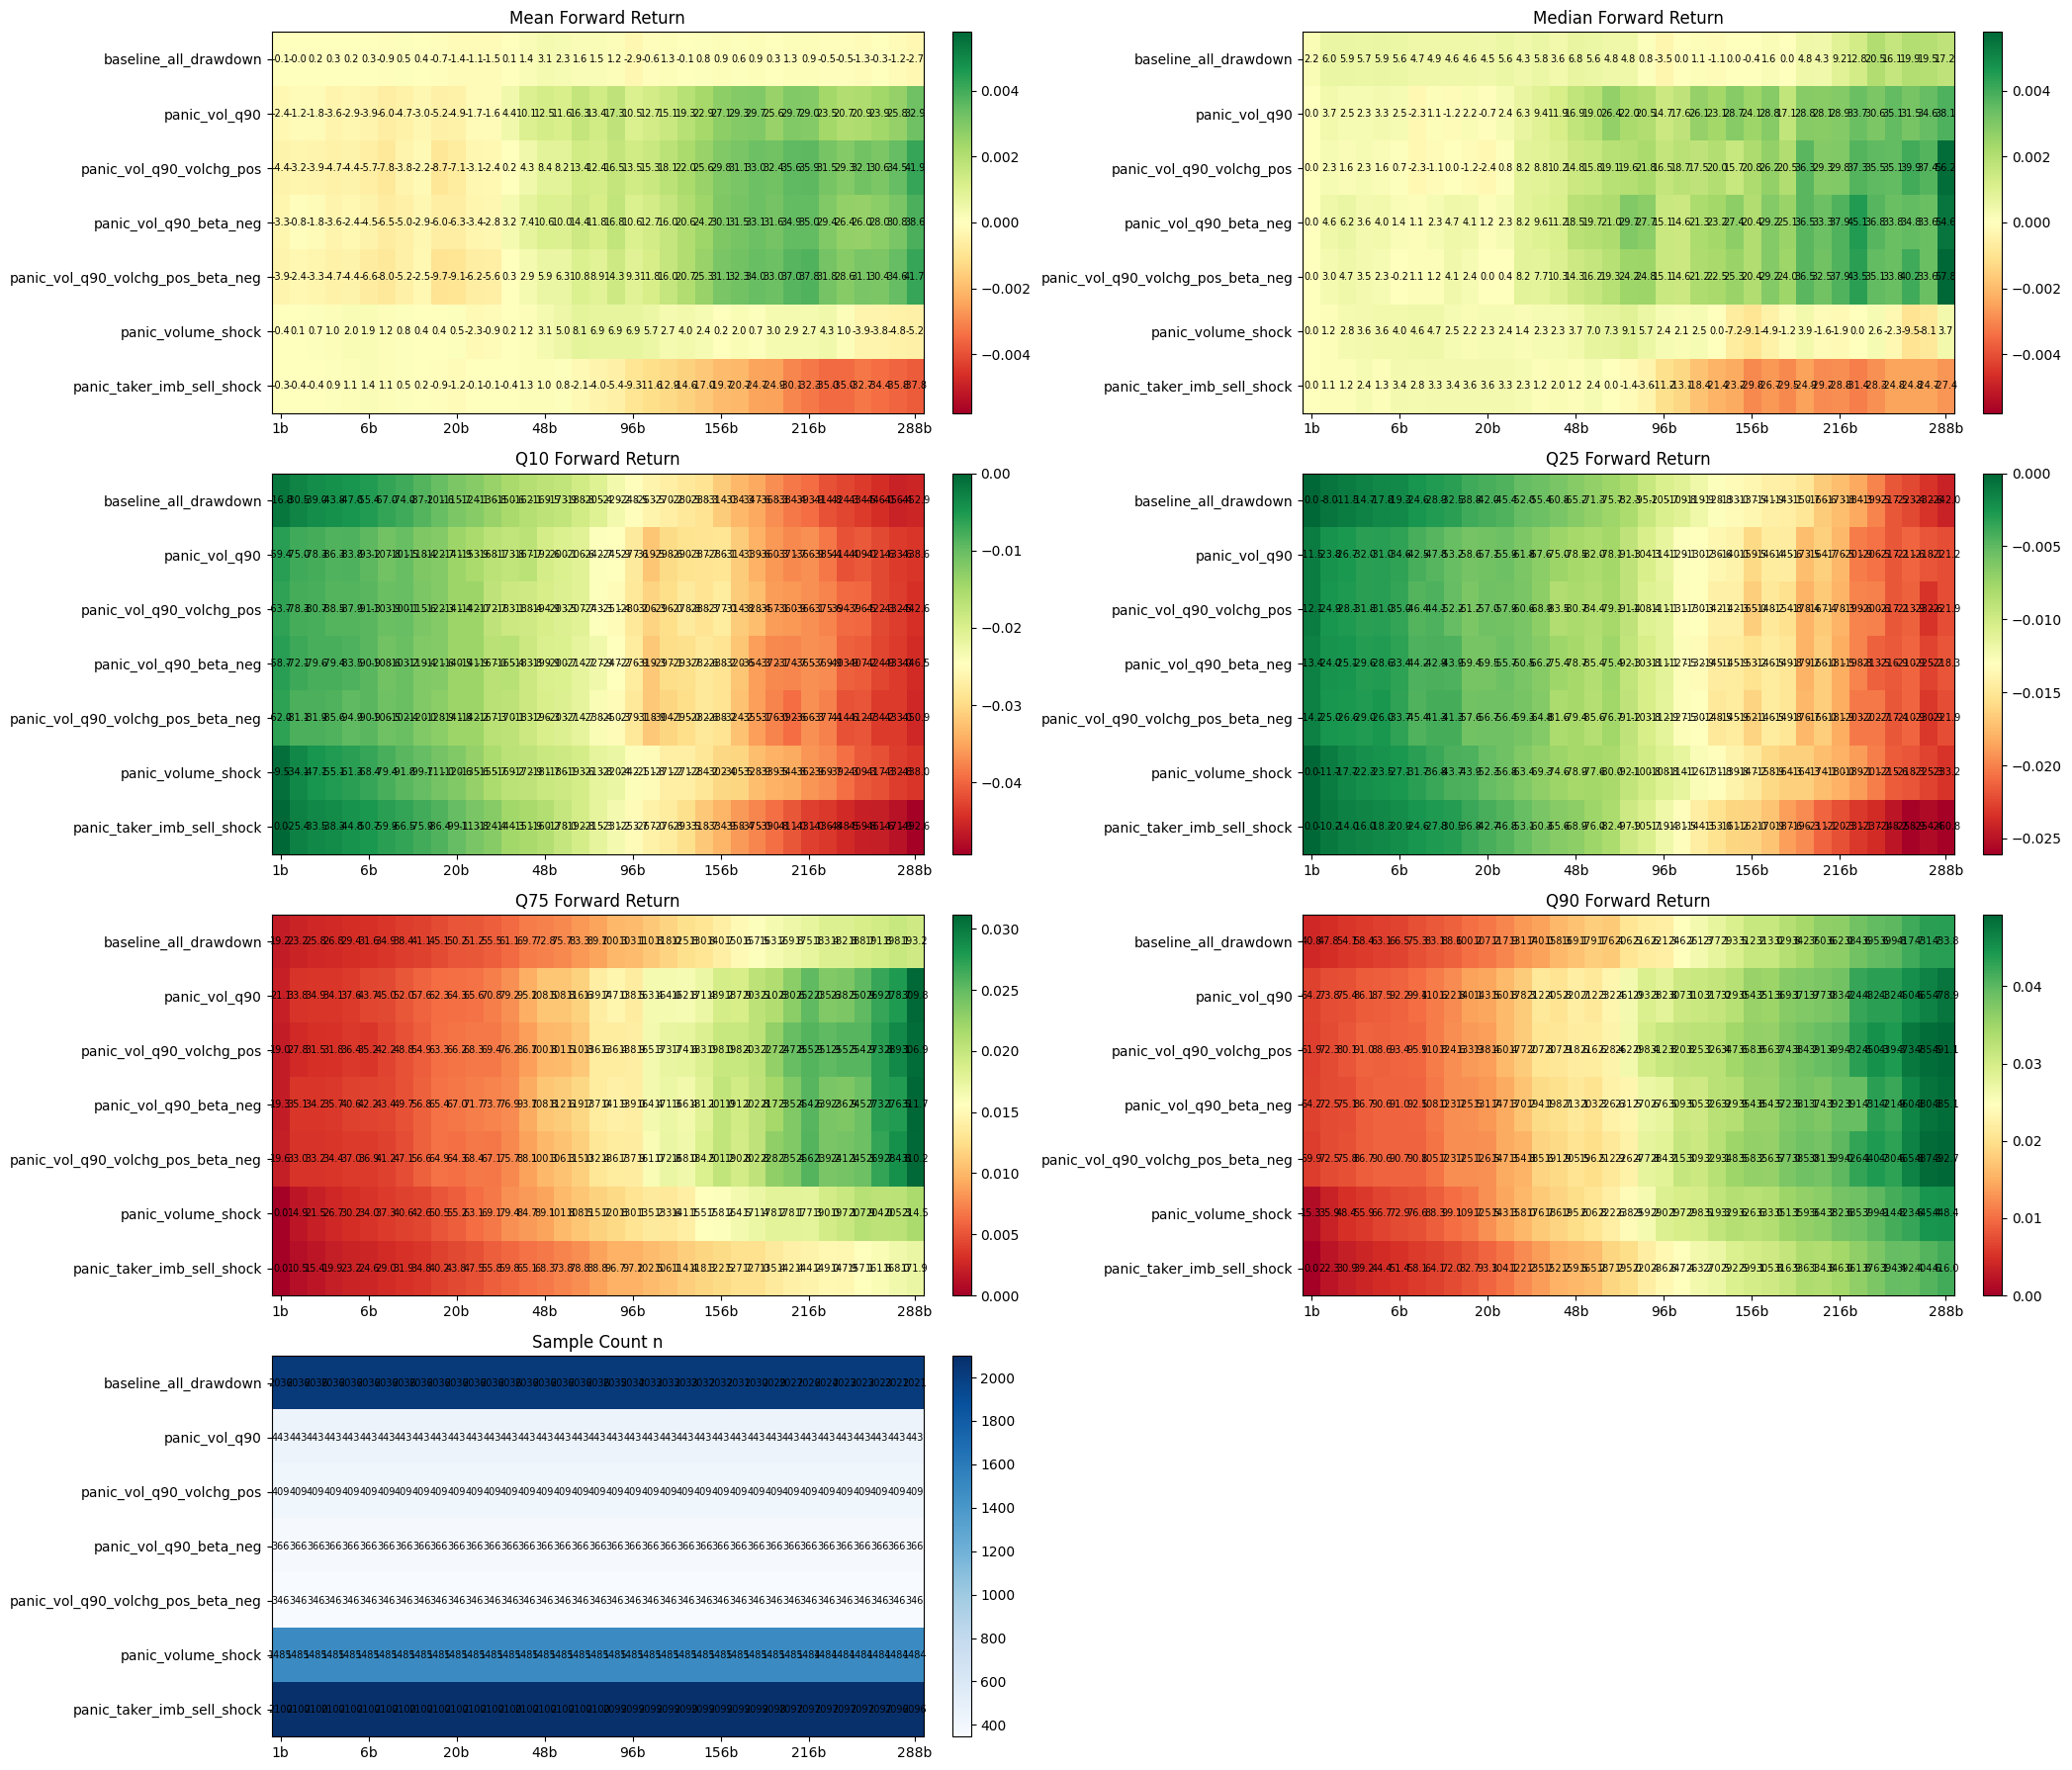

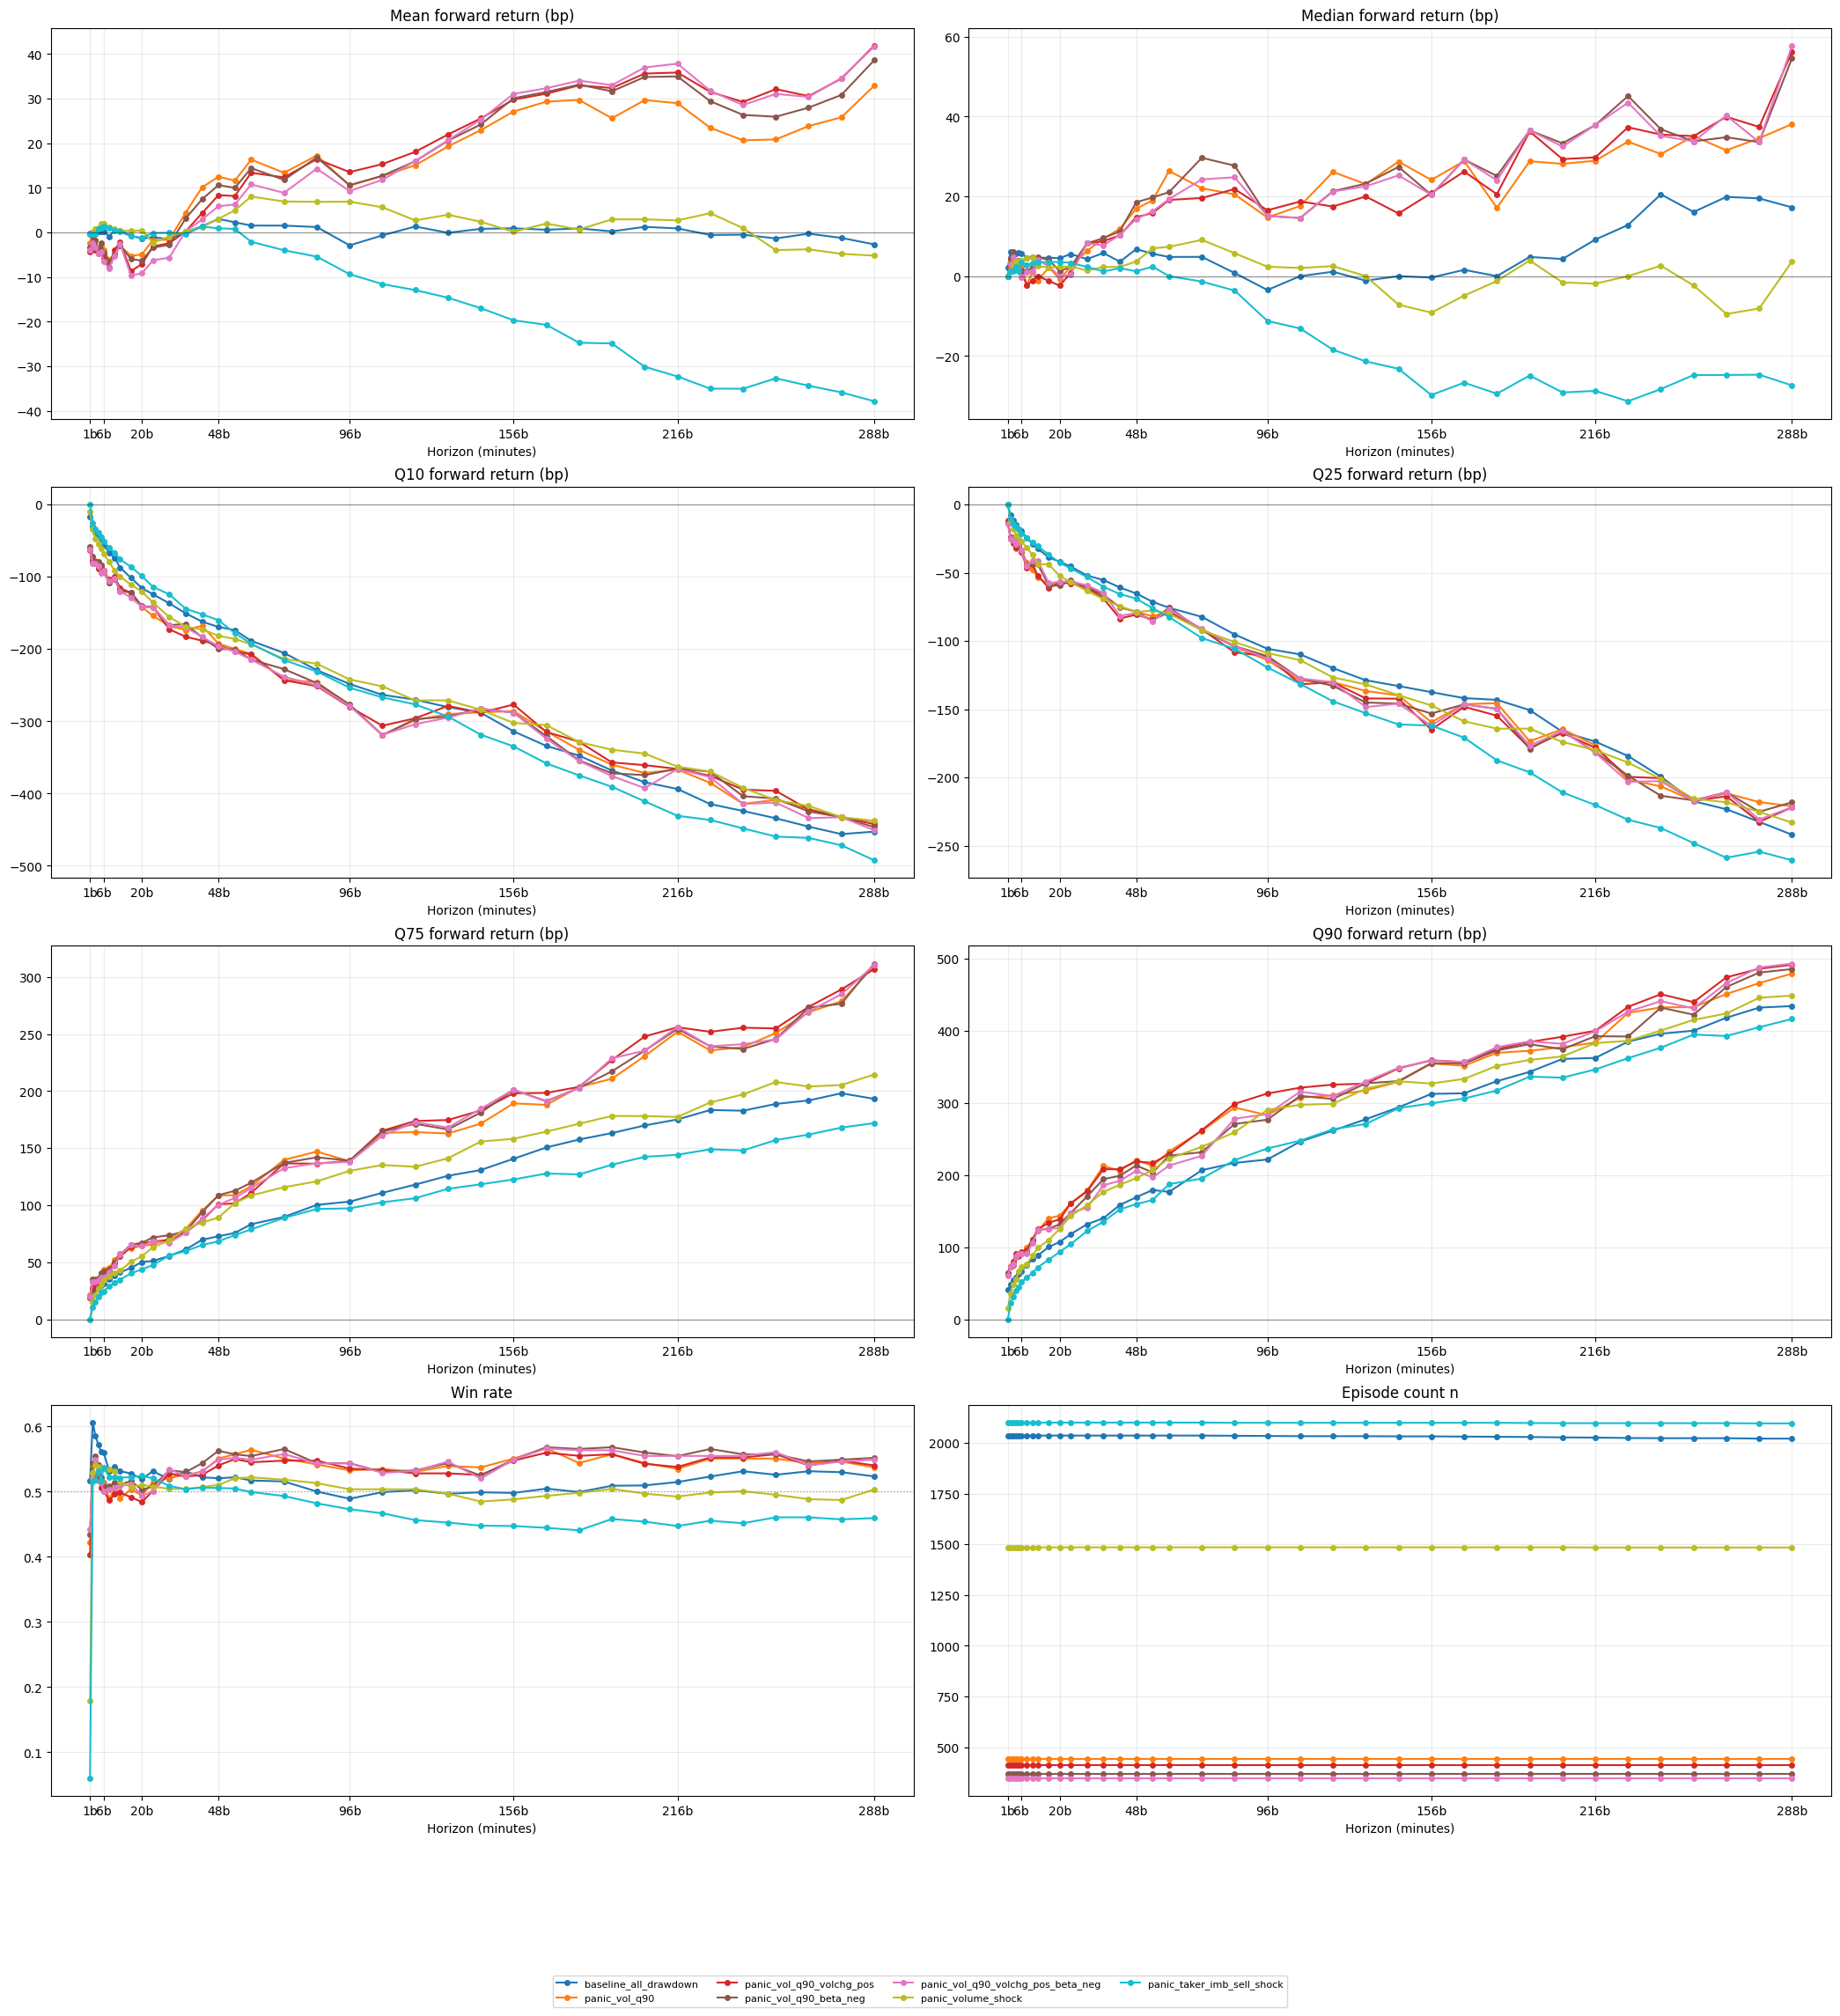

Absolute forward return stats with quantiles (includes baseline + n):


,signal,h,h_min,n,mean,median,q10,q25,q75,q90,p05,p10,win_rate
0,baseline_all_drawdown,1,5,2036,-0.000012,0.000221,-0.001683,0.000000,0.001921,0.004084,-0.006551,-0.001683,0.516699
1,baseline_all_drawdown,2,10,2036,-0.000001,0.000600,-0.003053,-0.000798,0.002324,0.004781,-0.007141,-0.003053,0.606090
2,baseline_all_drawdown,3,15,2036,0.000021,0.000594,-0.003905,-0.001146,0.002579,0.005407,-0.007923,-0.003905,0.585462
3,baseline_all_drawdown,4,20,2036,0.000031,0.000566,-0.004383,-0.001469,0.002683,0.005837,-0.009020,-0.004383,0.572692
4,baseline_all_drawdown,5,25,2036,0.000024,0.000592,-0.004697,-0.001781,0.002942,0.006306,-0.010625,-0.004697,0.561886
...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,panic_taker_imb_sell_shock,240,1200,2097,-0.003502,-0.002830,-0.044846,-0.023711,0.014793,0.037613,-0.055955,-0.044846,0.451598
403,panic_taker_imb_sell_shock,252,1260,2097,-0.003268,-0.002478,-0.045978,-0.024822,0.015707,0.039437,-0.056168,-0.045978,0.460658
404,panic_taker_imb_sell_shock,264,1320,2097,-0.003435,-0.002477,-0.046165,-0.025893,0.016184,0.039243,-0.058521,-0.046165,0.460658
405,panic_taker_imb_sell_shock,276,1380,2096,-0.003584,-0.002470,-0.047188,-0.025443,0.016802,0.040462,-0.059159,-0.047188,0.457538


Potential distortion warning (n < 200):


,signal,h,h_min,n,mean,median,q10,q25,q75,q90,p05,p10,win_rate


In [88]:
# absolute forward-return visualization across horizons (episode-based, extended quantiles)

if "panic_eval" not in globals():
    raise RuntimeError("panic_eval not found. Please run the episode-based evaluation cell first.")

signals_order = [
    "baseline_all_drawdown",
    "panic_vol_q90",
    # "panic_downside_vol_q90",
    # "panic_downside_vol_q90_volchg_pos",
    "panic_vol_q90_volchg_pos",
    "panic_vol_q90_beta_neg",
    "panic_vol_q90_volchg_pos_beta_neg",
    "panic_volume_shock",
    "panic_taker_imb_sell_shock",
]

plot_abs = panic_eval[panic_eval['signal'].isin(signals_order)].copy()
plot_abs["h_min"] = plot_abs["h"] * 5

# Defensive dedup for plotting: if (signal, h) repeats (e.g., mixed settings),
# aggregate to one row so pivot won't fail.
_dup_mask = plot_abs.duplicated(subset=["signal", "h"], keep=False)
if _dup_mask.any():
    print(f"Warning: duplicate (signal, h) rows detected: {int(_dup_mask.sum())}. Aggregating by mean (n uses max).")
    _num_cols = [c for c in ["mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate", "h_min"] if c in plot_abs.columns]
    _agg = {c: "mean" for c in _num_cols}
    if "n" in plot_abs.columns:
        _agg["n"] = "max"
    plot_abs = plot_abs.groupby(["signal", "h"], as_index=False).agg(_agg)

plot_abs["signal"] = pd.Categorical(plot_abs["signal"], categories=signals_order, ordered=True)
plot_abs = plot_abs.sort_values(["signal", "h"])

metric_heat = ["mean", "median", "q10", "q25", "q75", "q90", "n"]
mat_dict = {m: plot_abs.pivot(index="signal", columns="h", values=m) for m in metric_heat}

h_vals = sorted(plot_abs["h"].unique())
# sparse tick labels to avoid overlap
if len(h_vals) > 8:
    xtick_idx = np.linspace(0, len(h_vals) - 1, 8, dtype=int)
else:
    xtick_idx = np.arange(len(h_vals))
xtick_labels = [f"{h_vals[i]}b" for i in xtick_idx]

fig, axes = plt.subplots(4, 2, figsize=(21, 18))
heat_order = ["mean", "median", "q10", "q25", "q75", "q90", "n"]
titles = {
    "mean": "Mean Forward Return",
    "median": "Median Forward Return",
    "q10": "Q10 Forward Return",
    "q25": "Q25 Forward Return",
    "q75": "Q75 Forward Return",
    "q90": "Q90 Forward Return",
    "n": "Sample Count n",
}
cmap_map = {m: "RdYlGn" for m in ["mean", "median", "q10", "q25", "q75", "q90"]}
cmap_map["n"] = "Blues"

# mean & median share one symmetric colorbar (raw log-return units); q10–q90 each auto-scale; n uses count range.
_mm = np.concatenate([mat_dict["mean"].values.ravel(), mat_dict["median"].values.ravel()])
_mm = _mm[np.isfinite(_mm)]
if _mm.size:
    _lim_mm = float(np.nanmax(np.abs(_mm)))
    if _lim_mm == 0:
        _lim_mm = 1e-12
else:
    _lim_mm = 1e-12
vmin_mm, vmax_mm = -_lim_mm, _lim_mm

_nvals = mat_dict["n"].values.ravel()
_nvals = _nvals[np.isfinite(_nvals)]
if _nvals.size:
    vmin_n, vmax_n = float(np.nanmin(_nvals)), float(np.nanmax(_nvals))
    if vmin_n == vmax_n:
        vmax_n = vmin_n + 1.0
else:
    vmin_n, vmax_n = 0.0, 1.0

# 7 heatmaps in first 7 panels
for panel_idx, m in enumerate(heat_order):
    r, c = divmod(panel_idx, 2)
    mat = mat_dict[m]
    if m == "n":
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m], vmin=vmin_n, vmax=vmax_n)
    elif m in ("mean", "median"):
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m], vmin=vmin_mm, vmax=vmax_mm)
    else:
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m])
    axes[r, c].set_title(titles[m])
    axes[r, c].set_yticks(np.arange(len(mat.index)))
    axes[r, c].set_yticklabels(mat.index)
    axes[r, c].set_xticks(xtick_idx)
    axes[r, c].set_xticklabels(xtick_labels, rotation=0)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if np.isfinite(v):
                txt = f"{int(v)}" if m == "n" else f"{v*1e4:.1f}"
                axes[r, c].text(j, i, txt, ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=axes[r, c], fraction=0.046, pad=0.04)

# panel 8 unused — line charts are split per metric in the next figure
axes[3, 1].axis("off")

plt.tight_layout()
plt.show()

# Separate line chart per metric (one signal = one color across panels)
_xt_min = np.array([h_vals[i] * 5 for i in xtick_idx])
_xt_lab = [f"{h_vals[i]}b" for i in xtick_idx]
_sig_colors = plt.cm.tab10(np.linspace(0, 1, len(signals_order)))
_sig_color = {sig: _sig_colors[i] for i, sig in enumerate(signals_order)}

_line_specs = [
    ("mean", "Mean forward return (bp)", lambda d: d["mean"].to_numpy(dtype=float) * 1e4, True, None),
    ("median", "Median forward return (bp)", lambda d: d["median"].to_numpy(dtype=float) * 1e4, True, None),
    ("q10", "Q10 forward return (bp)", lambda d: d["q10"].to_numpy(dtype=float) * 1e4, True, None),
    ("q25", "Q25 forward return (bp)", lambda d: d["q25"].to_numpy(dtype=float) * 1e4, True, None),
    ("q75", "Q75 forward return (bp)", lambda d: d["q75"].to_numpy(dtype=float) * 1e4, True, None),
    ("q90", "Q90 forward return (bp)", lambda d: d["q90"].to_numpy(dtype=float) * 1e4, True, None),
    ("win_rate", "Win rate", lambda d: d["win_rate"].to_numpy(dtype=float), False, 0.5),
    ("n", "Episode count n", lambda d: d["n"].to_numpy(dtype=float), False, None),
]

fig_line, axes_line = plt.subplots(4, 2, figsize=(21, 22))
for i, (_col, title, yfn, zero_line, ref_line) in enumerate(_line_specs):
    axl = axes_line.flat[i]
    for sig in signals_order:
        d = plot_abs[plot_abs["signal"] == sig].sort_values("h")
        if len(d) == 0:
            continue
        x = d["h_min"].to_numpy()
        y = yfn(d)
        axl.plot(x, y, marker="o", lw=1.5, ms=4, label=sig, color=_sig_color[sig])
    if zero_line:
        axl.axhline(0, color="black", lw=1, alpha=0.35)
    if ref_line is not None:
        axl.axhline(ref_line, color="gray", lw=1, ls=":", alpha=0.6)
    axl.set_title(title)
    axl.set_xlabel("Horizon (minutes)")
    axl.grid(alpha=0.25)
    axl.set_xticks(_xt_min)
    axl.set_xticklabels(_xt_lab)

handles, labels = axes_line.flat[0].get_legend_handles_labels()
fig_line.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.show()

# detailed table
cols = ["signal", "h", "h_min", "n", "mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate"]
abs_view = plot_abs[cols].copy()
for col in ["mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate"]:
    abs_view[col] = abs_view[col].astype(float)

print("Absolute forward return stats with quantiles (includes baseline + n):")
display(abs_view.sort_values(["signal", "h"]))

print("Potential distortion warning (n < 200):")
display(abs_view[abs_view["n"] < 200].sort_values(["signal", "h"]))


### 使用固定 deoverlapping 区间（更接近实际策略）

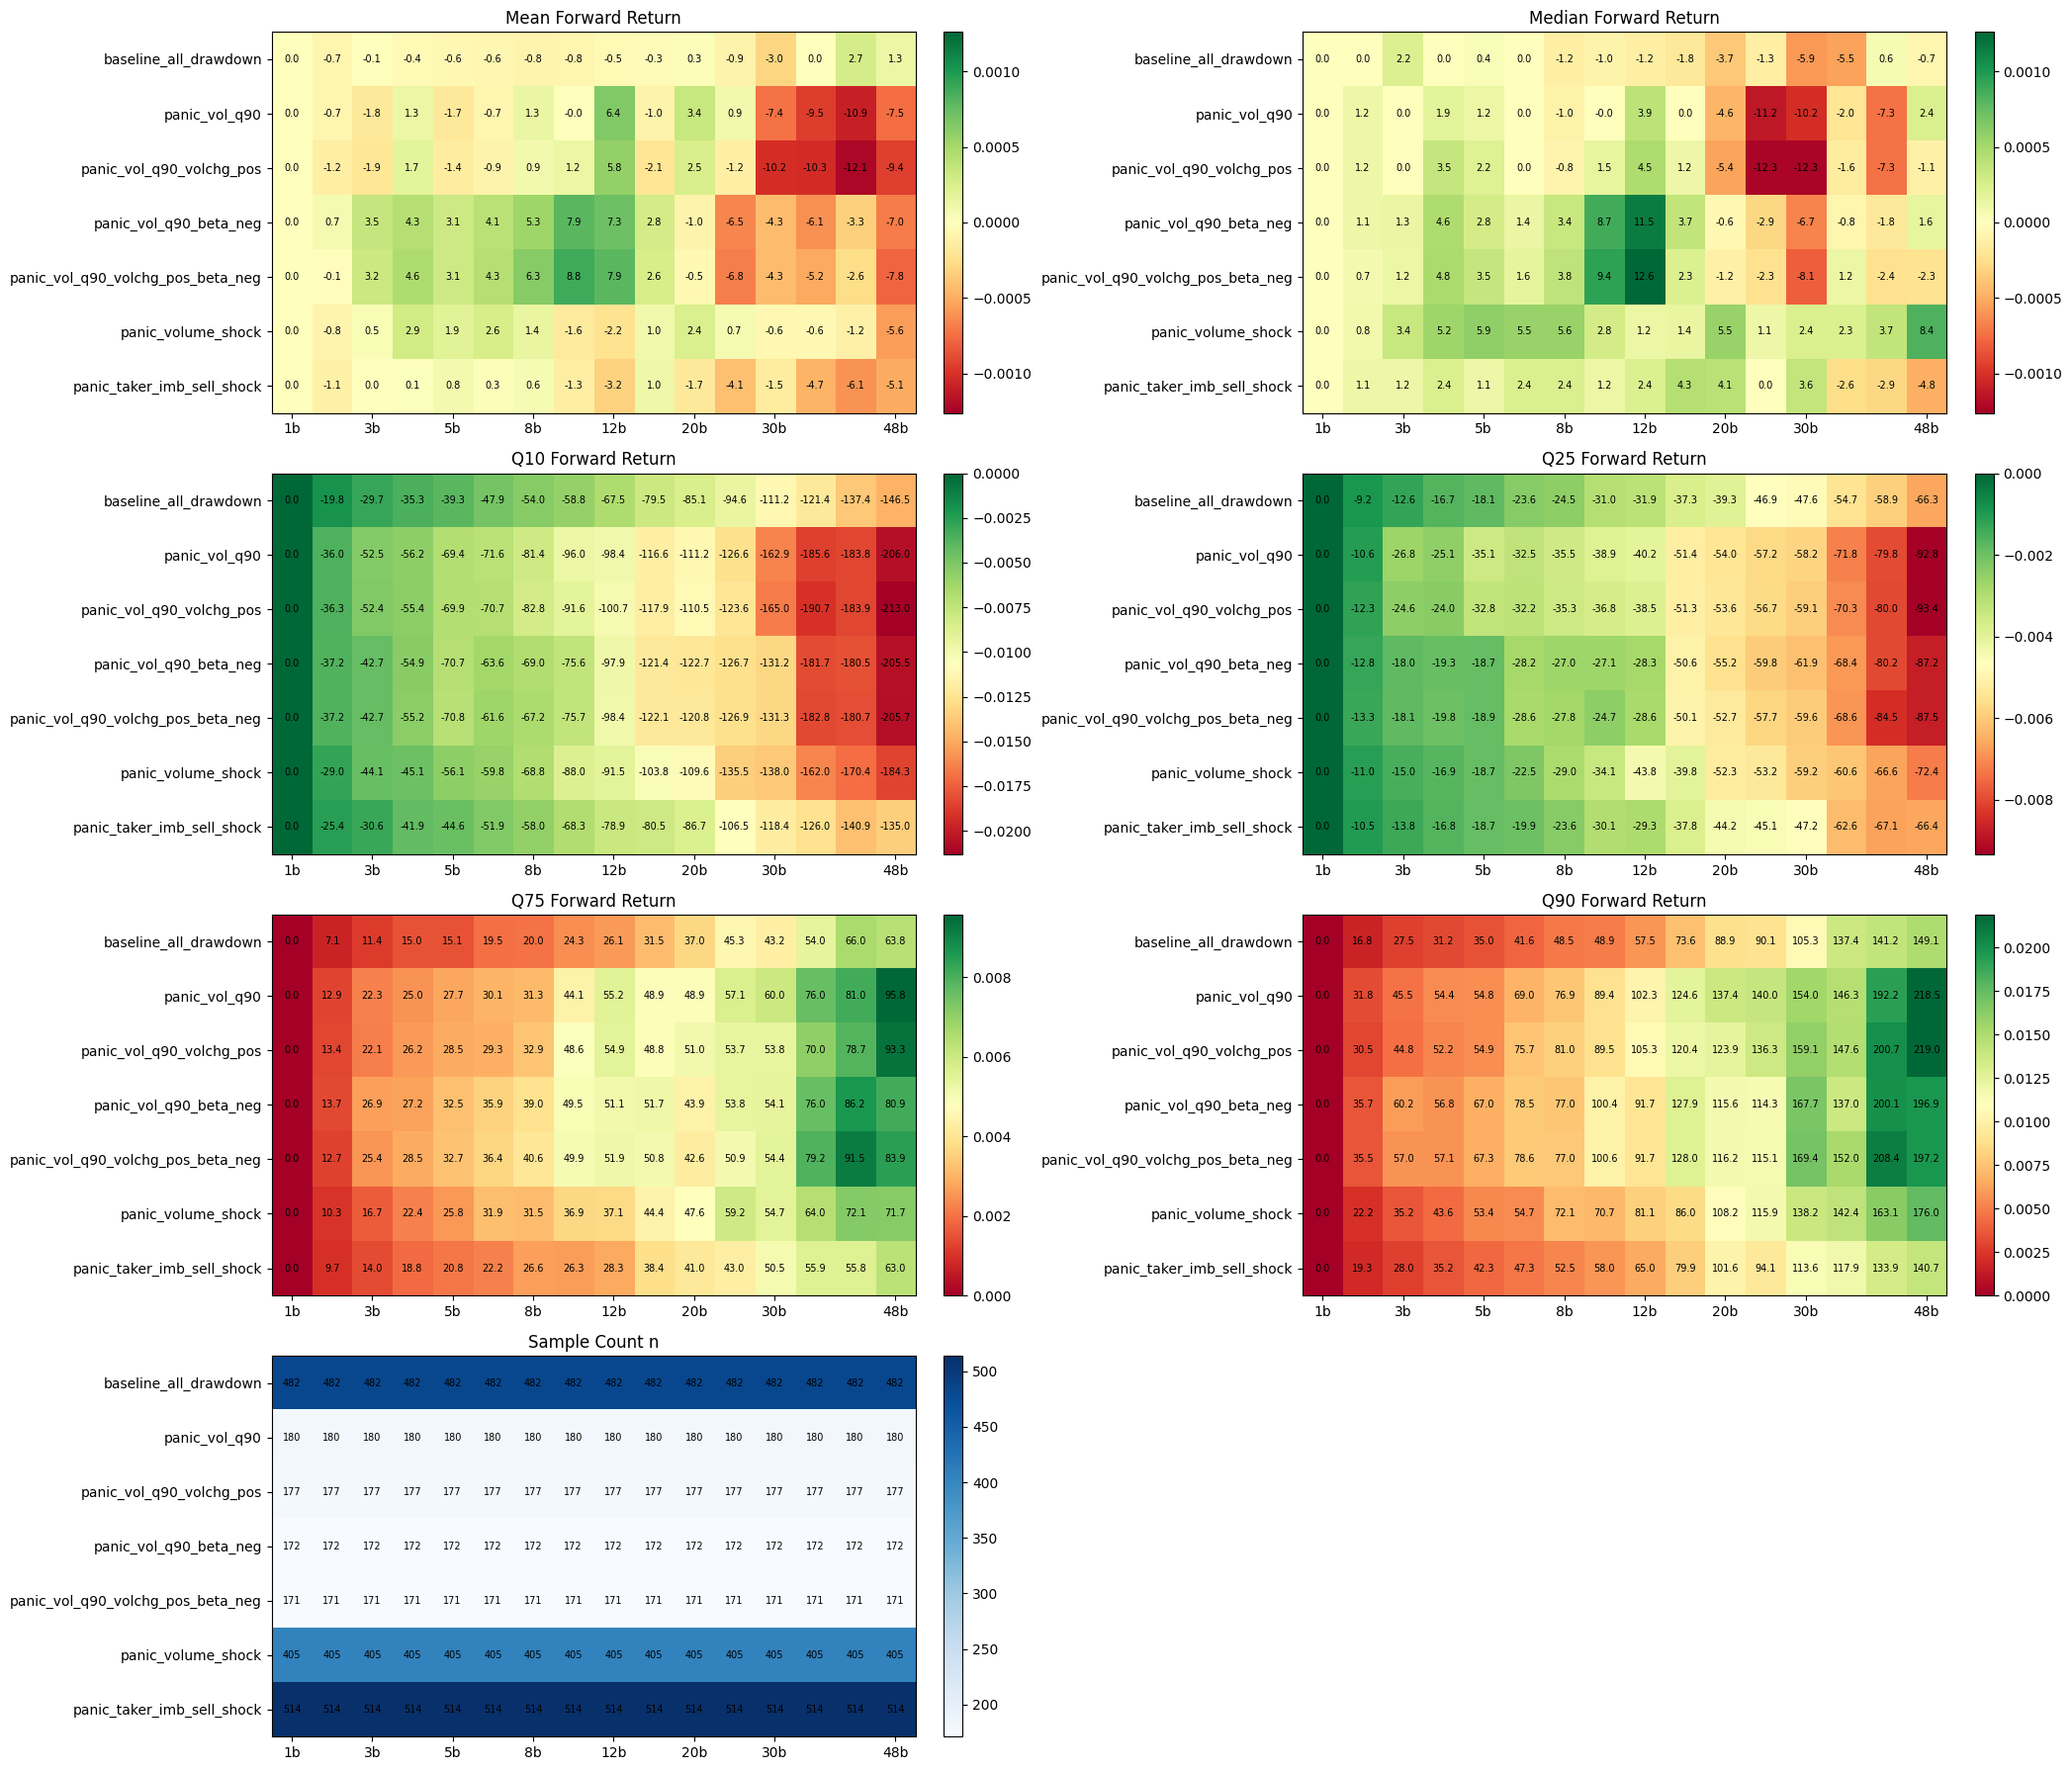

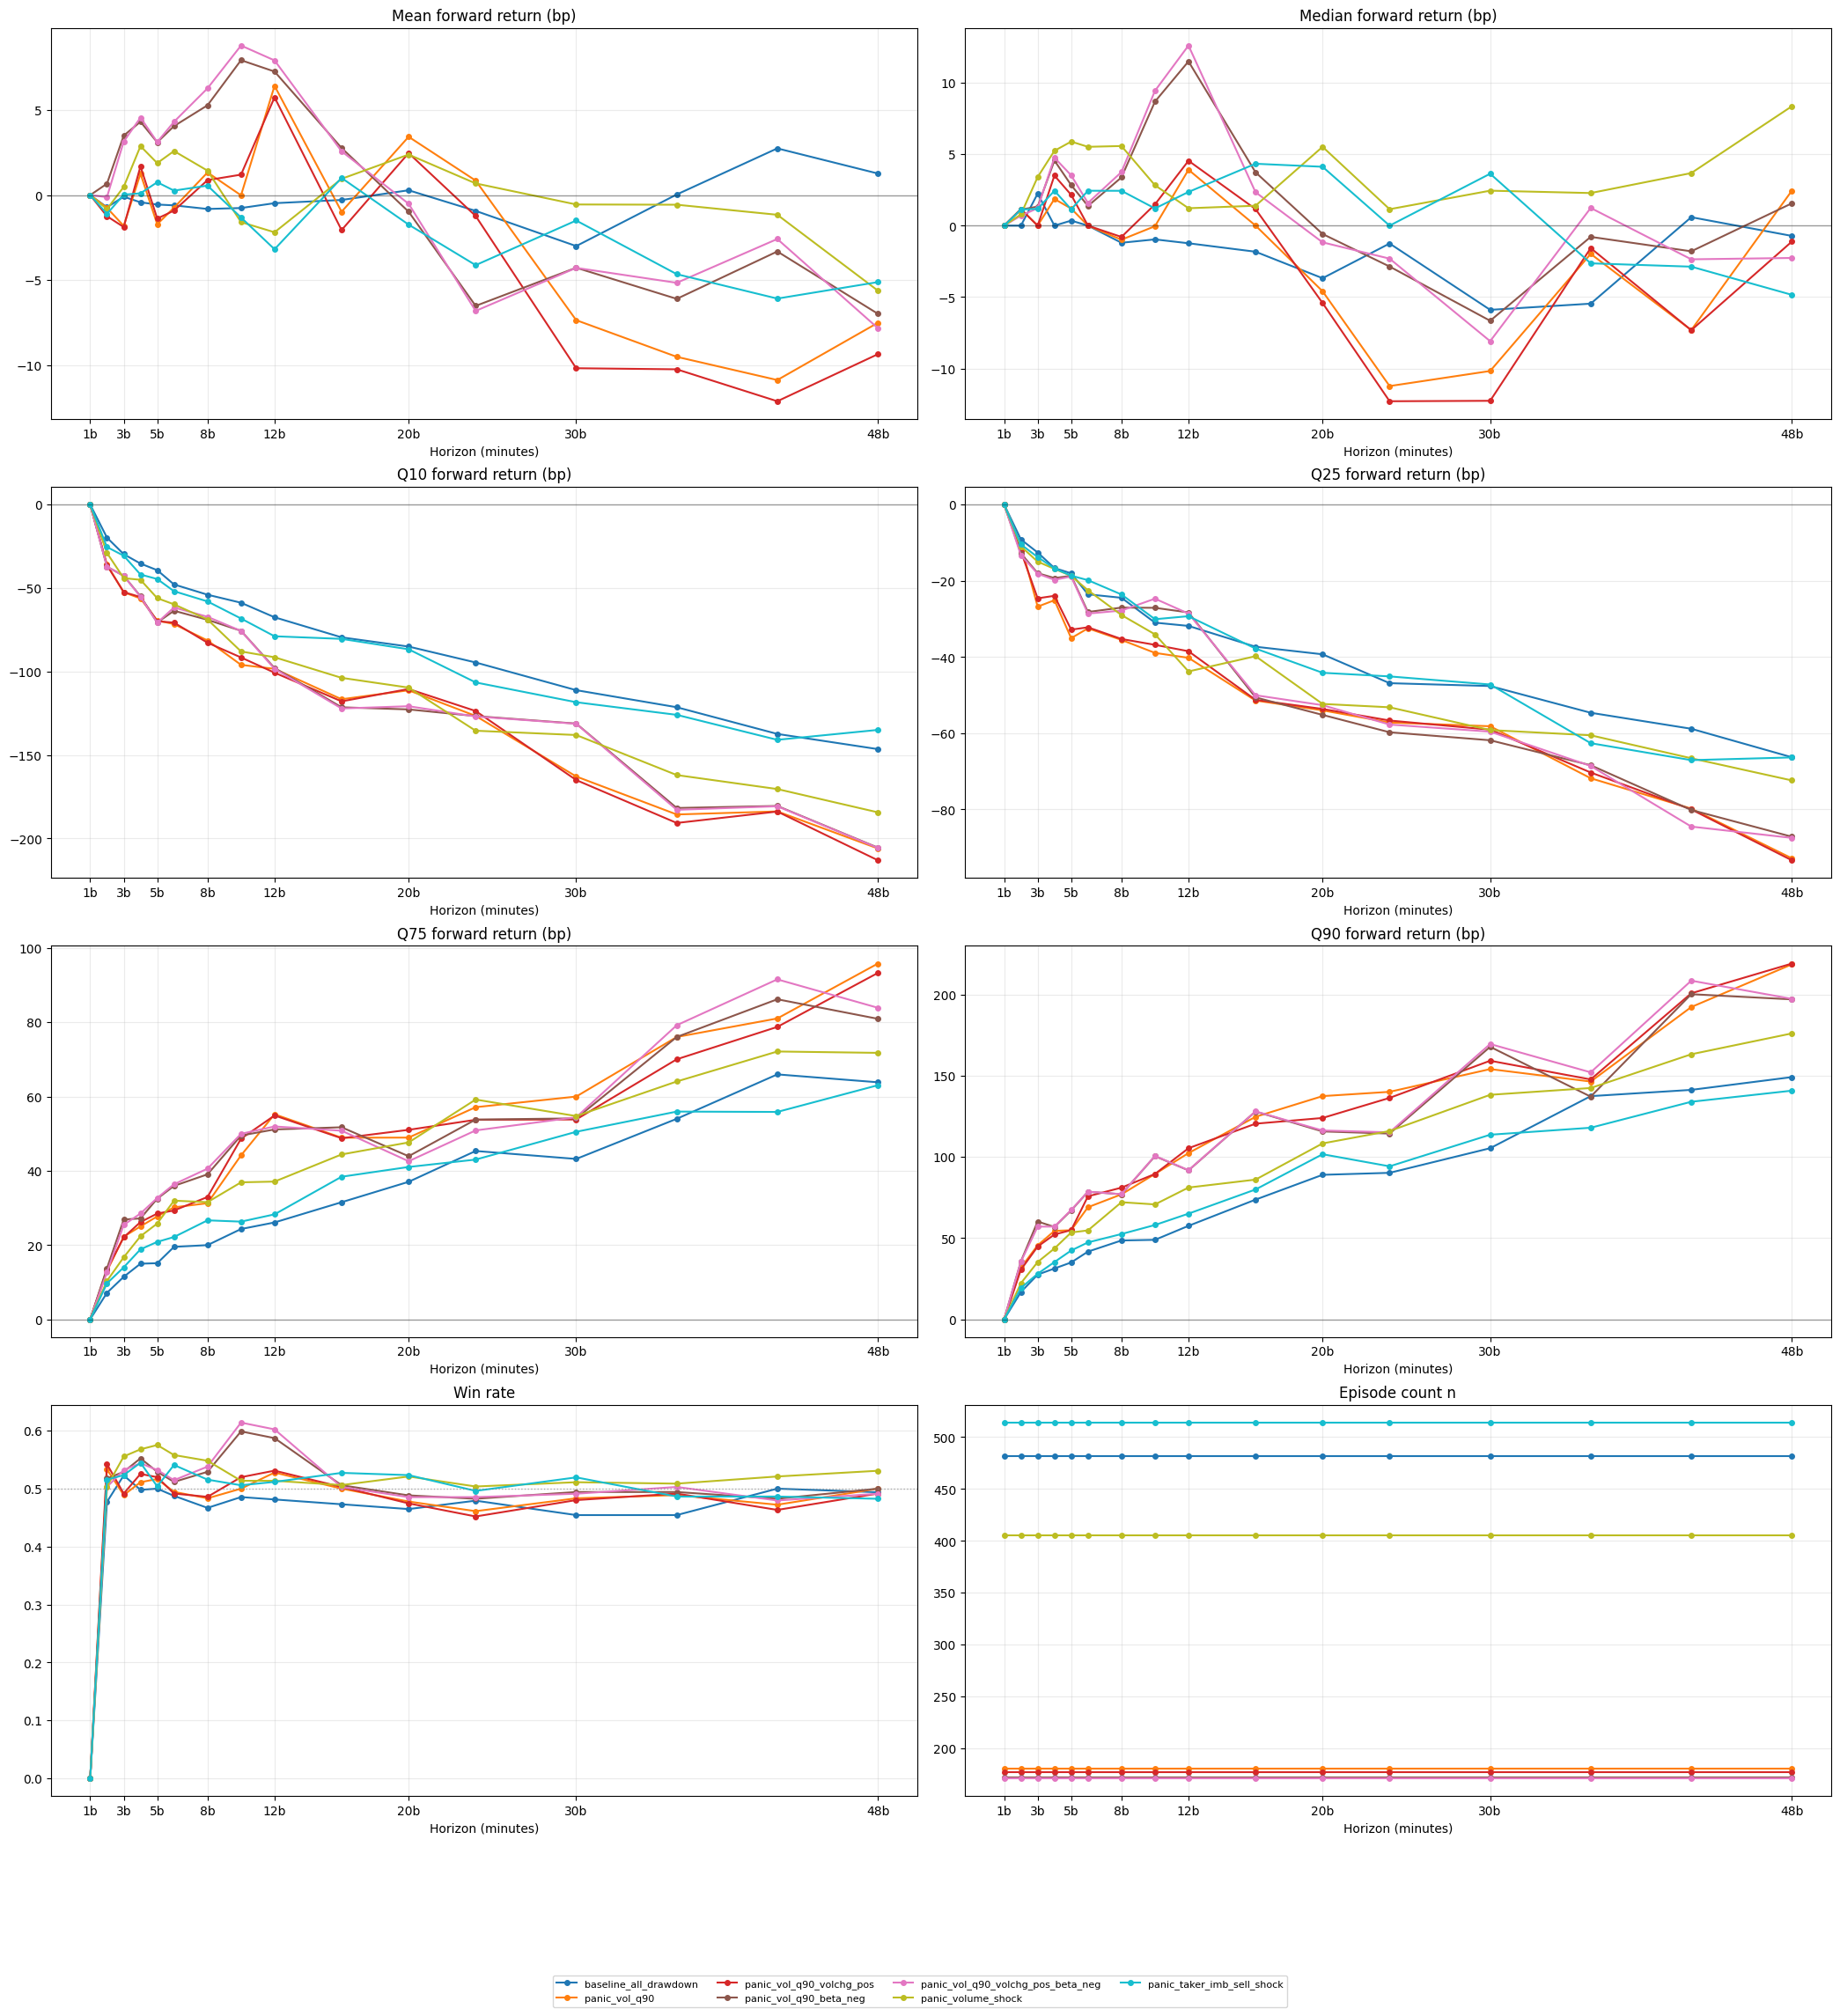

Absolute forward return stats with quantiles (includes baseline + n):


,signal,h,h_min,n,mean,median,q10,q25,q75,q90,p05,p10,win_rate
0,baseline_all_drawdown,1,5,482,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,baseline_all_drawdown,2,10,482,-0.000072,0.000000,-0.001980,-0.000916,0.000712,0.001676,-0.003120,-0.001980,0.477178
2,baseline_all_drawdown,3,15,482,-0.000009,0.000224,-0.002972,-0.001259,0.001144,0.002751,-0.004061,-0.002972,0.522822
3,baseline_all_drawdown,4,20,482,-0.000042,0.000000,-0.003535,-0.001666,0.001497,0.003125,-0.005262,-0.003535,0.497925
4,baseline_all_drawdown,5,25,482,-0.000055,0.000035,-0.003931,-0.001805,0.001510,0.003499,-0.005800,-0.003931,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,panic_taker_imb_sell_shock,24,120,514,-0.000412,0.000000,-0.010654,-0.004511,0.004301,0.009414,-0.015350,-0.010654,0.496109
172,panic_taker_imb_sell_shock,30,150,514,-0.000149,0.000363,-0.011839,-0.004723,0.005049,0.011360,-0.017847,-0.011839,0.519455
173,panic_taker_imb_sell_shock,36,180,514,-0.000465,-0.000264,-0.012595,-0.006264,0.005594,0.011790,-0.019747,-0.012595,0.486381
174,panic_taker_imb_sell_shock,42,210,514,-0.000609,-0.000287,-0.014092,-0.006709,0.005584,0.013389,-0.019609,-0.014092,0.486381


Potential distortion warning (n < 200):


,signal,h,h_min,n,mean,median,q10,q25,q75,q90,p05,p10,win_rate
16,panic_vol_q90,1,5,180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
17,panic_vol_q90,2,10,180,-0.000075,0.000115,-0.003597,-0.001063,0.001295,0.003178,-0.005354,-0.003597,0.533333
18,panic_vol_q90,3,15,180,-0.000181,0.000000,-0.005253,-0.002680,0.002225,0.004553,-0.008184,-0.005253,0.488889
19,panic_vol_q90,4,20,180,0.000126,0.000187,-0.005623,-0.002511,0.002501,0.005439,-0.007765,-0.005623,0.511111
20,panic_vol_q90,5,25,180,-0.000171,0.000119,-0.006943,-0.003507,0.002771,0.005483,-0.011210,-0.006943,0.516667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,panic_vol_q90_volchg_pos_beta_neg,24,120,171,-0.000681,-0.000231,-0.012693,-0.005775,0.005086,0.011509,-0.016353,-0.012693,0.485380
76,panic_vol_q90_volchg_pos_beta_neg,30,150,171,-0.000428,-0.000809,-0.013130,-0.005961,0.005441,0.016943,-0.021292,-0.013130,0.491228
77,panic_vol_q90_volchg_pos_beta_neg,36,180,171,-0.000516,0.000124,-0.018284,-0.006862,0.007920,0.015200,-0.027525,-0.018284,0.502924
78,panic_vol_q90_volchg_pos_beta_neg,42,210,171,-0.000258,-0.000236,-0.018070,-0.008453,0.009154,0.020843,-0.031066,-0.018070,0.479532


In [23]:
# absolute forward-return visualization across horizons (episode-based, extended quantiles)

if "panic_eval" not in globals():
    raise RuntimeError("panic_eval not found. Please run the episode-based evaluation cell first.")

signals_order = [
    "baseline_all_drawdown",
    "panic_vol_q90",
    # "panic_downside_vol_q90",
    # "panic_downside_vol_q90_volchg_pos",
    "panic_vol_q90_volchg_pos",
    "panic_vol_q90_beta_neg",
    "panic_vol_q90_volchg_pos_beta_neg",
    "panic_volume_shock",
    "panic_taker_imb_sell_shock",
]

plot_abs = panic_eval[panic_eval['signal'].isin(signals_order)].copy()
plot_abs["h_min"] = plot_abs["h"] * 5

# Defensive dedup for plotting: if (signal, h) repeats (e.g., mixed settings),
# aggregate to one row so pivot won't fail.
_dup_mask = plot_abs.duplicated(subset=["signal", "h"], keep=False)
if _dup_mask.any():
    print(f"Warning: duplicate (signal, h) rows detected: {int(_dup_mask.sum())}. Aggregating by mean (n uses max).")
    _num_cols = [c for c in ["mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate", "h_min"] if c in plot_abs.columns]
    _agg = {c: "mean" for c in _num_cols}
    if "n" in plot_abs.columns:
        _agg["n"] = "max"
    plot_abs = plot_abs.groupby(["signal", "h"], as_index=False).agg(_agg)

plot_abs["signal"] = pd.Categorical(plot_abs["signal"], categories=signals_order, ordered=True)
plot_abs = plot_abs.sort_values(["signal", "h"])

metric_heat = ["mean", "median", "q10", "q25", "q75", "q90", "n"]
mat_dict = {m: plot_abs.pivot(index="signal", columns="h", values=m) for m in metric_heat}

h_vals = sorted(plot_abs["h"].unique())
# sparse tick labels to avoid overlap
if len(h_vals) > 8:
    xtick_idx = np.linspace(0, len(h_vals) - 1, 8, dtype=int)
else:
    xtick_idx = np.arange(len(h_vals))
xtick_labels = [f"{h_vals[i]}b" for i in xtick_idx]

fig, axes = plt.subplots(4, 2, figsize=(21, 18))
heat_order = ["mean", "median", "q10", "q25", "q75", "q90", "n"]
titles = {
    "mean": "Mean Forward Return",
    "median": "Median Forward Return",
    "q10": "Q10 Forward Return",
    "q25": "Q25 Forward Return",
    "q75": "Q75 Forward Return",
    "q90": "Q90 Forward Return",
    "n": "Sample Count n",
}
cmap_map = {m: "RdYlGn" for m in ["mean", "median", "q10", "q25", "q75", "q90"]}
cmap_map["n"] = "Blues"

# mean & median share one symmetric colorbar (raw log-return units); q10–q90 each auto-scale; n uses count range.
_mm = np.concatenate([mat_dict["mean"].values.ravel(), mat_dict["median"].values.ravel()])
_mm = _mm[np.isfinite(_mm)]
if _mm.size:
    _lim_mm = float(np.nanmax(np.abs(_mm)))
    if _lim_mm == 0:
        _lim_mm = 1e-12
else:
    _lim_mm = 1e-12
vmin_mm, vmax_mm = -_lim_mm, _lim_mm

_nvals = mat_dict["n"].values.ravel()
_nvals = _nvals[np.isfinite(_nvals)]
if _nvals.size:
    vmin_n, vmax_n = float(np.nanmin(_nvals)), float(np.nanmax(_nvals))
    if vmin_n == vmax_n:
        vmax_n = vmin_n + 1.0
else:
    vmin_n, vmax_n = 0.0, 1.0

# 7 heatmaps in first 7 panels
for panel_idx, m in enumerate(heat_order):
    r, c = divmod(panel_idx, 2)
    mat = mat_dict[m]
    if m == "n":
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m], vmin=vmin_n, vmax=vmax_n)
    elif m in ("mean", "median"):
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m], vmin=vmin_mm, vmax=vmax_mm)
    else:
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m])
    axes[r, c].set_title(titles[m])
    axes[r, c].set_yticks(np.arange(len(mat.index)))
    axes[r, c].set_yticklabels(mat.index)
    axes[r, c].set_xticks(xtick_idx)
    axes[r, c].set_xticklabels(xtick_labels, rotation=0)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if np.isfinite(v):
                txt = f"{int(v)}" if m == "n" else f"{v*1e4:.1f}"
                axes[r, c].text(j, i, txt, ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=axes[r, c], fraction=0.046, pad=0.04)

# panel 8 unused — line charts are split per metric in the next figure
axes[3, 1].axis("off")

plt.tight_layout()
plt.show()

# Separate line chart per metric (one signal = one color across panels)
_xt_min = np.array([h_vals[i] * 5 for i in xtick_idx])
_xt_lab = [f"{h_vals[i]}b" for i in xtick_idx]
_sig_colors = plt.cm.tab10(np.linspace(0, 1, len(signals_order)))
_sig_color = {sig: _sig_colors[i] for i, sig in enumerate(signals_order)}

_line_specs = [
    ("mean", "Mean forward return (bp)", lambda d: d["mean"].to_numpy(dtype=float) * 1e4, True, None),
    ("median", "Median forward return (bp)", lambda d: d["median"].to_numpy(dtype=float) * 1e4, True, None),
    ("q10", "Q10 forward return (bp)", lambda d: d["q10"].to_numpy(dtype=float) * 1e4, True, None),
    ("q25", "Q25 forward return (bp)", lambda d: d["q25"].to_numpy(dtype=float) * 1e4, True, None),
    ("q75", "Q75 forward return (bp)", lambda d: d["q75"].to_numpy(dtype=float) * 1e4, True, None),
    ("q90", "Q90 forward return (bp)", lambda d: d["q90"].to_numpy(dtype=float) * 1e4, True, None),
    ("win_rate", "Win rate", lambda d: d["win_rate"].to_numpy(dtype=float), False, 0.5),
    ("n", "Episode count n", lambda d: d["n"].to_numpy(dtype=float), False, None),
]

fig_line, axes_line = plt.subplots(4, 2, figsize=(21, 22))
for i, (_col, title, yfn, zero_line, ref_line) in enumerate(_line_specs):
    axl = axes_line.flat[i]
    for sig in signals_order:
        d = plot_abs[plot_abs["signal"] == sig].sort_values("h")
        if len(d) == 0:
            continue
        x = d["h_min"].to_numpy()
        y = yfn(d)
        axl.plot(x, y, marker="o", lw=1.5, ms=4, label=sig, color=_sig_color[sig])
    if zero_line:
        axl.axhline(0, color="black", lw=1, alpha=0.35)
    if ref_line is not None:
        axl.axhline(ref_line, color="gray", lw=1, ls=":", alpha=0.6)
    axl.set_title(title)
    axl.set_xlabel("Horizon (minutes)")
    axl.grid(alpha=0.25)
    axl.set_xticks(_xt_min)
    axl.set_xticklabels(_xt_lab)

handles, labels = axes_line.flat[0].get_legend_handles_labels()
fig_line.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.show()

# detailed table
cols = ["signal", "h", "h_min", "n", "mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate"]
abs_view = plot_abs[cols].copy()
for col in ["mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate"]:
    abs_view[col] = abs_view[col].astype(float)

print("Absolute forward return stats with quantiles (includes baseline + n):")
display(abs_view.sort_values(["signal", "h"]))

print("Potential distortion warning (n < 200):")
display(abs_view[abs_view["n"] < 200].sort_values(["signal", "h"]))


## 分析
对于大量下跌后，
volume shock, taker vol imb 作为趋势（下跌继续），表现都不错：median 收益低于 mean => 说明大多数都集中继续下跌，少数回正；
taker vol imb 表现稍优，表现为各分位数上的收益较 baseline 都明显下移

volatility shock 作为反转信号(开始上升)，表现也不错：median 收益高于 mean => 大多数都上升，有左偏的几个 outlier 拖低了整体均值；

即时反应：
volume shock, taker vol imb 在下一个 bar 的 win rate 极低， 
好像 baseline 的均值回复性极强，下几个 bar 的 win rate 都高于 50% => 后收敛到 50%
但为什么 volume shock, taker vol imb 的 win rate 那么低，他的 return 却高于 vol family 的returns?  => 我想看收益分布

### 试试用下行风险
只看下行波动率

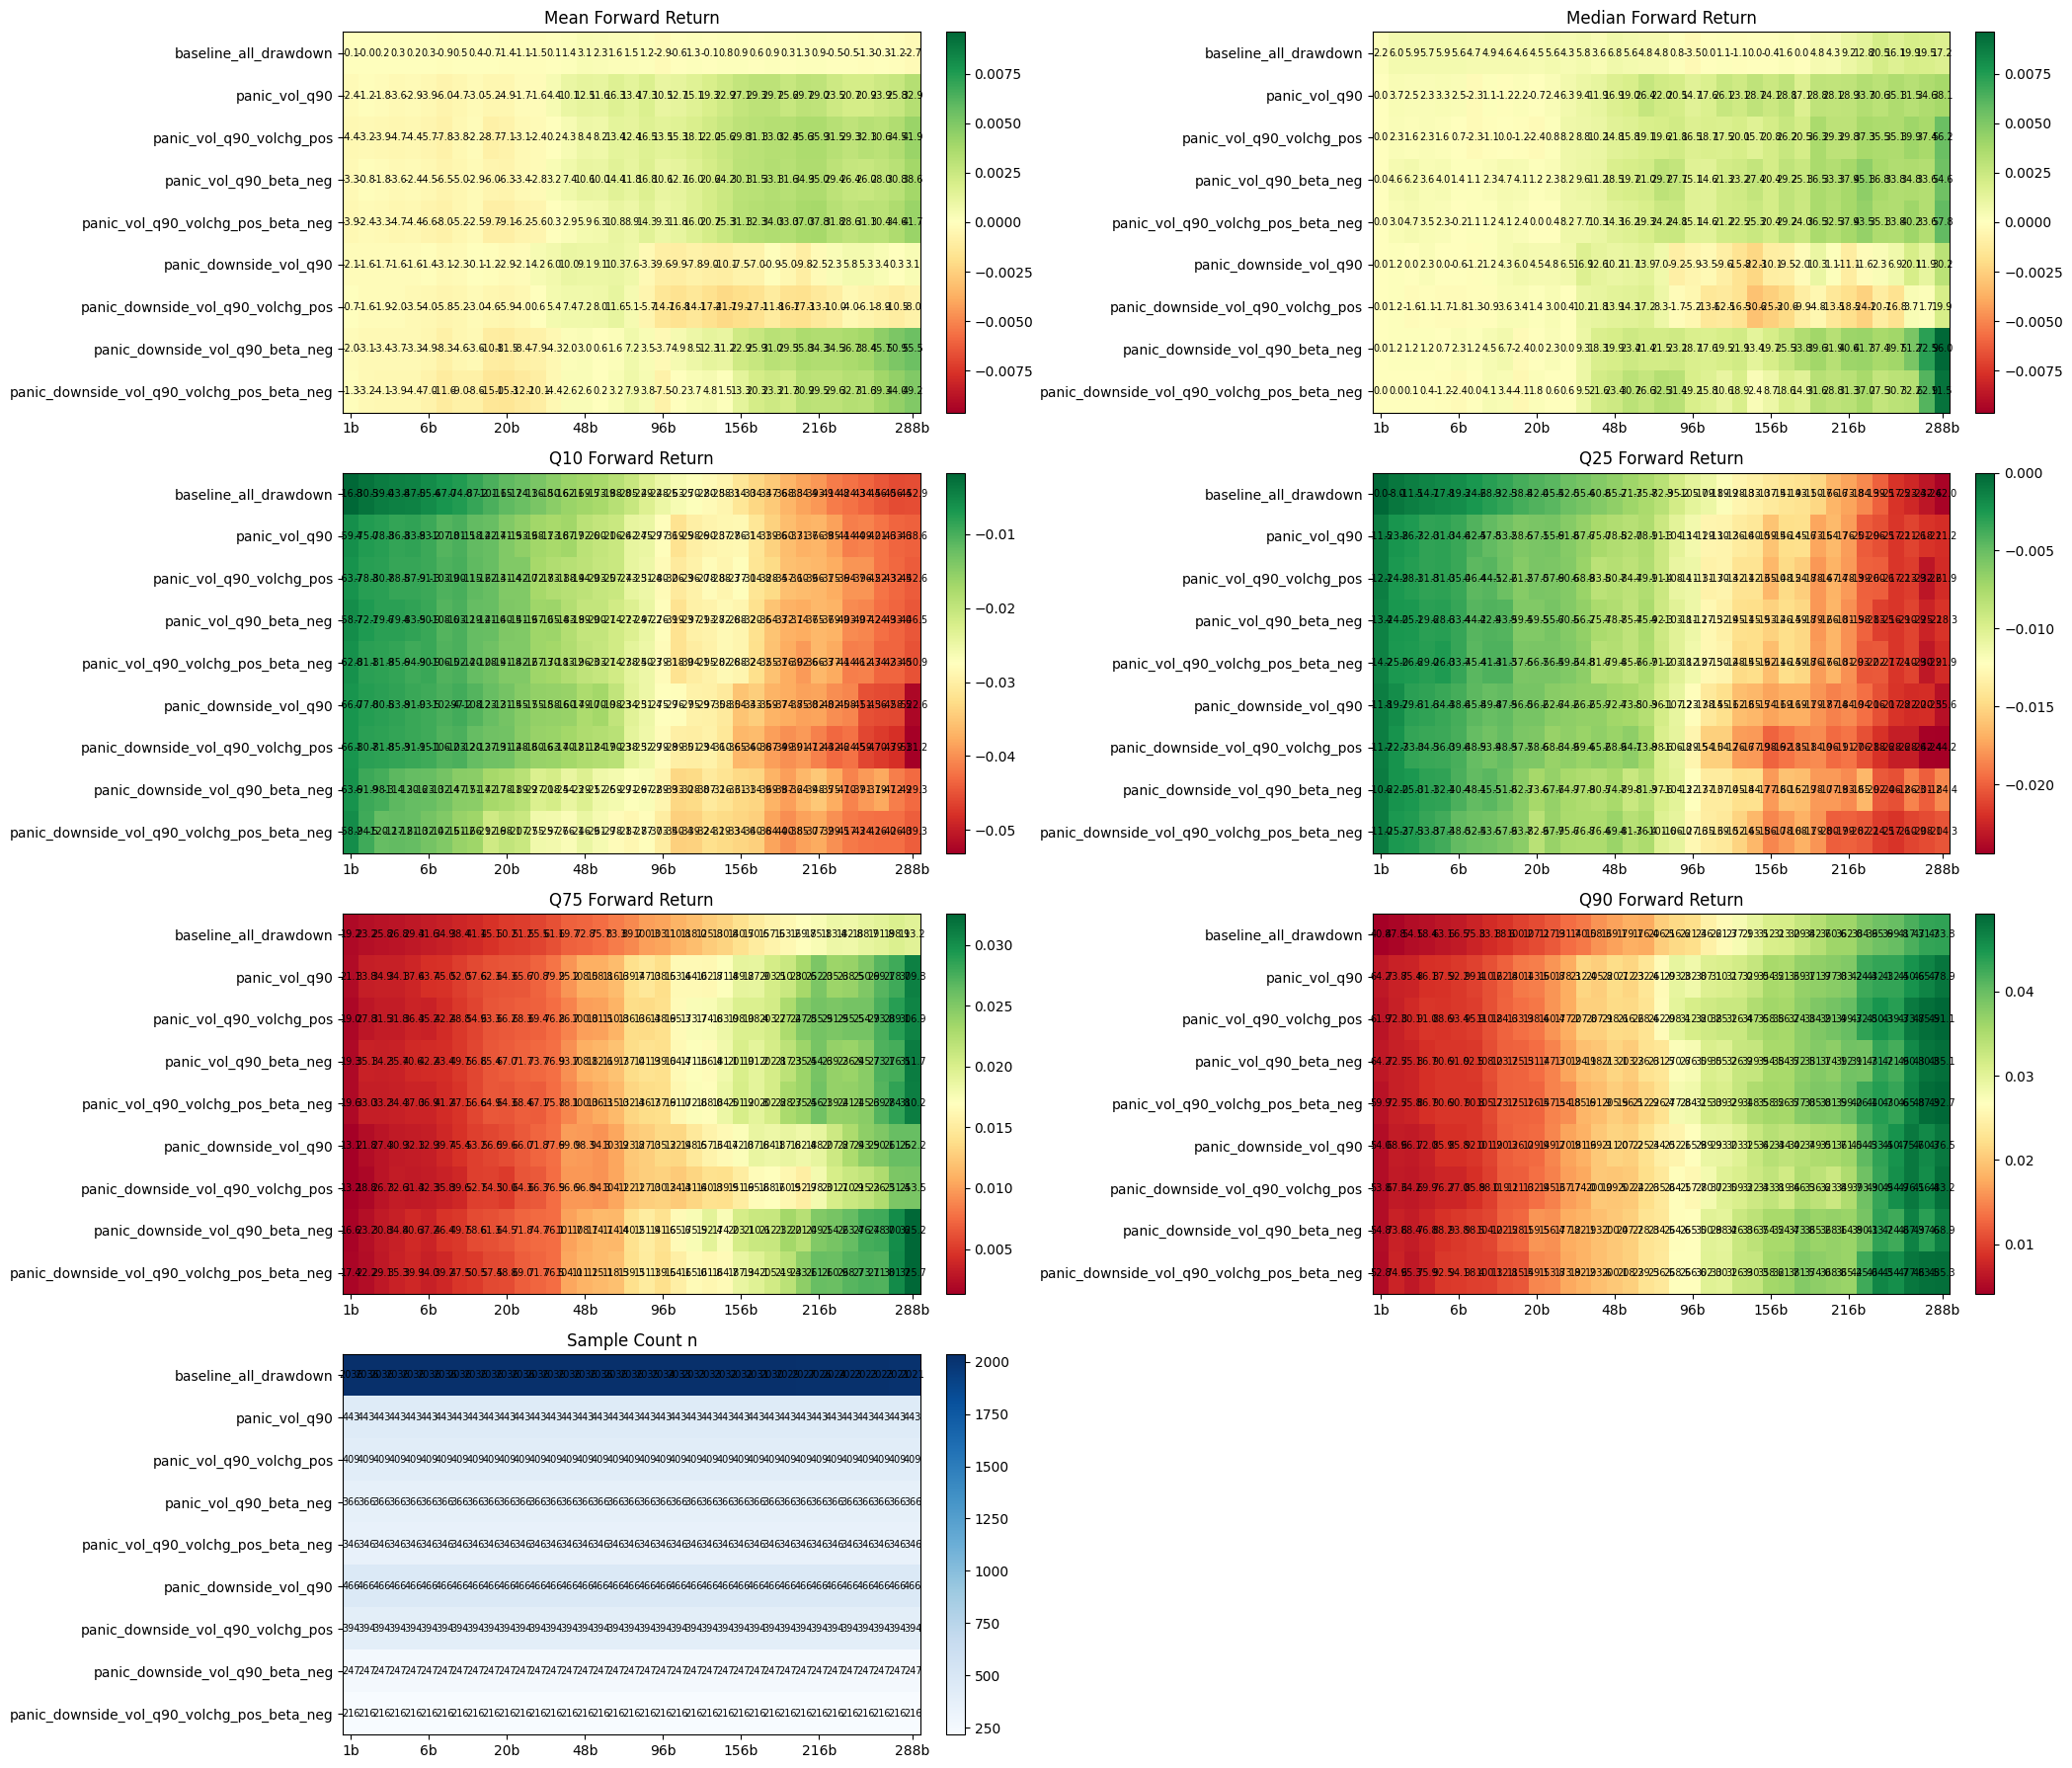

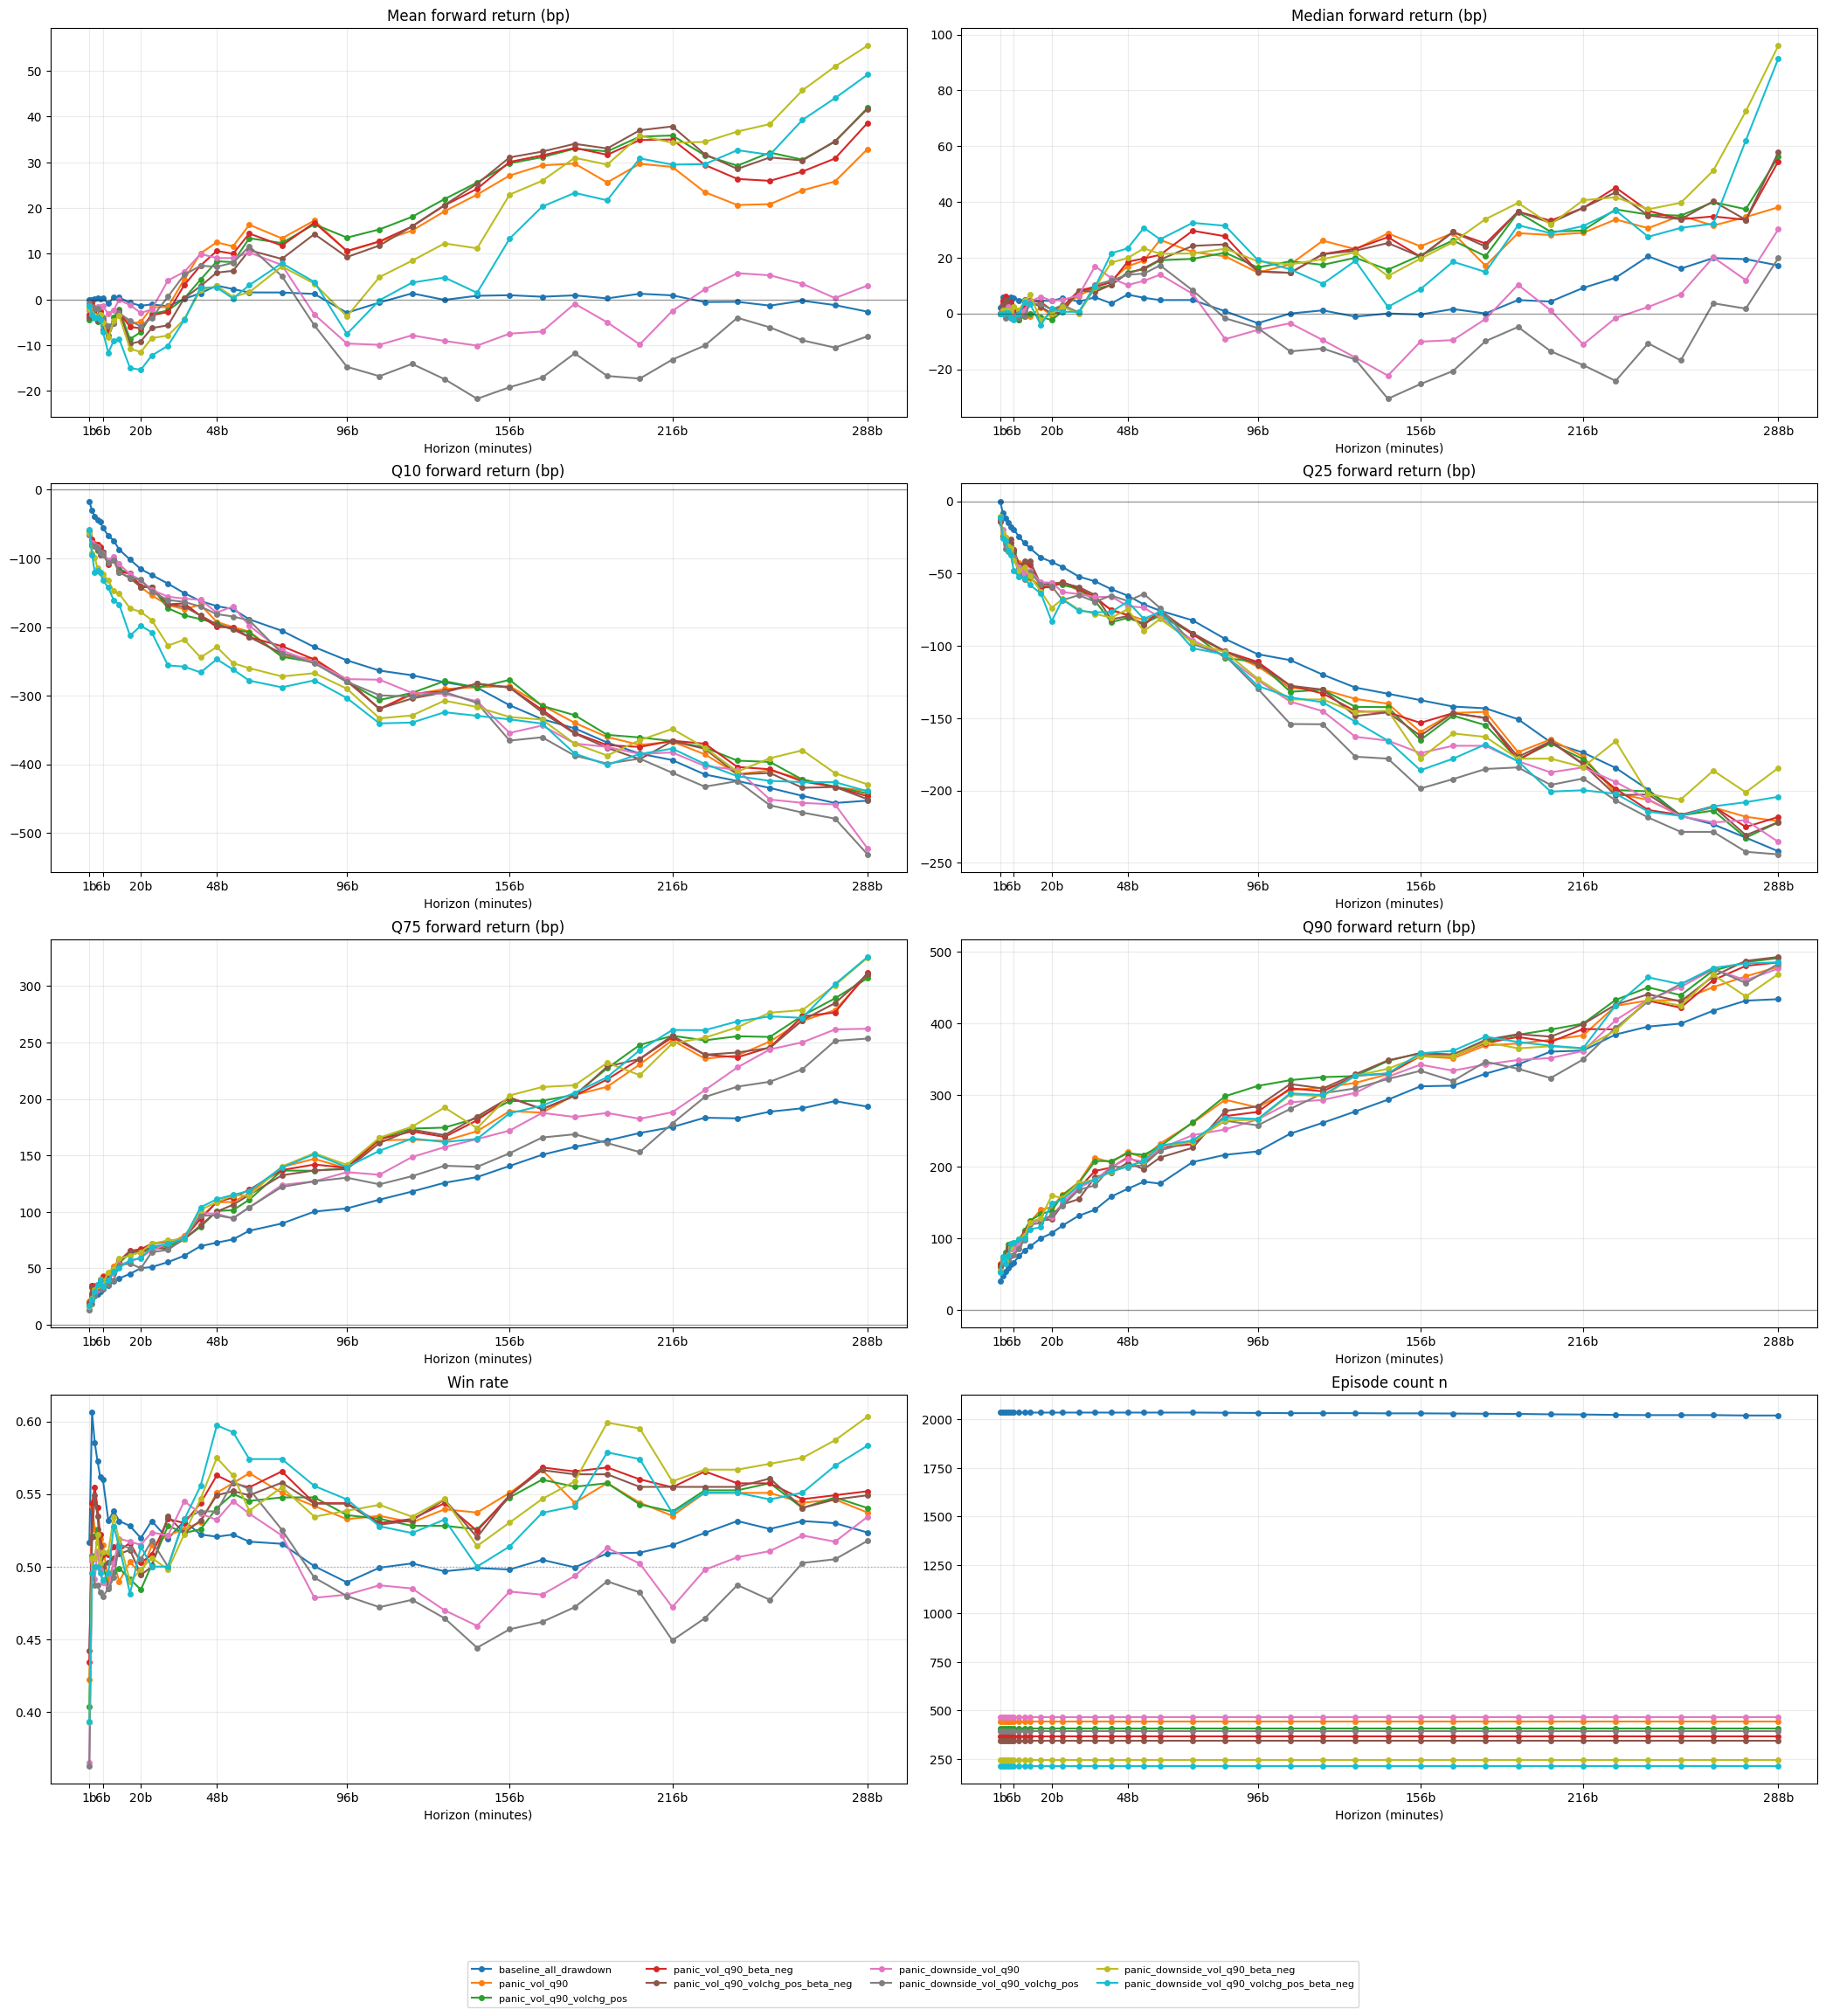

Absolute forward return stats with quantiles (includes baseline + n):


,signal,h,h_min,n,mean,median,q10,q25,q75,q90,p05,p10,win_rate
0,baseline_all_drawdown,1,5,2036,-0.000012,0.000221,-0.001683,0.000000,0.001921,0.004084,-0.006551,-0.001683,0.516699
1,baseline_all_drawdown,2,10,2036,-0.000001,0.000600,-0.003053,-0.000798,0.002324,0.004781,-0.007141,-0.003053,0.606090
2,baseline_all_drawdown,3,15,2036,0.000021,0.000594,-0.003905,-0.001146,0.002579,0.005407,-0.007923,-0.003905,0.585462
3,baseline_all_drawdown,4,20,2036,0.000031,0.000566,-0.004383,-0.001469,0.002683,0.005837,-0.009020,-0.004383,0.572692
4,baseline_all_drawdown,5,25,2036,0.000024,0.000592,-0.004697,-0.001781,0.002942,0.006306,-0.010625,-0.004697,0.561886
...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,panic_downside_vol_q90_volchg_pos_beta_neg,240,1200,216,0.003265,0.002751,-0.041732,-0.021455,0.026865,0.046425,-0.050412,-0.041732,0.550926
329,panic_downside_vol_q90_volchg_pos_beta_neg,252,1260,216,0.003165,0.003069,-0.042413,-0.021758,0.027311,0.045466,-0.054521,-0.042413,0.546296
330,panic_downside_vol_q90_volchg_pos_beta_neg,264,1320,216,0.003927,0.003222,-0.042596,-0.021094,0.027181,0.047756,-0.052528,-0.042596,0.550926
331,panic_downside_vol_q90_volchg_pos_beta_neg,276,1380,216,0.004403,0.006206,-0.042603,-0.020809,0.030165,0.048349,-0.056722,-0.042603,0.569444


Potential distortion warning (n < 200):


,signal,h,h_min,n,mean,median,q10,q25,q75,q90,p05,p10,win_rate


In [89]:
if "panic_eval" not in globals():
    raise RuntimeError("panic_eval not found. Please run the episode-based evaluation cell first.")

signals_order = [
    "baseline_all_drawdown",
    "panic_vol_q90",
    "panic_vol_q90_volchg_pos",
    "panic_vol_q90_beta_neg",
    "panic_vol_q90_volchg_pos_beta_neg",
    "panic_downside_vol_q90",
    "panic_downside_vol_q90_volchg_pos",
    "panic_downside_vol_q90_beta_neg",
    "panic_downside_vol_q90_volchg_pos_beta_neg",
]
plot_abs = panic_eval[panic_eval.signal.isin(signals_order)].copy()
plot_abs["h_min"] = plot_abs["h"] * 5

plot_abs["signal"] = pd.Categorical(plot_abs["signal"], categories=signals_order, ordered=True)
plot_abs = plot_abs.sort_values(["signal", "h"])

# Defensive dedup for plotting: if (signal, h) repeats (e.g., mixed settings),
# aggregate to one row so pivot won't fail.
_dup_mask = plot_abs.duplicated(subset=["signal", "h"], keep=False)
if _dup_mask.any():
    print(f"Warning: duplicate (signal, h) rows detected: {int(_dup_mask.sum())}. Aggregating by mean (n uses max).")
    _num_cols = [c for c in ["mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate", "h_min"] if c in plot_abs.columns]
    _agg = {c: "mean" for c in _num_cols}
    if "n" in plot_abs.columns:
        _agg["n"] = "max"
    plot_abs = plot_abs.groupby(["signal", "h"], as_index=False).agg(_agg)

metric_heat = ["mean", "median", "q10", "q25", "q75", "q90", "n"]
mat_dict = {m: plot_abs.pivot(index="signal", columns="h", values=m) for m in metric_heat}

h_vals = sorted(plot_abs["h"].unique())
# sparse tick labels to avoid overlap
if len(h_vals) > 8:
    xtick_idx = np.linspace(0, len(h_vals) - 1, 8, dtype=int)
else:
    xtick_idx = np.arange(len(h_vals))
xtick_labels = [f"{h_vals[i]}b" for i in xtick_idx]

fig, axes = plt.subplots(4, 2, figsize=(21, 18))
heat_order = ["mean", "median", "q10", "q25", "q75", "q90", "n"]
titles = {
    "mean": "Mean Forward Return",
    "median": "Median Forward Return",
    "q10": "Q10 Forward Return",
    "q25": "Q25 Forward Return",
    "q75": "Q75 Forward Return",
    "q90": "Q90 Forward Return",
    "n": "Sample Count n",
}
cmap_map = {m: "RdYlGn" for m in ["mean", "median", "q10", "q25", "q75", "q90"]}
cmap_map["n"] = "Blues"

# mean & median share one symmetric colorbar (raw log-return units); q10–q90 each auto-scale; n uses count range.
_mm = np.concatenate([mat_dict["mean"].values.ravel(), mat_dict["median"].values.ravel()])
_mm = _mm[np.isfinite(_mm)]
if _mm.size:
    _lim_mm = float(np.nanmax(np.abs(_mm)))
    if _lim_mm == 0:
        _lim_mm = 1e-12
else:
    _lim_mm = 1e-12
vmin_mm, vmax_mm = -_lim_mm, _lim_mm

_nvals = mat_dict["n"].values.ravel()
_nvals = _nvals[np.isfinite(_nvals)]
if _nvals.size:
    vmin_n, vmax_n = float(np.nanmin(_nvals)), float(np.nanmax(_nvals))
    if vmin_n == vmax_n:
        vmax_n = vmin_n + 1.0
else:
    vmin_n, vmax_n = 0.0, 1.0

# 7 heatmaps in first 7 panels
for panel_idx, m in enumerate(heat_order):
    r, c = divmod(panel_idx, 2)
    mat = mat_dict[m]
    if m == "n":
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m], vmin=vmin_n, vmax=vmax_n)
    elif m in ("mean", "median"):
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m], vmin=vmin_mm, vmax=vmax_mm)
    else:
        im = axes[r, c].imshow(mat.values, aspect="auto", cmap=cmap_map[m])
    axes[r, c].set_title(titles[m])
    axes[r, c].set_yticks(np.arange(len(mat.index)))
    axes[r, c].set_yticklabels(mat.index)
    axes[r, c].set_xticks(xtick_idx)
    axes[r, c].set_xticklabels(xtick_labels, rotation=0)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if np.isfinite(v):
                txt = f"{int(v)}" if m == "n" else f"{v*1e4:.1f}"
                axes[r, c].text(j, i, txt, ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=axes[r, c], fraction=0.046, pad=0.04)

# panel 8 unused — line charts are split per metric in the next figure
axes[3, 1].axis("off")

plt.tight_layout()
plt.show()

# Separate line chart per metric (one signal = one color across panels)
_xt_min = np.array([h_vals[i] * 5 for i in xtick_idx])
_xt_lab = [f"{h_vals[i]}b" for i in xtick_idx]
_sig_colors = plt.cm.tab10(np.linspace(0, 1, len(signals_order)))
_sig_color = {sig: _sig_colors[i] for i, sig in enumerate(signals_order)}

_line_specs = [
    ("mean", "Mean forward return (bp)", lambda d: d["mean"].to_numpy(dtype=float) * 1e4, True, None),
    ("median", "Median forward return (bp)", lambda d: d["median"].to_numpy(dtype=float) * 1e4, True, None),
    ("q10", "Q10 forward return (bp)", lambda d: d["q10"].to_numpy(dtype=float) * 1e4, True, None),
    ("q25", "Q25 forward return (bp)", lambda d: d["q25"].to_numpy(dtype=float) * 1e4, True, None),
    ("q75", "Q75 forward return (bp)", lambda d: d["q75"].to_numpy(dtype=float) * 1e4, True, None),
    ("q90", "Q90 forward return (bp)", lambda d: d["q90"].to_numpy(dtype=float) * 1e4, True, None),
    ("win_rate", "Win rate", lambda d: d["win_rate"].to_numpy(dtype=float), False, 0.5),
    ("n", "Episode count n", lambda d: d["n"].to_numpy(dtype=float), False, None),
]

fig_line, axes_line = plt.subplots(4, 2, figsize=(21, 22))
for i, (_col, title, yfn, zero_line, ref_line) in enumerate(_line_specs):
    axl = axes_line.flat[i]
    for sig in signals_order:
        d = plot_abs[plot_abs["signal"] == sig].sort_values("h")
        if len(d) == 0:
            continue
        x = d["h_min"].to_numpy()
        y = yfn(d)
        axl.plot(x, y, marker="o", lw=1.5, ms=4, label=sig, color=_sig_color[sig])
    if zero_line:
        axl.axhline(0, color="black", lw=1, alpha=0.35)
    if ref_line is not None:
        axl.axhline(ref_line, color="gray", lw=1, ls=":", alpha=0.6)
    axl.set_title(title)
    axl.set_xlabel("Horizon (minutes)")
    axl.grid(alpha=0.25)
    axl.set_xticks(_xt_min)
    axl.set_xticklabels(_xt_lab)

handles, labels = axes_line.flat[0].get_legend_handles_labels()
fig_line.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.show()

# detailed table
cols = ["signal", "h", "h_min", "n", "mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate"]
abs_view = plot_abs[cols].copy()
for col in ["mean", "median", "q10", "q25", "q75", "q90", "p05", "p10", "win_rate"]:
    abs_view[col] = abs_view[col].astype(float)

print("Absolute forward return stats with quantiles (includes baseline + n):")
display(abs_view.sort_values(["signal", "h"]))

print("Potential distortion warning (n < 200):")
display(abs_view[abs_view["n"] < 200].sort_values(["signal", "h"]))



### 看看信号持续期
信号持续期可能更重要 => 对信号后走势有预测作用

主要看: duration, price, vol, volume
信号持续时长以及信号期收益

### 信号结束是因为 vol 还是 spot?

In [10]:
sig_copy1 = sig_5m.copy()
# forward 1-bar return (used conceptually for event-rollover aggregation)
sig_copy1["fwd_ret_1"] = sig_copy1["close"].shift(-1) / sig_copy1["close"] - 1.0
sig_copy1 = sig_copy1.join(_forward_return_matrix(sig_5m["close"], PANIC_HORIZONS_5M))

base_mask = sig_copy1["large_drawdown_long"].fillna(False)

# Panic signal family 1: volatility-based   
panic_vol_1 = base_mask & (sig_copy1["volatility"] > sig_copy1["vol_q90"])
panic_vol_2 = panic_vol_1 & (sig_copy1["long_vol_change_since_high"] > 0)
panic_vol_3 = panic_vol_1 & (sig_copy1["long_beta_since_high"] < 0)
panic_vol_4 = panic_vol_1 & (sig_copy1["long_vol_change_since_high"] > 0) & (sig_copy1["long_beta_since_high"] < 0)

# Downside-only volatility test: compare directly against panic_vol_q90
panic_downside_vol_1 = base_mask & (sig_copy1["downside_volatility"] > sig_copy1["downside_vol_q90"])
panic_downside_vol_2 = panic_downside_vol_1 & (sig_copy1["downside_vol_change_since_high"] > 0)
panic_downside_vol_3 = panic_downside_vol_1 & (sig_copy1["long_beta_since_high"] < 0)
panic_downside_vol_4 = panic_downside_vol_1 & (sig_copy1["downside_vol_change_since_high"] > 0) & (sig_copy1["long_beta_since_high"] < 0)

# # Panic signal family 2: volume shock
# panic_volume_shock = base_mask & (
#     (sig_copy1["volume"] > sig_copy1["volume_q90"]) |
#     (sig_copy1["volume_z"] > 2.0)
# )

# # Panic signal family 3: taker volume imbalance shock (sell side pressure)
# panic_taker_imb = base_mask & (sig_copy1["taker_vol_imb"] < sig_copy1["imb_q10"])

signal_masks = {
    "baseline_all_drawdown": base_mask,
    "panic_vol_q90": panic_vol_1,
    "panic_vol_q90_volchg_pos": panic_vol_2,
    "panic_vol_q90_beta_neg": panic_vol_3,
    "panic_vol_q90_volchg_pos_beta_neg": panic_vol_4,
    "panic_downside_vol_q90": panic_downside_vol_1,
    "panic_downside_vol_q90_volchg_pos": panic_downside_vol_2,
    "panic_downside_vol_q90_beta_neg": panic_downside_vol_3,
    "panic_downside_vol_q90_volchg_pos_beta_neg": panic_downside_vol_4,
    # "panic_volume_shock": panic_volume_shock,
    # "panic_taker_imb_sell_shock": panic_taker_imb,
}

episodes = {
    name: _build_episodes(mask) for name, mask in signal_masks.items()
}

In [14]:
# Episode path features by signal (lag0 + lag1)
# lag0: s -> e ; lag1: s+1 -> e (execution shifted by one bar)

if "sig_copy1" not in globals() or "episodes" not in globals():
    raise RuntimeError("Please run the previous episode-analysis cell first (needs sig_copy1 and episodes).")


def _safe_slope(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    m = np.isfinite(x)
    if m.sum() < 2:
        return np.nan
    t = np.arange(len(x), dtype=float)[m]
    y = x[m]
    if len(np.unique(t)) < 2:
        return np.nan
    return float(np.polyfit(t, y, 1)[0])


def _mean_first_last_third(x: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    k = max(1, len(x) // 3)
    return float(np.mean(x[:k])), float(np.mean(x[-k:]))


def _end_location(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    lo, hi = float(np.min(x)), float(np.max(x))
    den = hi - lo
    if den <= 1e-12:
        return np.nan
    return float((x[-1] - lo) / den)


def _time_loc_of_extreme(x: np.ndarray, which: str) -> float:
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x)
    if valid.sum() == 0:
        return np.nan
    den = max(1, len(x) - 1)
    idx = np.flatnonzero(valid)
    xv = x[valid]
    k = int(np.argmin(xv)) if which == "min" else int(np.argmax(xv))
    return float(idx[k] / den)


def _mdd_from_price(p: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    p = p[np.isfinite(p)]
    if len(p) < 2:
        return np.nan
    run_max = np.maximum.accumulate(p)
    dd = p / run_max - 1.0
    return float(np.min(dd))


def _slice_bounds(s: int, e: int, n: int, mode: str):
    if mode == "lag0":
        a, b = s, e
    elif mode == "lag1":
        a, b = s + 1, e
    else:
        raise ValueError(f"unknown mode={mode}")
    if a < 0 or b >= n or a > b:
        return None
    return int(a), int(b)


def _episode_feature_row(df: pd.DataFrame, sig: str, ep_id: int, s: int, e: int, mode: str) -> dict:
    n = len(df)
    se = _slice_bounds(s, e, n, mode)
    if se is None:
        return {}
    a, b = se

    px = df["close"].to_numpy(dtype=float)[a : b + 1]
    vol = df["volatility"].to_numpy(dtype=float)[a : b + 1]
    dvol = df["downside_volatility"].to_numpy(dtype=float)[a : b + 1] if "downside_volatility" in df.columns else np.full_like(vol, np.nan)
    q = df["volume"].to_numpy(dtype=float)[a : b + 1]
    imb = df["taker_vol_imb"].to_numpy(dtype=float)[a : b + 1] if "taker_vol_imb" in df.columns else np.full_like(q, np.nan)
    net_abs = df["net_absorption_z"].to_numpy(dtype=float)[a : b + 1] if "net_absorption_z" in df.columns else np.full_like(q, np.nan)

    if len(px) < 2 or not (np.isfinite(px[0]) and np.isfinite(px[-1]) and px[0] > 0):
        return {}

    ret_path = px / px[0] - 1.0
    vol_first, vol_last = _mean_first_last_third(vol)
    dvol_first, dvol_last = _mean_first_last_third(dvol)
    imb_first, imb_last = _mean_first_last_third(imb)
    abs_first, abs_last = _mean_first_last_third(net_abs)

    return {
        "signal": sig,
        "lag_mode": mode,
        "episode_id": int(ep_id),
        "s": int(s),
        "e": int(e),
        "start_eval": int(a),
        "end_eval": int(b),
        "dur_signal": int(e - s + 1),
        "dur_eval": int(b - a + 1),

        # 1) return-path features
        "ret_end": float(ret_path[-1]),
        "ret_mdd": _mdd_from_price(px),
        "ret_end_location": _end_location(px),
        "ret_tmin_loc": _time_loc_of_extreme(px, "min"),
        "ret_tmax_loc": _time_loc_of_extreme(px, "max"),

        # 2) volatility features
        "vol_mean": float(np.nanmean(vol)) if np.isfinite(vol).any() else np.nan,
        "vol_max": float(np.nanmax(vol)) if np.isfinite(vol).any() else np.nan,
        "vol_end": float(vol[-1]) if np.isfinite(vol[-1]) else np.nan,
        "vol_slope": _safe_slope(vol),
        "vol_acceleration": (vol_last - vol_first) if np.isfinite(vol_first) and np.isfinite(vol_last) else np.nan,
        "vol_end_location": _end_location(vol),
        "vol_tmin_loc": _time_loc_of_extreme(vol, "min"),
        "vol_tmax_loc": _time_loc_of_extreme(vol, "max"),

        # 3) downside-vol
        "dvol_mean": float(np.nanmean(dvol)) if np.isfinite(dvol).any() else np.nan,
        "dvol_max": float(np.nanmax(dvol)) if np.isfinite(dvol).any() else np.nan,
        "dvol_end": float(dvol[-1]) if np.isfinite(dvol[-1]) else np.nan,
        "dvol_slope": _safe_slope(dvol),
        "dvol_acceleration": (dvol_last - dvol_first) if np.isfinite(dvol_first) and np.isfinite(dvol_last) else np.nan,
        "dvol_end_location": _end_location(dvol),
        "dvol_tmin_loc": _time_loc_of_extreme(dvol, "min"),
        "dvol_tmax_loc": _time_loc_of_extreme(dvol, "max"),

        # 4) volume / imbalance features
        "volume_slope": _safe_slope(q),
        "volume_climax_loc": _time_loc_of_extreme(q, "max"),
        "cumulative_imb": float(np.nansum(imb)) if np.isfinite(imb).any() else np.nan,
        "cvi": float(np.nansum(q * imb)) if np.isfinite(q).any() and np.isfinite(imb).any() else np.nan,
        "imb_improve": (imb_last - imb_first) if np.isfinite(imb_first) and np.isfinite(imb_last) else np.nan,

        # 5) net absorption features (+ positive/negative fractions)
        "net_abs_mean": float(np.nanmean(net_abs)) if np.isfinite(net_abs).any() else np.nan,
        "net_abs_max": float(np.nanmax(net_abs)) if np.isfinite(net_abs).any() else np.nan,
        "net_abs_end": float(net_abs[-1]) if np.isfinite(net_abs[-1]) else np.nan,
        "net_abs_slope": _safe_slope(net_abs),
        "net_abs_acceleration": (abs_last - abs_first) if np.isfinite(abs_first) and np.isfinite(abs_last) else np.nan,
        "net_abs_end_location": _end_location(net_abs),
        "net_abs_tmin_loc": _time_loc_of_extreme(net_abs, "min"),
        "net_abs_tmax_loc": _time_loc_of_extreme(net_abs, "max"),
        "net_abs_pos_frac": float(np.nanmean(net_abs > 0)) if np.isfinite(net_abs).any() else np.nan,
        "net_abs_neg_frac": float(np.nanmean(net_abs < 0)) if np.isfinite(net_abs).any() else np.nan,
    }


rows = []
for sig, eps in episodes.items():
    for ep_id, (s, e) in enumerate(eps):
        for mode in ("lag0", "lag1"):
            rec = _episode_feature_row(sig_copy1, sig, ep_id, int(s), int(e), mode)
            if rec:
                rows.append(rec)

episode_path_features = pd.DataFrame(rows)

summary_cols = [
    "dur_eval", "ret_end", "ret_mdd", "ret_end_location", "ret_tmin_loc", "ret_tmax_loc",
    "vol_mean", "vol_max", "vol_end", "vol_slope", "vol_acceleration", "vol_end_location", "vol_tmin_loc", "vol_tmax_loc",
    "volume_slope", "volume_climax_loc", "cumulative_imb", "cvi", "imb_improve",
    "net_abs_mean", "net_abs_max", "net_abs_end", "net_abs_slope", "net_abs_acceleration",
    "net_abs_end_location", "net_abs_tmin_loc", "net_abs_tmax_loc", "net_abs_pos_frac", "net_abs_neg_frac",
]

if len(episode_path_features):
    g = episode_path_features.groupby(["signal", "lag_mode"], dropna=False)
    episode_path_summary = g[summary_cols].agg(["mean", "median", "std"])
    episode_path_summary = g.size().rename("n_episodes").to_frame().join(episode_path_summary)

    print("Episode path feature summary by signal x lag mode:")
    display(episode_path_summary)

    print("Episode path feature sample (first 30 rows):")
    display(episode_path_features.head(30))
else:
    episode_path_summary = pd.DataFrame()
    print("No episode path features generated.")

print("Computed tables: episode_path_features, episode_path_summary")


Episode path feature summary by signal x lag mode:


/var/folders/q5/v23901210wn8qr147kytfclm0000gn/T/ipykernel_30930/1894391659.py:178: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (1 levels on the left, 2 on the right)
  episode_path_summary = g.size().rename("n_episodes").to_frame().join(episode_path_summary)


n_episodes  \
signal                                     lag_mode               
baseline_all_drawdown                      lag0            1431   
                                           lag1            1123   
panic_downside_vol_q90                     lag0             334   
                                           lag1             275   
panic_downside_vol_q90_beta_neg            lag0             182   
                                           lag1             149   
panic_downside_vol_q90_volchg_pos          lag0             281   
                                           lag1             233   
panic_downside_vol_q90_volchg_pos_beta_neg lag0             159   
                                           lag1             130   
panic_vol_q90                              lag0             338   
                                           lag1             292   
panic_vol_q90_beta_neg                     lag0             289   
                                           lag1             239   
panic_vol_q90_volchg_pos                   lag0             307   
                                           lag1             261   
panic_vol_q90_volchg_pos_beta_neg          lag0             276   
                                           lag1             232   

                                                     (dur_eval, mean)  \
signal                                     lag_mode                     
baseline_all_drawdown                      lag0             15.228512   
                                           lag1             17.856634   
panic_downside_vol_q90                     lag0             10.805389   
                                           lag1             11.694545   
panic_downside_vol_q90_beta_neg            lag0             10.857143   
                                           lag1             11.818792   
panic_downside_vol_q90_volchg_pos          lag0             11.110320   
                                           lag1             11.987124   
panic_downside_vol_q90_volchg_pos_beta_neg lag0             10.981132   
                                           lag1             11.984615   
panic_vol_q90                              lag0             10.508876   
                                           lag1             10.849315   
panic_vol_q90_beta_neg                     lag0             10.404844   
                                           lag1             11.163180   
panic_vol_q90_volchg_pos                   lag0             10.410423   
                                           lag1             10.892720   
panic_vol_q90_volchg_pos_beta_neg          lag0             10.503623   
                                           lag1             11.116379   

                                                     (dur_eval, median)  \
signal                                     lag_mode                       
baseline_all_drawdown                      lag0                     5.0   
                                           lag1                     6.0   
panic_downside_vol_q90                     lag0                     7.0   
                                           lag1                     7.0   
panic_downside_vol_q90_beta_neg            lag0                     7.0   
                                           lag1                     8.0   
panic_downside_vol_q90_volchg_pos          lag0                     7.0   
                                           lag1                     8.0   
panic_downside_vol_q90_volchg_pos_beta_neg lag0                     7.0   
                                           lag1                     8.5   
panic_vol_q90                              lag0                     6.0   
                                           lag1                     7.0   
panic_vol_q90_beta_neg                     lag0                     6.0   
                                           lag1                     7.0   
panic_vol_q90_volchg_pos                   lag0    

Episode path feature sample (first 30 rows):


,signal,lag_mode,episode_id,s,e,start_eval,end_eval,dur_signal,dur_eval,ret_end,...,net_abs_mean,net_abs_max,net_abs_end,net_abs_slope,net_abs_acceleration,net_abs_end_location,net_abs_tmin_loc,net_abs_tmax_loc,net_abs_pos_frac,net_abs_neg_frac
0,baseline_all_drawdown,lag0,0,6,11,6,11,6,6,-0.002879,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
1,baseline_all_drawdown,lag1,0,6,11,7,11,6,5,-0.002719,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
2,baseline_all_drawdown,lag0,2,15,16,15,16,2,2,-0.000881,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
3,baseline_all_drawdown,lag0,3,18,20,18,20,3,3,-0.001202,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
4,baseline_all_drawdown,lag1,3,18,20,19,20,3,2,0.001205,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
5,baseline_all_drawdown,lag0,5,33,35,33,35,3,3,0.000241,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
6,baseline_all_drawdown,lag1,5,33,35,34,35,3,2,-0.000241,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
7,baseline_all_drawdown,lag0,6,42,66,42,66,25,25,-0.005537,...,0.121387,3.216484,0.750704,0.025903,0.501799,0.698839,0.500000,0.708333,0.560000,0.440000
8,baseline_all_drawdown,lag1,6,42,66,43,66,25,24,-0.004978,...,0.152435,3.216484,0.750704,0.021183,0.467206,0.698839,0.478261,0.695652,0.583333,0.416667
9,baseline_all_drawdown,lag0,10,81,82,81,82,2,2,0.000000,...,-0.938392,-0.630551,-1.246233,-0.615682,-0.615682,0.000000,1.000000,0.000000,0.000000,1.000000


Computed tables: episode_path_features, episode_path_summary


### 不同的 panic 会不会有重合？ 是否要排除有重合的样本？

In [15]:
# Fixed-horizon overlap diagnostics (corrected: drop last episode)
# Rule: no-overlap is defined only against NEXT signal start; last episode is excluded.

if "episodes" not in globals():
    raise RuntimeError("Please run the episode-building cell first (needs episodes dict).")


def _max_horizons_from_episode_starts_v2(eps: list[tuple[int, int]], mode: str = "lag0"):
    """
    For each episode i with next signal:
      lag0: t0 = s
      lag1: t0 = s + 1
    no-overlap to next start s_next:
      t0 + h < s_next  =>  h <= s_next - t0 - 1

    Last episode is dropped by design (no next signal).
    """
    if len(eps) <= 1:
        return np.array([], dtype=float)

    starts = np.array([s for s, _ in eps], dtype=int)
    starts_cur = starts[:-1]
    starts_next = starts[1:]

    if mode == "lag0":
        t0 = starts_cur
    elif mode == "lag1":
        t0 = starts_cur + 1
    else:
        raise ValueError(mode)

    h_allow = (starts_next - t0 - 1).astype(float)
    # invalid if lag1 start already reaches next signal start
    h_allow = np.where(h_allow >= 0, h_allow, np.nan)
    return h_allow


def _overlap_rate_for_h_v2(eps: list[tuple[int, int]], h: int, mode: str = "lag0") -> float:
    if len(eps) <= 1:
        return 0.0
    starts = np.array([s for s, _ in eps], dtype=int)
    t0 = starts[:-1] if mode == "lag0" else (starts[:-1] + 1)
    next_starts = starts[1:]
    t1 = t0 + int(h)
    ov = (t1 >= next_starts)
    return float(np.mean(ov))


rows = []
for sig, eps in episodes.items():
    h0 = _max_horizons_from_episode_starts_v2(eps, mode="lag0")
    h1 = _max_horizons_from_episode_starts_v2(eps, mode="lag1")

    row = {
        "signal": sig,
        "n_episodes": int(len(eps)),
        "n_episodes_effective": int(max(0, len(eps) - 1)),  # dropped last episode
        "max_h_strict_lag0": int(np.nanmin(h0)) if len(h0) else np.nan,
        "max_h_strict_lag1": int(np.nanmin(h1)) if len(h1) else np.nan,
        "max_h_p10_lag0": float(np.nanquantile(h0, 0.10)) if len(h0) else np.nan,
        "max_h_p25_lag0": float(np.nanquantile(h0, 0.25)) if len(h0) else np.nan,
        "max_h_median_lag0": float(np.nanmedian(h0)) if len(h0) else np.nan,
        "max_h_p10_lag1": float(np.nanquantile(h1, 0.10)) if len(h1) else np.nan,
        "max_h_p25_lag1": float(np.nanquantile(h1, 0.25)) if len(h1) else np.nan,
        "max_h_median_lag1": float(np.nanmedian(h1)) if len(h1) else np.nan,
    }

    for H in [1, 3, 6, 12, 24, 48]:
        row[f"overlap_rate_h{H}_lag0"] = _overlap_rate_for_h_v2(eps, H, mode="lag0")
        row[f"overlap_rate_h{H}_lag1"] = _overlap_rate_for_h_v2(eps, H, mode="lag1")

    rows.append(row)

horizon_overlap_summary_v2 = pd.DataFrame(rows).sort_values("max_h_strict_lag1")

print("Fixed-horizon overlap diagnostics v2 (last episode dropped):")
display(horizon_overlap_summary_v2)

print("Quick recommendation (lag1 strict <= 24 bars):")
display(
    horizon_overlap_summary_v2[[
        "signal", "n_episodes", "n_episodes_effective",
        "max_h_strict_lag1", "max_h_median_lag1", "overlap_rate_h24_lag1"
    ]].sort_values("max_h_strict_lag1")
)


Fixed-horizon overlap diagnostics v2 (last episode dropped):


,signal,n_episodes,n_episodes_effective,max_h_strict_lag0,max_h_strict_lag1,max_h_p10_lag0,max_h_p25_lag0,max_h_median_lag0,max_h_p10_lag1,max_h_p25_lag1,...,overlap_rate_h3_lag0,overlap_rate_h3_lag1,overlap_rate_h6_lag0,overlap_rate_h6_lag1,overlap_rate_h12_lag0,overlap_rate_h12_lag1,overlap_rate_h24_lag0,overlap_rate_h24_lag1,overlap_rate_h48_lag0,overlap_rate_h48_lag1
0,baseline_all_drawdown,2036,2035,1,0,2.0,4.0,8.0,1.0,3.0,...,0.168059,0.233907,0.343980,0.413759,0.624079,0.650614,0.819165,0.825553,0.915971,0.916953
1,panic_vol_q90,443,442,1,0,2.0,6.0,16.0,1.0,5.0,...,0.113122,0.156109,0.242081,0.282805,0.423077,0.443439,0.563348,0.567873,0.642534,0.642534
2,panic_vol_q90_volchg_pos,409,408,1,0,2.0,6.0,19.0,1.0,5.0,...,0.107843,0.144608,0.218137,0.252451,0.392157,0.411765,0.514706,0.524510,0.615196,0.615196
3,panic_vol_q90_beta_neg,366,365,1,0,3.0,8.0,28.0,2.0,7.0,...,0.082192,0.112329,0.183562,0.210959,0.345205,0.367123,0.471233,0.473973,0.575342,0.578082
4,panic_vol_q90_volchg_pos_beta_neg,346,345,1,0,3.0,8.0,32.0,2.0,7.0,...,0.078261,0.110145,0.171014,0.194203,0.327536,0.344928,0.446377,0.449275,0.547826,0.553623
5,panic_downside_vol_q90,466,465,1,0,2.0,5.0,17.0,1.0,4.0,...,0.109677,0.169892,0.258065,0.283871,0.425806,0.447312,0.559140,0.563441,0.653763,0.653763
6,panic_downside_vol_q90_volchg_pos,394,393,1,0,2.0,6.0,21.0,1.0,5.0,...,0.109415,0.167939,0.239186,0.262087,0.381679,0.407125,0.508906,0.511450,0.610687,0.613232
7,panic_downside_vol_q90_beta_neg,247,246,1,0,2.5,8.0,33.0,1.5,7.0,...,0.101626,0.146341,0.211382,0.231707,0.353659,0.365854,0.459350,0.463415,0.528455,0.536585
8,panic_downside_vol_q90_volchg_pos_beta_neg,216,215,1,0,2.0,8.0,46.0,1.0,7.0,...,0.120930,0.162791,0.218605,0.227907,0.353488,0.358140,0.432558,0.437209,0.506977,0.516279


Quick recommendation (lag1 strict <= 24 bars):


,signal,n_episodes,n_episodes_effective,max_h_strict_lag1,max_h_median_lag1,overlap_rate_h24_lag1
0,baseline_all_drawdown,2036,2035,0,7.0,0.825553
1,panic_vol_q90,443,442,0,15.0,0.567873
2,panic_vol_q90_volchg_pos,409,408,0,18.0,0.524510
3,panic_vol_q90_beta_neg,366,365,0,27.0,0.473973
4,panic_vol_q90_volchg_pos_beta_neg,346,345,0,31.0,0.449275
5,panic_downside_vol_q90,466,465,0,16.0,0.563441
6,panic_downside_vol_q90_volchg_pos,394,393,0,20.0,0.511450
7,panic_downside_vol_q90_beta_neg,247,246,0,32.0,0.463415
8,panic_downside_vol_q90_volchg_pos_beta_neg,216,215,0,45.0,0.437209


In [ ]:
# Fixed-horizon overlap diagnostics by signal
# Purpose: check whether a long horizon overlaps with the next signal's timeline.

if "episodes" not in globals():
    raise RuntimeError("Please run the episode-building cell first (needs episodes dict).")


def _max_horizons_from_episode_starts(eps: list[tuple[int, int]], n: int, mode: str = "lag0"):
    """
    For each episode i, define window start t0:
      lag0: t0 = s
      lag1: t0 = s + 1
    The no-overlap condition to next signal start s_next is:
      t0 + h < s_next  => h <= s_next - t0 - 1
    Also cap by available data end: h <= (n - 1) - t0
    """
    if len(eps) == 0:
        return np.array([], dtype=float)

    starts = np.array([s for s, _ in eps], dtype=int)
    if mode == "lag0":
        t0 = starts
    elif mode == "lag1":
        t0 = starts + 1
    else:
        raise ValueError(mode)

    next_starts = np.r_[starts[1:], np.nan]
    h_next = next_starts - t0 - 1
    h_allow = h_next.astype(float)

    # Remove last episode if it can't reach next signal or to end of data
    valid_mask = (t0 + h_allow < n)
    h_allow = np.where(valid_mask, h_allow, np.nan)

    return h_allow


def _overlap_rate_for_h(eps: list[tuple[int, int]], h: int, mode: str = "lag0") -> float:
    if len(eps) <= 1:
        return 0.0
    starts = np.array([s for s, _ in eps], dtype=int)
    t0 = starts if mode == "lag0" else (starts + 1)
    t1 = t0 + int(h)
    next_starts = starts[1:]
    # overlap if horizon end reaches or passes next signal start
    ov = (t1[:-1] >= next_starts)
    return float(np.mean(ov))


n_total = len(sig_copy1) if "sig_copy1" in globals() else len(sig_5m)
rows = []
for sig, eps in episodes.items():
    h0 = _max_horizons_from_episode_starts(eps, n_total, mode="lag0")
    h1 = _max_horizons_from_episode_starts(eps, n_total, mode="lag1")

    row = {
        "signal": sig,
        "n_episodes": int(len(eps)),

        # strict (all episodes no-overlap)
        "max_h_strict_lag0": int(np.nanmin(h0)) if len(h0) else np.nan,
        "max_h_strict_lag1": int(np.nanmin(h1)) if len(h1) else np.nan,

        # distribution of feasible horizons
        "max_h_p10_lag0": float(np.nanquantile(h0, 0.10)) if len(h0) else np.nan,
        "max_h_p25_lag0": float(np.nanquantile(h0, 0.25)) if len(h0) else np.nan,
        "max_h_median_lag0": float(np.nanmedian(h0)) if len(h0) else np.nan,
        "max_h_p10_lag1": float(np.nanquantile(h1, 0.10)) if len(h1) else np.nan,
        "max_h_p25_lag1": float(np.nanquantile(h1, 0.25)) if len(h1) else np.nan,
        "max_h_median_lag1": float(np.nanmedian(h1)) if len(h1) else np.nan,
    }

    for H in [1, 3, 6, 12, 24, 48]:
        row[f"overlap_rate_h{H}_lag0"] = _overlap_rate_for_h(eps, H, mode="lag0")
        row[f"overlap_rate_h{H}_lag1"] = _overlap_rate_for_h(eps, H, mode="lag1")

    rows.append(row)

horizon_overlap_summary = pd.DataFrame(rows).sort_values("max_h_strict_lag1")

print("Fixed-horizon overlap diagnostics (sorted by strict lag1 max horizon):")
display(horizon_overlap_summary)

print("Quick recommendation (lag1 strict <= 24 bars):")
display(
    horizon_overlap_summary[["signal", "n_episodes", "max_h_strict_lag1", "max_h_median_lag1", "overlap_rate_h24_lag1"]]
    .sort_values("max_h_strict_lag1")
)


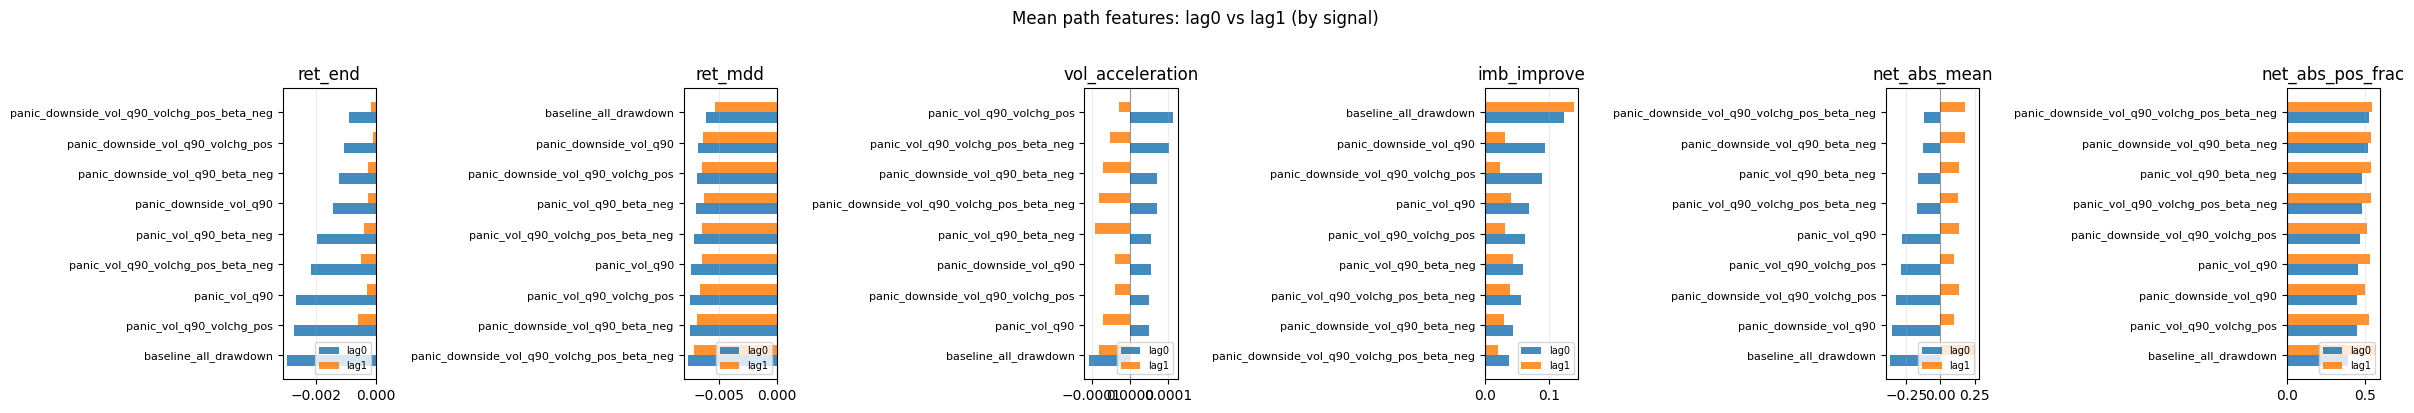

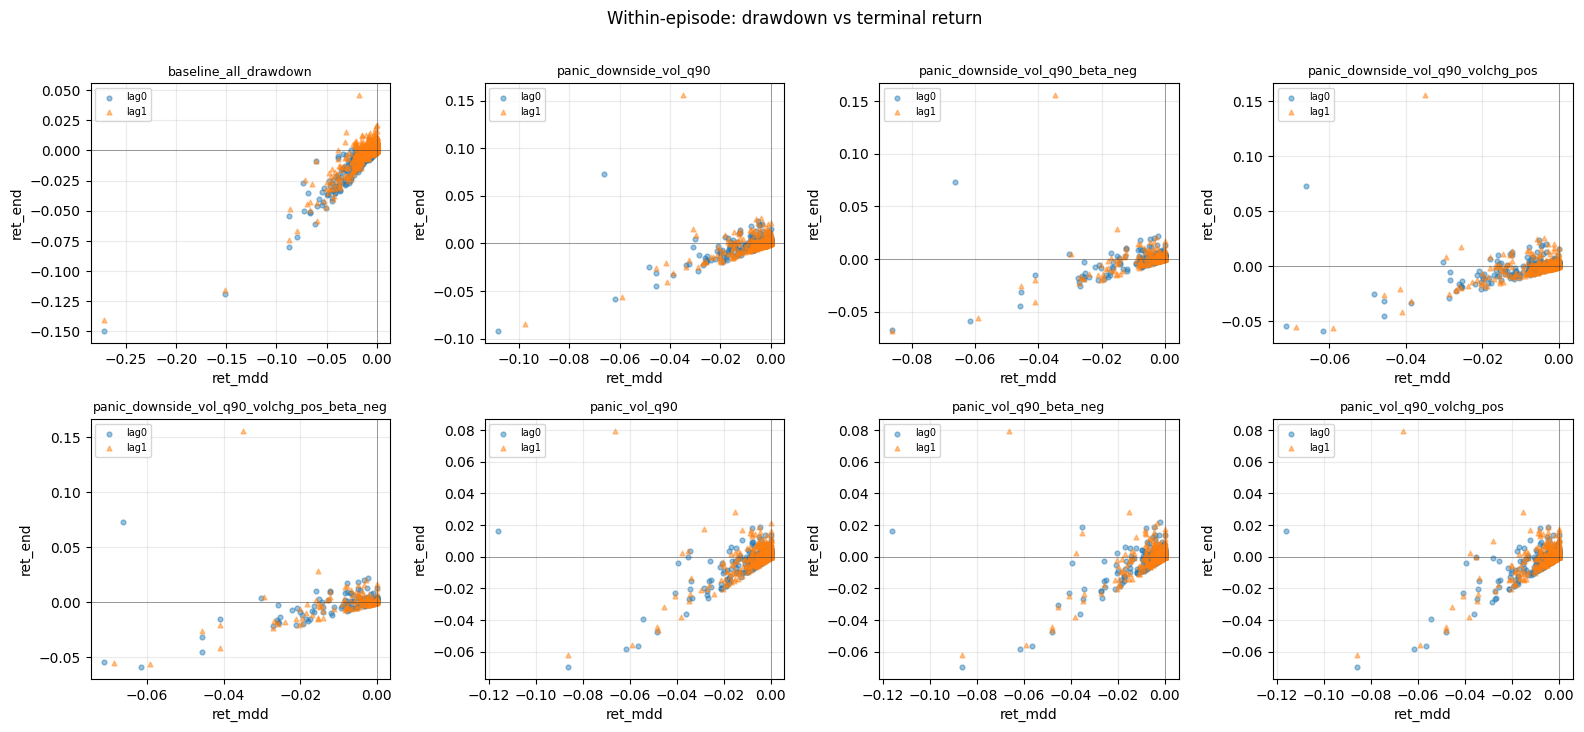

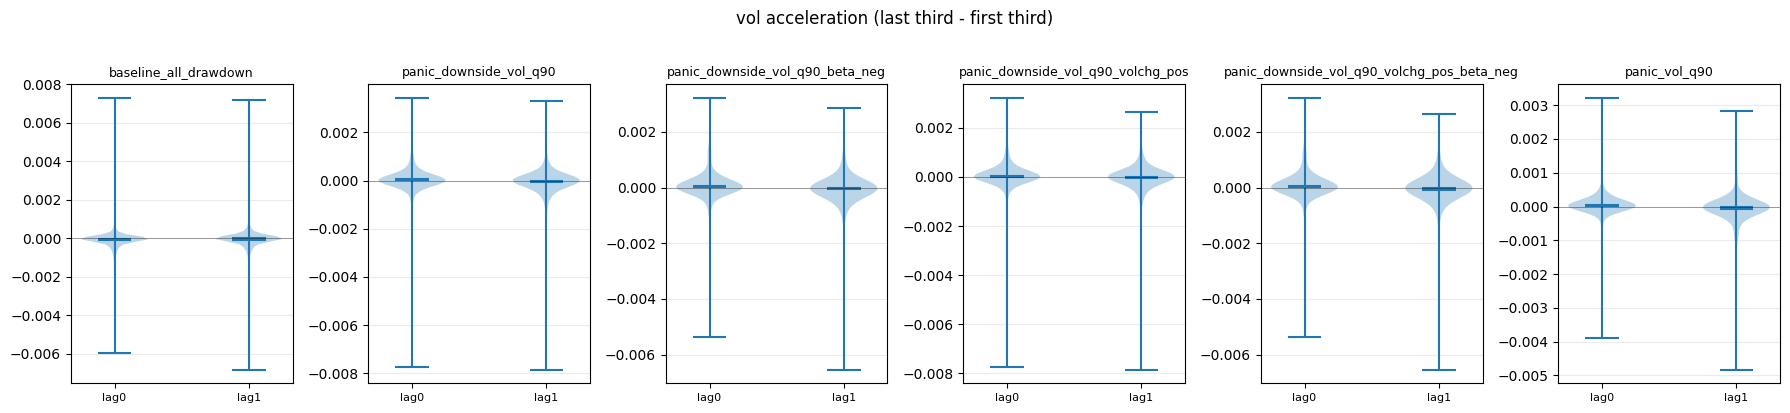

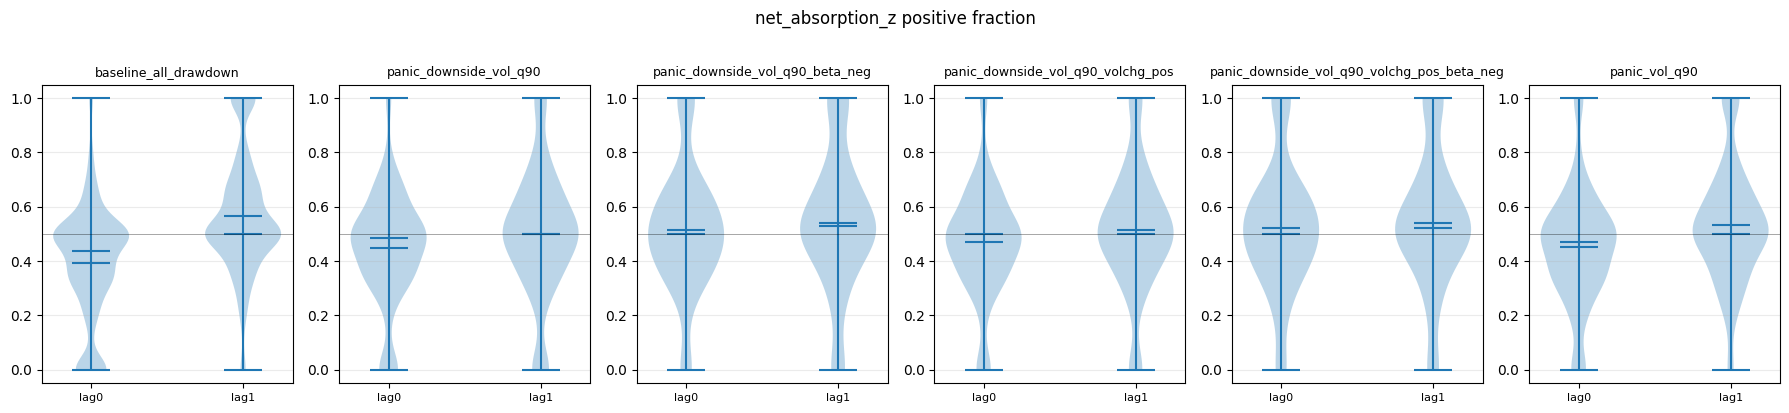

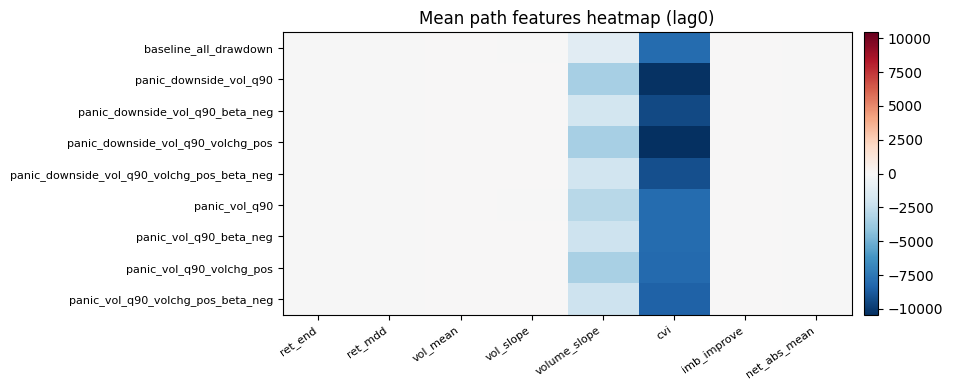

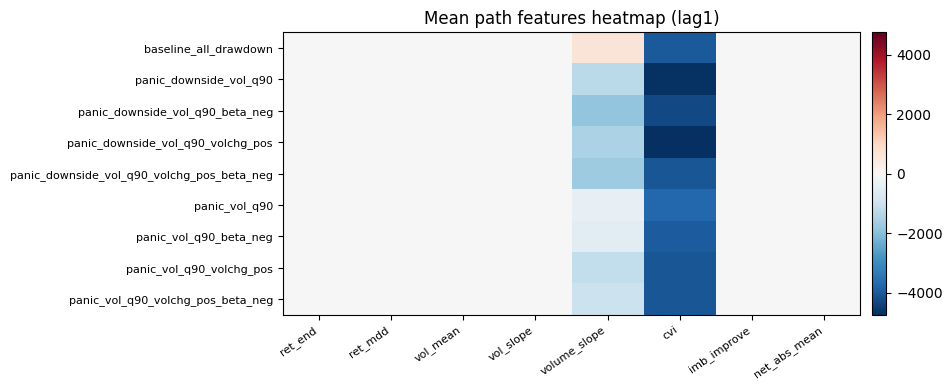

Path feature visuals done.


In [13]:
# Episode path features — quick visuals (run after episode_path_features cell)

if "episode_path_features" not in globals() or len(episode_path_features) == 0:
    raise RuntimeError("Run the episode path features cell first (episode_path_features is empty).")

_feat = episode_path_features.copy()
_feat["lag_mode"] = _feat["lag_mode"].astype(str)

# focus on signals with enough episodes in both lag modes
_cnt = _feat.groupby(["signal", "lag_mode"]).size().unstack(fill_value=0)
if "lag0" in _cnt.columns and "lag1" in _cnt.columns:
    _ok = _cnt[(_cnt["lag0"] >= 10) & (_cnt["lag1"] >= 10)].index.tolist()
else:
    _ok = _feat["signal"].unique().tolist()
if not _ok:
    _ok = _feat["signal"].unique().tolist()
_feat_plot = _feat[_feat["signal"].isin(_ok)].copy()

# --- 1) lag0 vs lag1: paired mean comparison (top metrics) ---
_metrics_bar = [
    "ret_end", "ret_mdd", "vol_acceleration", "imb_improve",
    "net_abs_mean", "net_abs_pos_frac",
]
_metrics_bar = [m for m in _metrics_bar if m in _feat_plot.columns]
if _metrics_bar:
    gmean = _feat_plot.groupby(["signal", "lag_mode"])[_metrics_bar].mean().reset_index()
    pivot = gmean.pivot(index="signal", columns="lag_mode", values=_metrics_bar)
    n_m = len(_metrics_bar)
    fig, axes = plt.subplots(1, n_m, figsize=(4 * n_m, max(4, 0.35 * len(_ok))), squeeze=False)
    axes = axes.ravel()
    for ax, m in zip(axes, _metrics_bar):
        if m not in gmean.columns:
            continue
        sub = gmean.pivot(index="signal", columns="lag_mode", values=m)
        if "lag0" not in sub.columns or "lag1" not in sub.columns:
            continue
        sub = sub.loc[_ok].sort_values("lag0")
        y = np.arange(len(sub))
        w = 0.35
        ax.barh(y - w / 2, sub["lag0"], height=w, label="lag0", alpha=0.85)
        ax.barh(y + w / 2, sub["lag1"], height=w, label="lag1", alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(sub.index, fontsize=8)
        ax.set_title(m)
        ax.axvline(0, color="black", lw=0.8, alpha=0.35)
        ax.grid(axis="x", alpha=0.25)
        ax.legend(fontsize=7, loc="lower right")
    plt.suptitle("Mean path features: lag0 vs lag1 (by signal)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

# --- 2) ret_mdd vs ret_end scatter (lag overlay, subset of signals if many) ---
_sig_scatter = _ok[: min(8, len(_ok))]
sub2 = _feat_plot[_feat_plot["signal"].isin(_sig_scatter)]
if len(sub2) and "ret_mdd" in sub2.columns and "ret_end" in sub2.columns:
    n_s = len(_sig_scatter)
    ncols = min(4, n_s)
    nrows = int(np.ceil(n_s / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.6 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, sig in zip(axes, _sig_scatter):
        d = sub2[sub2["signal"] == sig]
        for lm, mk in [("lag0", "o"), ("lag1", "^")]:
            dd = d[d["lag_mode"] == lm]
            if len(dd) == 0:
                continue
            ax.scatter(dd["ret_mdd"], dd["ret_end"], s=12, alpha=0.45, marker=mk, label=lm)
        ax.axhline(0, color="black", lw=0.7, alpha=0.35)
        ax.axvline(0, color="black", lw=0.7, alpha=0.35)
        ax.set_title(sig, fontsize=9)
        ax.set_xlabel("ret_mdd")
        ax.set_ylabel("ret_end")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7)
    for j in range(len(_sig_scatter), len(axes)):
        axes[j].axis("off")
    plt.suptitle("Within-episode: drawdown vs terminal return", y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

# --- 3) distribution: vol_acceleration & net_abs_pos_frac (lag0 vs lag1, violin) ---
for col, title in [("vol_acceleration", "vol acceleration (last third - first third)"), ("net_abs_pos_frac", "net_absorption_z positive fraction")]:
    if col not in _feat_plot.columns:
        continue
    sigs = _ok[: min(6, len(_ok))]
    dd = _feat_plot[_feat_plot["signal"].isin(sigs)]
    if len(dd) == 0:
        continue
    fig, axes = plt.subplots(1, len(sigs), figsize=(3 * len(sigs), 4), squeeze=False)
    axes = axes.ravel()
    for ax, sig in zip(axes, sigs):
        d = dd[dd["signal"] == sig]
        parts = []
        labs = []
        for lm in ["lag0", "lag1"]:
            x = d.loc[d["lag_mode"] == lm, col].dropna().to_numpy()
            if len(x) == 0:
                continue
            parts.append(x)
            labs.append(lm)
        if parts:
            ax.violinplot(parts, positions=range(len(parts)), showmeans=True, showmedians=True)
            ax.set_xticks(range(len(labs)))
            ax.set_xticklabels(labs, fontsize=8)
        ax.set_title(sig, fontsize=9)
        ax.axhline(0 if col != "net_abs_pos_frac" else 0.5, color="black", lw=0.7, alpha=0.35)
        ax.grid(axis="y", alpha=0.25)
    plt.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

# --- 4) heatmap: signal x metric (mean), split lag0 / lag1 ---
_heat_metrics = [m for m in ["ret_end", "ret_mdd", "vol_mean", "vol_slope", "volume_slope", "cvi", "imb_improve", "net_abs_mean"] if m in _feat_plot.columns]
if _heat_metrics:
    for lm in ["lag0", "lag1"]:
        d = _feat_plot[_feat_plot["lag_mode"] == lm]
        if len(d) == 0:
            continue
        mat = d.groupby("signal")[_heat_metrics].mean()
        mat = mat.reindex(_ok)
        vals = mat.values.astype(float)
        if not np.isfinite(vals).any():
            continue
        vlim = float(np.nanmax(np.abs(vals)))
        if vlim <= 0 or not np.isfinite(vlim):
            vlim = 1e-12
        fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(_heat_metrics)), max(4, 0.35 * len(mat))))
        im = ax.imshow(vals, aspect="auto", cmap="RdBu_r", vmin=-vlim, vmax=vlim)
        ax.set_xticks(np.arange(len(_heat_metrics)))
        ax.set_xticklabels(_heat_metrics, rotation=35, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(mat)))
        ax.set_yticklabels(mat.index, fontsize=8)
        ax.set_title(f"Mean path features heatmap ({lm})")
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        plt.tight_layout()
        plt.show()

print("Path feature visuals done.")


信号结束时的 vol & spot


vol trajectory

In [ ]:
# Episode内 volatility 轨迹（按 signal）
# 绝对值 + 相对entry变化（含分位数带）

if "sig_copy1" not in globals() or "episodes" not in globals():
    raise RuntimeError("Please run the previous episode-analysis cell first (needs sig_copy1 and episodes).")


def _collect_paths(series: pd.Series, eps: list[tuple[int, int]]) -> list[np.ndarray]:
    arr = series.to_numpy(dtype=float)
    n = len(arr)
    out = []
    for s, e in eps:
        entry = s + 1
        if entry >= n or e >= n:
            continue
        x = arr[entry : e + 1]
        if len(x) < 2:
            continue
        if not np.isfinite(x).any():
            continue
        out.append(x.astype(float))
    return out


def _summarize_paths(paths: list[np.ndarray], max_len: int) -> pd.DataFrame:
    if not paths:
        return pd.DataFrame()
    m = np.full((len(paths), max_len), np.nan, dtype=float)
    for i, p in enumerate(paths):
        k = min(len(p), max_len)
        m[i, :k] = p[:k]
    rows = []
    for t in range(max_len):
        x = m[:, t]
        x = x[np.isfinite(x)]
        if len(x) == 0:
            rows.append({"t": t, "n": 0, "mean": np.nan, "median": np.nan, "q10": np.nan, "q25": np.nan, "q75": np.nan, "q90": np.nan})
        else:
            xs = pd.Series(x)
            rows.append({
                "t": t,
                "n": int(len(xs)),
                "mean": float(xs.mean()),
                "median": float(xs.median()),
                "q10": float(xs.quantile(0.10)),
                "q25": float(xs.quantile(0.25)),
                "q75": float(xs.quantile(0.75)),
                "q90": float(xs.quantile(0.90)),
            })
    return pd.DataFrame(rows)


# choose plotting universe: all signals with >= min episodes
MIN_EPISODES = 30
episode_counts = pd.Series({k: len(v) for k, v in episodes.items()}).sort_values(ascending=False)
signals_plot = episode_counts[episode_counts >= MIN_EPISODES].index.tolist()
if not signals_plot:
    signals_plot = episode_counts.index.tolist()

# truncate by duration quantile to avoid extreme long tails dominating the chart
all_lens = []
for sig in signals_plot:
    all_lens.extend([max(0, e - s) for s, e in episodes.get(sig, [])])
if len(all_lens) == 0:
    raise RuntimeError("No episodes available for trajectory analysis.")
MAX_LEN = int(np.clip(np.nanquantile(all_lens, 0.90), 8, 96))

vol_traj_abs = {}
vol_traj_rel = {}
down_traj_abs = {}
down_traj_rel = {}

for sig in signals_plot:
    eps = episodes.get(sig, [])

    # absolute volatility paths
    p_vol = _collect_paths(sig_copy1["volatility"], eps)
    vol_traj_abs[sig] = _summarize_paths(p_vol, MAX_LEN)

    # relative-to-entry paths: vol / vol_entry - 1
    p_vol_rel = []
    for p in p_vol:
        if np.isfinite(p[0]) and abs(p[0]) > 1e-12:
            p_vol_rel.append(p / p[0] - 1.0)
    vol_traj_rel[sig] = _summarize_paths(p_vol_rel, MAX_LEN)

    # downside volatility (if available)
    if "downside_volatility" in sig_copy1.columns:
        p_down = _collect_paths(sig_copy1["downside_volatility"], eps)
        down_traj_abs[sig] = _summarize_paths(p_down, MAX_LEN)
        p_down_rel = []
        for p in p_down:
            if np.isfinite(p[0]) and abs(p[0]) > 1e-12:
                p_down_rel.append(p / p[0] - 1.0)
        down_traj_rel[sig] = _summarize_paths(p_down_rel, MAX_LEN)

# plot: each signal -> 2 panels (abs vol / rel vol)
n_sig = len(signals_plot)
fig, axes = plt.subplots(n_sig, 2, figsize=(16, max(4, 3.2 * n_sig)), squeeze=False)

for r, sig in enumerate(signals_plot):
    d_abs = vol_traj_abs.get(sig, pd.DataFrame())
    d_rel = vol_traj_rel.get(sig, pd.DataFrame())

    ax1, ax2 = axes[r, 0], axes[r, 1]

    if len(d_abs):
        x = d_abs["t"].to_numpy()
        ax1.plot(x, d_abs["median"], lw=1.8, label="median")
        ax1.plot(x, d_abs["mean"], lw=1.2, ls="--", alpha=0.8, label="mean")
        ax1.fill_between(x, d_abs["q25"], d_abs["q75"], alpha=0.2, label="q25-q75")
        ax1.fill_between(x, d_abs["q10"], d_abs["q90"], alpha=0.1, label="q10-q90")
        ax1.set_title(f"{sig} | volatility abs (n0={int(d_abs['n'].iloc[0])})")
        ax1.set_ylabel("volatility")
        ax1.grid(alpha=0.25)
        ax1.legend(loc="upper right", fontsize=8)

    if len(d_rel):
        x = d_rel["t"].to_numpy()
        ax2.plot(x, d_rel["median"] * 1e2, lw=1.8, label="median")
        ax2.plot(x, d_rel["mean"] * 1e2, lw=1.2, ls="--", alpha=0.8, label="mean")
        ax2.fill_between(x, d_rel["q25"] * 1e2, d_rel["q75"] * 1e2, alpha=0.2, label="q25-q75")
        ax2.fill_between(x, d_rel["q10"] * 1e2, d_rel["q90"] * 1e2, alpha=0.1, label="q10-q90")
        ax2.axhline(0, color="black", lw=1, alpha=0.35)
        ax2.set_title(f"{sig} | volatility rel-to-entry (%)")
        ax2.set_ylabel("vol change %")
        ax2.grid(alpha=0.25)
        ax2.legend(loc="upper right", fontsize=8)

    ax1.set_xlabel("bar since entry")
    ax2.set_xlabel("bar since entry")

plt.tight_layout()
plt.show()

# optional: downside vol trajectories (separate figure)
if down_traj_abs:
    fig2, axes2 = plt.subplots(n_sig, 2, figsize=(16, max(4, 3.2 * n_sig)), squeeze=False)
    for r, sig in enumerate(signals_plot):
        d_abs = down_traj_abs.get(sig, pd.DataFrame())
        d_rel = down_traj_rel.get(sig, pd.DataFrame())
        ax1, ax2 = axes2[r, 0], axes2[r, 1]

        if len(d_abs):
            x = d_abs["t"].to_numpy()
            ax1.plot(x, d_abs["median"], lw=1.8)
            ax1.fill_between(x, d_abs["q25"], d_abs["q75"], alpha=0.2)
            ax1.fill_between(x, d_abs["q10"], d_abs["q90"], alpha=0.1)
            ax1.set_title(f"{sig} | downside vol abs")
            ax1.set_ylabel("downside volatility")
            ax1.grid(alpha=0.25)

        if len(d_rel):
            x = d_rel["t"].to_numpy()
            ax2.plot(x, d_rel["median"] * 1e2, lw=1.8)
            ax2.fill_between(x, d_rel["q25"] * 1e2, d_rel["q75"] * 1e2, alpha=0.2)
            ax2.fill_between(x, d_rel["q10"] * 1e2, d_rel["q90"] * 1e2, alpha=0.1)
            ax2.axhline(0, color="black", lw=1, alpha=0.35)
            ax2.set_title(f"{sig} | downside vol rel-to-entry (%)")
            ax2.set_ylabel("downside vol change %")
            ax2.grid(alpha=0.25)

        ax1.set_xlabel("bar since entry")
        ax2.set_xlabel("bar since entry")

    plt.tight_layout()
    plt.show()

# keep summaries for further analysis
vol_traj_abs_summary = vol_traj_abs
vol_traj_rel_summary = vol_traj_rel
downside_vol_traj_abs_summary = down_traj_abs
downside_vol_traj_rel_summary = down_traj_rel

print(f"Signals plotted: {signals_plot}")
print(f"Trajectory max bars: {MAX_LEN}")


### 看 neg_beta 分桶结果

### 看拐点何时发生

看 signal 后的恢复期内的 taker vol imb, OI数据， absorption score proxy

### 增加 OI 路径

### 纯 taker vol imb panic VS taker vol imb panic + DD

## Turning-Point Study (8h, Strategy-Consistent)

按实盘逻辑研究：
- 一旦触发信号就开仓；
- 持仓期间出现新信号不重复开仓；
- 未定义明确平仓信号时，以 `8h` 作为研究窗口上限（可选 `vol_mean_revert` 提前结束）；
- 每个事件分成两段：`entry -> low` 与 `low -> recovery/end`；
- 两段长度不同，统一重采样后比较价格与微观结构因子的同步轨迹。

/Users/quqiancheng/mean_reversion_cta_pm/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/quqiancheng/mean_reversion_cta_pm/.venv/lib/python3.9/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


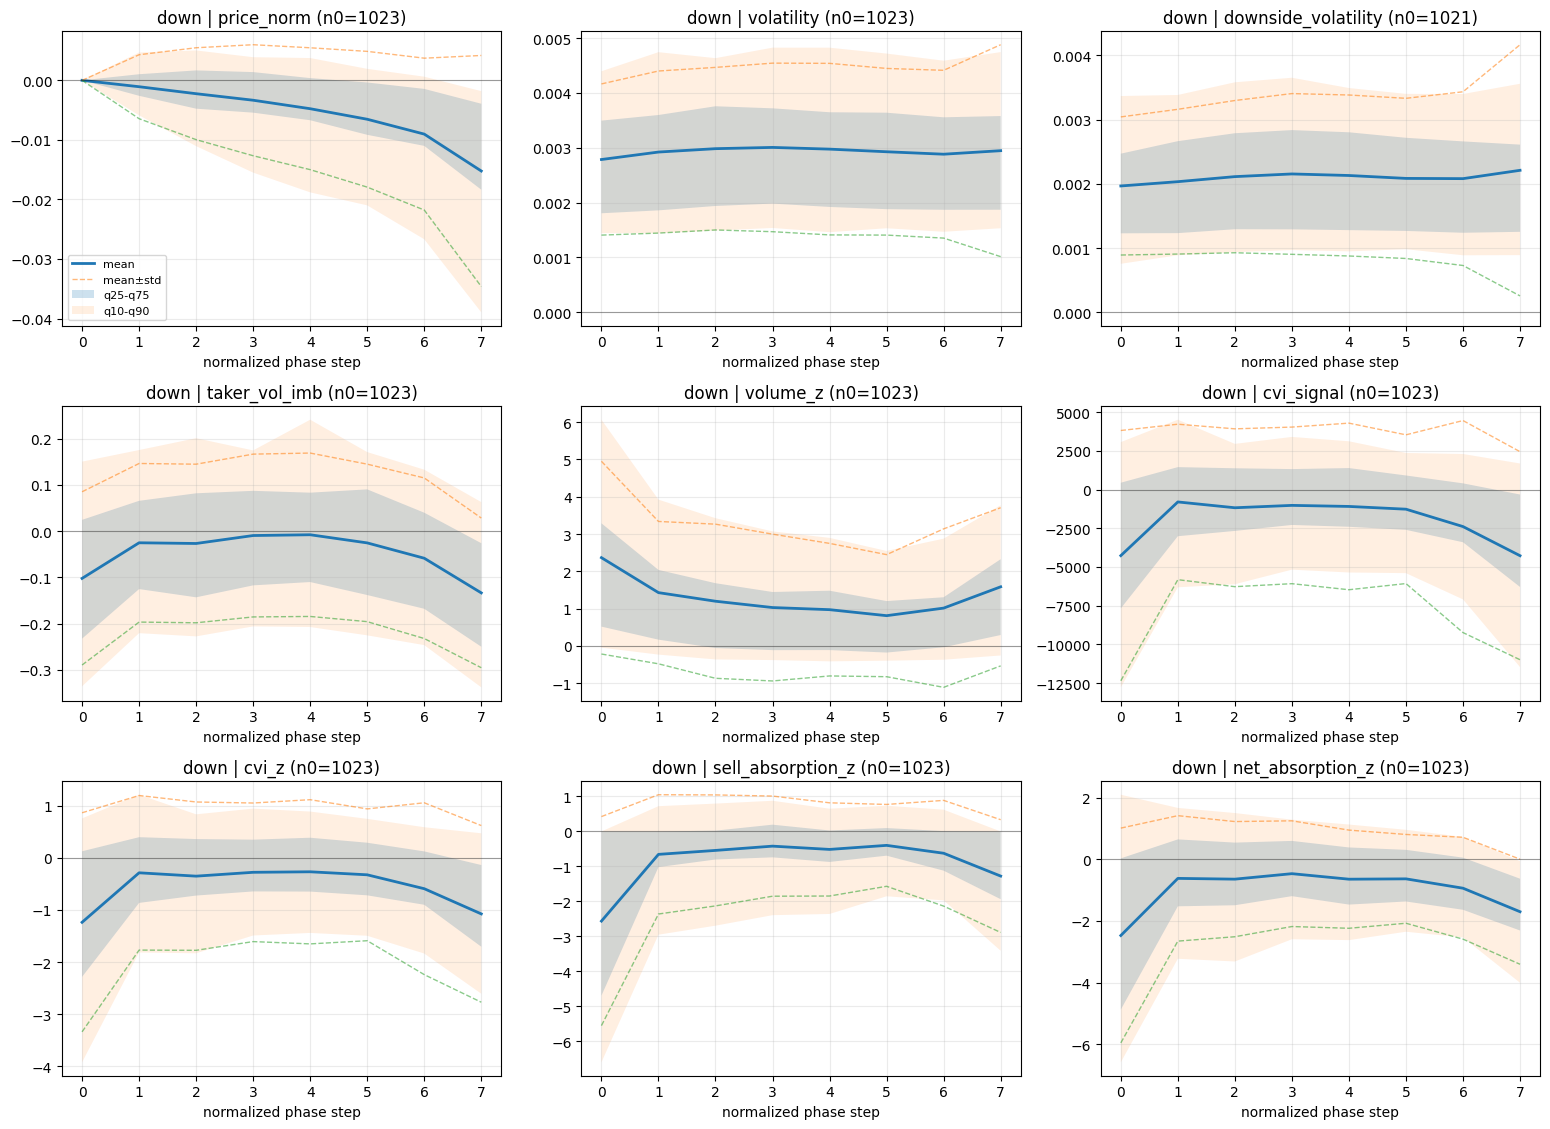

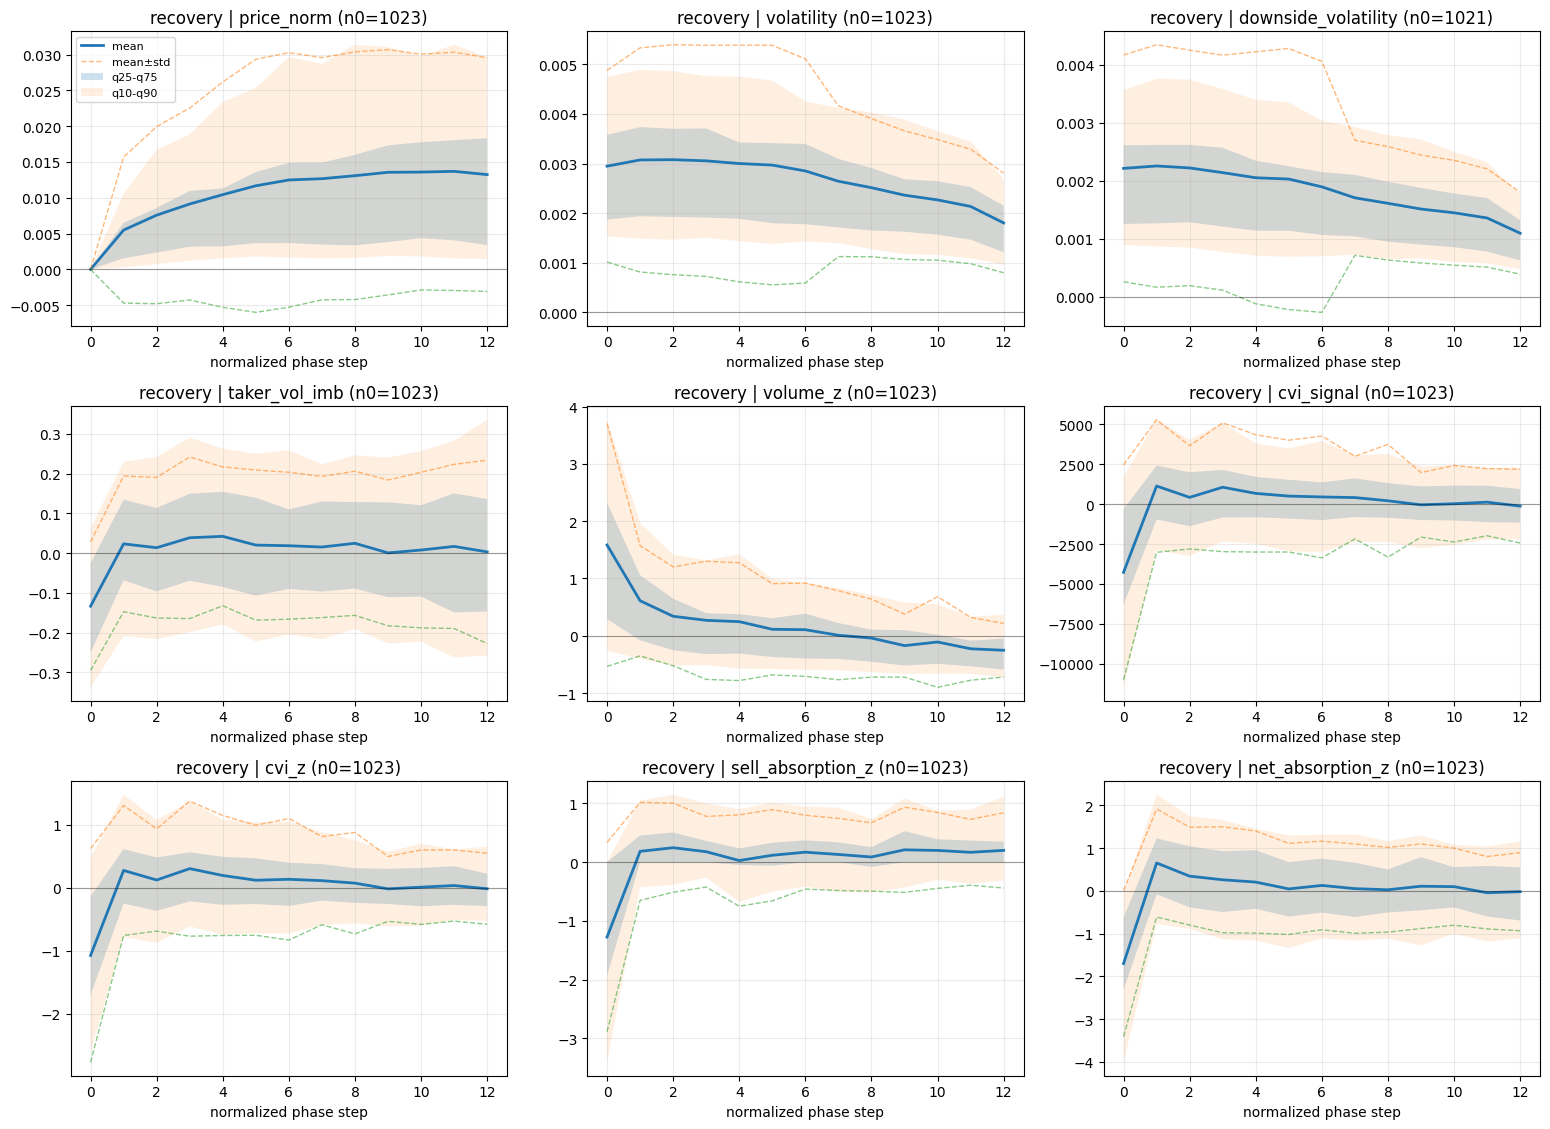

Signals used: ['panic_vol_q90', 'panic_vol_q90_volchg_pos', 'panic_vol_q90_beta_neg', 'panic_vol_q90_volchg_pos_beta_neg', 'panic_downside_vol_q90', 'panic_downside_vol_q90_volchg_pos', 'panic_downside_vol_q90_beta_neg', 'panic_downside_vol_q90_volchg_pos_beta_neg']
Events retained: 1023 | L_down(q20)=8, L_recovery(q20)=13
Duration summary:


dur_total                        \
                                               count       mean        std   
signal                                                                       
panic_downside_vol_q90                         151.0  54.145695  28.638295   
panic_downside_vol_q90_beta_neg                 99.0  58.636364  25.616263   
panic_downside_vol_q90_volchg_pos              138.0  54.079710  28.863652   
panic_downside_vol_q90_volchg_pos_beta_neg      90.0  57.822222  26.451812   
panic_vol_q90                                  141.0  55.957447  26.804017   
panic_vol_q90_beta_neg                         131.0  56.839695  25.911333   
panic_vol_q90_volchg_pos                       143.0  55.930070  26.914484   
panic_vol_q90_volchg_pos_beta_neg              130.0  56.538462  26.192831   

                                                                            \
                                             min    25%   50%    75%   max   
signal                                                                       
panic_downside_vol_q90                       6.0  28.00  49.0  80.00  97.0   
panic_downside_vol_q90_beta_neg             16.0  39.00  56.0  77.50  97.0   
panic_downside_vol_q90_volchg_pos            3.0  28.00  47.5  80.75  97.0   
panic_downside_vol_q90_volchg_pos_beta_neg  16.0  34.50  53.5  79.25  97.0   
panic_vol_q90                               13.0  31.00  51.0  77.00  97.0   
panic_vol_q90_beta_neg                      17.0  32.50  52.0  76.00  97.0   
panic_vol_q90_volchg_pos                     3.0  31.00  52.0  78.00  97.0   
panic_vol_q90_volchg_pos_beta_neg           14.0  31.25  52.0  76.00  97.0   

                                           dur_down             ...         \
                                              count       mean  ...    75%   
signal                                                          ...          
panic_downside_vol_q90                        151.0  21.476821  ...  29.50   
panic_downside_vol_q90_beta_neg                99.0  24.151515  ...  35.50   
panic_downside_vol_q90_volchg_pos             138.0  20.862319  ...  28.75   
panic_downside_vol_q90_volchg_pos_beta_neg     90.0  22.922222  ...  30.00   
panic_vol_q90                                 141.0  23.794326  ...  34.00   
panic_vol_q90_beta_neg                        131.0  24.938931  ...  34.00   
panic_vol_q90_volchg_pos                      143.0  23.559441  ...  34.00   
panic_vol_q90_volchg_pos_beta_neg             130.0  24.984615  ...  34.00   

                                                 dur_recovery             \
                                             max        count       mean   
signal                                                                     
panic_downside_vol_q90                      92.0        151.0  33.668874   
panic_downside_vol_q90_beta_neg             86.0         99.0  35.484848   
panic_downside_vol_q90_volchg_pos           92.0        138.0  34.217391   
panic_downside_vol_q90_volchg_pos_beta_neg  74.0         90.0  35.900000   
panic_vol_q90                               95.0        141.0  33.163121   
panic_vol_q90_beta_neg                      95.0        131.0  32.900763   
panic_vol_q90_volchg_pos                    95.0        143.0  33.370629   
panic_vol_q90_volchg_pos_beta_neg           95.0        130.0  32.553846   

                                                                         \
                                                  std  min    25%   50%   
signal                                                                    
panic_downside_vol_q90                      25.418818  2.0  14.00  26.0   
panic_downside_vol_q90_beta_neg             21.971393  2.0  20.00  31.0   
panic_downside_vol_q90_volchg_pos           25.311992  2.0  17.00  26.5   
panic_downside_vol_q90_volchg_pos_beta_neg  22.432946  2.0  20.25  31.0   
panic_vol_q90                               23.048590  2.0  17.00  26.0   
panic_vol_q90_beta_neg       

Feature-price synchrony (event-wise corr mean/std):


,phase,feature,n_events,corr_mean,corr_std
5,down,cvi_signal,1023,0.193709,0.526254
6,down,cvi_z,1023,0.180615,0.532052
2,down,taker_vol_imb,1023,0.170970,0.497055
7,down,net_absorption_z,1023,0.142101,0.540230
8,down,sell_absorption_z,1023,0.101358,0.536985
11,down,downside_vol_change_since_high,1023,0.040266,0.714009
1,down,downside_volatility,1023,0.032398,0.722037
3,down,volume_z,1023,-0.066073,0.568394
4,down,volume,1023,-0.104116,0.570541
10,down,long_vol_change_since_high,1023,-0.108154,0.714421


In [17]:
# Turning-point pipeline: entry->low and low->recovery (max 8h)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "sig_copy1" not in globals():
    raise RuntimeError("Run signal construction cell first (need sig_copy1).")

if "signal_masks" not in globals():
    raise RuntimeError("Run panic signal masks cell first (need signal_masks).")

# ------------------------ config ------------------------
MAX_HOURS = 8
BAR_MINUTES = 5
MAX_H = int(MAX_HOURS * 60 / BAR_MINUTES)  # 96 bars for 5m
EXIT_MODE = "vol_mean_revert_or_8h"  # or "hard_8h"
MIN_EVENTS_PER_SIGNAL = 20
PHASE_LEN_QUANTILE = 0.20  # "q20 length" for downsample target
MIN_RESAMPLE_LEN = 8

# choose signals to analyze
all_signals = list(signal_masks.keys())
signals_tp = [s for s in all_signals if s != "baseline_all_drawdown"]

# CVI signal (bar-wise): signed volume flow proxy
if "cvi_signal" not in sig_copy1.columns and {"volume", "taker_vol_imb"}.issubset(sig_copy1.columns):
    sig_copy1["cvi_signal"] = sig_copy1["volume"] * sig_copy1["taker_vol_imb"]

# optional stabilized CVI z-score for cross-feature comparability
if "cvi_signal" in sig_copy1.columns and "cvi_z" not in sig_copy1.columns:
    _cvi_mu = sig_copy1["cvi_signal"].rolling(288, min_periods=60).mean()
    _cvi_sd = sig_copy1["cvi_signal"].rolling(288, min_periods=60).std(ddof=0)
    sig_copy1["cvi_z"] = (sig_copy1["cvi_signal"] - _cvi_mu) / (_cvi_sd + 1e-12)

# feature candidates (only keep existing columns)
feat_candidates = [
    "volatility",
    "downside_volatility",
    "taker_vol_imb",
    "volume_z",
    "volume",
    "cvi_signal",
    "cvi_z",
    "net_absorption_z",
    "sell_absorption_z",
    "buy_absorption_z",
    "long_vol_change_since_high",
    "downside_vol_change_since_high",
]
features = [c for c in feat_candidates if c in sig_copy1.columns]

close_arr = sig_copy1["close"].to_numpy(dtype=float)
n = len(sig_copy1)

# optional exit signal (consistent with previous mean-revert idea)
if EXIT_MODE == "vol_mean_revert_or_8h" and "vol_mean_revert" in sig_copy1.columns:
    exit_mask_arr = sig_copy1["vol_mean_revert"].fillna(False).to_numpy(dtype=bool)
else:
    exit_mask_arr = np.zeros(n, dtype=bool)


def _entry_indices(mask: pd.Series) -> np.ndarray:
    m = mask.fillna(False).to_numpy(dtype=bool)
    prev = np.r_[False, m[:-1]]
    return np.flatnonzero(m & ~prev)


def _build_strategy_events(mask: pd.Series) -> list[tuple[int, int]]:
    """
    Strategy-consistent event builder:
    - enter at first trigger
    - ignore all new triggers while in position
    - exit by first mean-revert signal (if enabled) else hard 8h cap
    """
    entries = _entry_indices(mask)
    events = []
    i = 0
    while i < len(entries):
        s = int(entries[i])
        e_cap = min(n - 1, s + MAX_H)

        if EXIT_MODE == "vol_mean_revert_or_8h":
            hit = np.flatnonzero(exit_mask_arr[s + 1 : e_cap + 1])
            e = int(s + 1 + hit[0]) if len(hit) else int(e_cap)
        else:
            e = int(e_cap)

        if e > s:
            events.append((s, e))

        # skip all candidate entries happening while position is active
        while i < len(entries) and entries[i] <= e:
            i += 1

    return events


def _resample_1d(x: np.ndarray, target_len: int) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or target_len <= 0:
        return np.array([], dtype=float)
    if len(x) == 1:
        return np.repeat(x[0], target_len)
    t_old = np.arange(len(x), dtype=float)
    t_new = np.linspace(0, len(x) - 1, target_len)
    return np.interp(t_new, t_old, x)


def _path_stats(mat: np.ndarray) -> pd.DataFrame:
    rows = []
    for t in range(mat.shape[1]):
        x = mat[:, t]
        x = x[np.isfinite(x)]
        if len(x) == 0:
            rows.append({"t": t, "n": 0, "mean": np.nan, "std": np.nan, "q10": np.nan, "q25": np.nan, "q75": np.nan, "q90": np.nan})
        else:
            xs = pd.Series(x)
            rows.append({
                "t": t,
                "n": int(len(xs)),
                "mean": float(xs.mean()),
                "std": float(xs.std(ddof=0)),
                "q10": float(xs.quantile(0.10)),
                "q25": float(xs.quantile(0.25)),
                "q75": float(xs.quantile(0.75)),
                "q90": float(xs.quantile(0.90)),
            })
    return pd.DataFrame(rows)


def _event_feature_paths(s: int, e: int, cols: list[str]) -> dict[str, np.ndarray]:
    out = {}
    for c in cols:
        out[c] = sig_copy1[c].to_numpy(dtype=float)[s : e + 1]
    return out


# ------------------------ build events ------------------------
events_by_signal = {}
for sig in signals_tp:
    m = signal_masks[sig]
    ev = _build_strategy_events(m)
    if len(ev) >= MIN_EVENTS_PER_SIGNAL:
        events_by_signal[sig] = ev

if not events_by_signal:
    raise RuntimeError("No signal has enough events under current filter. Lower MIN_EVENTS_PER_SIGNAL.")

# event-level split and aligned panels
phase_store = {
    # phase -> feature -> list[np.ndarray]
    "down": {"price_norm": []},
    "recovery": {"price_norm": []},
}
for ph in phase_store:
    for f in features:
        phase_store[ph][f] = []

event_rows = []

for sig, evs in events_by_signal.items():
    for ev_id, (s, e) in enumerate(evs):
        p = close_arr[s : e + 1]
        if len(p) < 3 or not np.isfinite(p).all() or p[0] <= 0:
            continue

        low_rel = int(np.argmin(p))
        low_idx = s + low_rel

        # must have both segments with at least 2 points
        if low_idx <= s or low_idx >= e:
            continue

        down_slice = (s, low_idx)
        rec_slice = (low_idx, e)

        p_down = close_arr[down_slice[0] : down_slice[1] + 1]
        p_rec = close_arr[rec_slice[0] : rec_slice[1] + 1]
        p_down_norm = p_down / p_down[0] - 1.0
        p_rec_norm = p_rec / p_rec[0] - 1.0

        event_rows.append({
            "signal": sig,
            "event_id": ev_id,
            "s": s,
            "e": e,
            "low": low_idx,
            "dur_total": e - s + 1,
            "dur_down": down_slice[1] - down_slice[0] + 1,
            "dur_recovery": rec_slice[1] - rec_slice[0] + 1,
        })

        phase_store["down"]["price_norm"].append(p_down_norm)
        phase_store["recovery"]["price_norm"].append(p_rec_norm)

        feat_paths = _event_feature_paths(s, e, features)
        for f in features:
            x = feat_paths[f]
            phase_store["down"][f].append(x[: low_rel + 1])
            phase_store["recovery"][f].append(x[low_rel:])

event_df_tp = pd.DataFrame(event_rows)
if len(event_df_tp) == 0:
    raise RuntimeError("No valid events after split-to-low/recovery constraints.")

# target resample lengths by q20 of phase durations
L_down = int(np.clip(np.nanquantile(event_df_tp["dur_down"], PHASE_LEN_QUANTILE), MIN_RESAMPLE_LEN, MAX_H))
L_rec = int(np.clip(np.nanquantile(event_df_tp["dur_recovery"], PHASE_LEN_QUANTILE), MIN_RESAMPLE_LEN, MAX_H))

# aligned matrices and stats
aligned_stats = {}
for phase, L in [("down", L_down), ("recovery", L_rec)]:
    aligned_stats[phase] = {}
    for f, paths in phase_store[phase].items():
        if len(paths) == 0:
            continue
        mats = np.vstack([_resample_1d(p, L) for p in paths if len(p) >= 2])
        aligned_stats[phase][f] = {
            "matrix": mats,
            "stats": _path_stats(mats),
        }

# ------------------------ synchrony check ------------------------
sync_rows = []
for phase in ["down", "recovery"]:
    if "price_norm" not in aligned_stats[phase]:
        continue
    pmat = aligned_stats[phase]["price_norm"]["matrix"]
    for f in features:
        if f not in aligned_stats[phase]:
            continue
        fmat = aligned_stats[phase][f]["matrix"]
        k = min(len(pmat), len(fmat))
        corrs = []
        for i in range(k):
            x, y = pmat[i], fmat[i]
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() < 3:
                continue
            c = np.corrcoef(x[m], y[m])[0, 1]
            if np.isfinite(c):
                corrs.append(c)
        sync_rows.append({
            "phase": phase,
            "feature": f,
            "n_events": int(k),
            "corr_mean": float(np.mean(corrs)) if len(corrs) else np.nan,
            "corr_std": float(np.std(corrs)) if len(corrs) else np.nan,
        })

sync_df = pd.DataFrame(sync_rows).sort_values(["phase", "corr_mean"], ascending=[True, False])

# ------------------------ plots ------------------------
plot_feats = [
    "price_norm",
    "volatility",
    "downside_volatility",
    "taker_vol_imb",
    "volume_z",
    "cvi_signal",
    "cvi_z",
    "sell_absorption_z",
    "net_absorption_z",
]
plot_feats = [f for f in plot_feats if f == "price_norm" or f in features]

for phase in ["down", "recovery"]:
    cols = [f for f in plot_feats if f in aligned_stats[phase]]
    if not cols:
        continue

    ncols = 3
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, f in zip(axes, cols):
        st = aligned_stats[phase][f]["stats"]
        x = st["t"].to_numpy()
        mu = st["mean"].to_numpy()
        sd = st["std"].to_numpy()

        ax.plot(x, mu, lw=2.0, label="mean")
        ax.plot(x, mu + sd, lw=1.0, ls="--", alpha=0.55, label="mean±std")
        ax.plot(x, mu - sd, lw=1.0, ls="--", alpha=0.55)
        ax.fill_between(x, st["q25"], st["q75"], alpha=0.22, label="q25-q75")
        ax.fill_between(x, st["q10"], st["q90"], alpha=0.12, label="q10-q90")
        ax.axhline(0, color="black", lw=0.8, alpha=0.35)
        ax.set_title(f"{phase} | {f} (n0={int(st['n'].iloc[0])})")
        ax.set_xlabel("normalized phase step")
        ax.grid(alpha=0.25)
        if f == cols[0]:
            ax.legend(fontsize=8, loc="best")

    for j in range(len(cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

print(f"Signals used: {list(events_by_signal.keys())}")
print(f"Events retained: {len(event_df_tp)} | L_down(q20)={L_down}, L_recovery(q20)={L_rec}")
print("Duration summary:")
display(event_df_tp[["signal", "dur_total", "dur_down", "dur_recovery"]].groupby("signal").describe())

print("Feature-price synchrony (event-wise corr mean/std):")
display(sync_df)

# keep outputs
tp_events = event_df_tp.copy()
tp_aligned_stats = aligned_stats
tp_sync_df = sync_df.copy()


## Strategy Prototype: Panic Entry + Turning Confirmation (Backtest)

根据 turning-point 结果，优先使用与价格恢复同步度较高的信号作为拐点确认：
- `sell_absorption_z`
- `cvi_z` / `cvi_signal`
- `net_absorption_z`

回测采用事件驱动：
- 先由 panic 信号定义候选事件；
- 在事件早期窗口内出现 turning-confirmation 才开仓（否则放弃该事件）；
- 平仓按 `e+1`（`e` 是 signal end）执行；
- 交易成本按双边 bps 扣减。

Panic->Short then Turn->Long scan (filtered n_legs>=80):


,panic_signal,n_legs,n_short,n_long,mean,median,q10,win_rate,cum_ret,fixed_h,vol_q_exit,exit_mode,score
74,panic_vol_q90,338,169,169,0.000287,-0.000195,-0.009371,0.482249,0.064652,6,0.5,hybrid_min,-0.002368
73,panic_vol_q90,338,169,169,0.000284,-0.000195,-0.009371,0.482249,0.063638,6,0.5,vol_only,-0.002369
76,panic_vol_q90,352,176,176,-0.000267,-0.000366,-0.009138,0.468750,-0.117887,6,0.6,vol_only,-0.002534
77,panic_vol_q90,352,176,176,-0.000267,-0.000366,-0.009138,0.468750,-0.117887,6,0.6,hybrid_min,-0.002534
85,panic_vol_q90,334,167,167,-0.000021,-0.000425,-0.009622,0.473054,-0.036723,8,0.5,vol_only,-0.002623
86,panic_vol_q90,334,167,167,-0.000021,-0.000425,-0.009622,0.473054,-0.036723,8,0.5,hybrid_min,-0.002623
80,panic_vol_q90,336,168,168,0.000059,-0.000425,-0.010066,0.473214,-0.013078,7,0.5,hybrid_min,-0.002714
79,panic_vol_q90,336,168,168,0.000058,-0.000425,-0.010066,0.473214,-0.013565,7,0.5,vol_only,-0.002715
88,panic_vol_q90,348,174,174,-0.000337,-0.000425,-0.010001,0.465517,-0.135807,8,0.6,vol_only,-0.002797
89,panic_vol_q90,348,174,174,-0.000356,-0.000425,-0.010001,0.465517,-0.141908,8,0.6,hybrid_min,-0.002802


Best config:


,panic_signal,n_legs,n_short,n_long,mean,median,q10,win_rate,cum_ret,fixed_h,vol_q_exit,exit_mode,score
74,panic_vol_q90,338,169,169,0.000287,-0.000195,-0.009371,0.482249,0.064652,6,0.5,hybrid_min,-0.002368


Best config trade sample:


,panic_signal,leg,s,entry_i,exit_i,entry_ts,exit_ts,ret_gross,ret_net,hold_bars,fixed_h,vol_q_exit,exit_mode,turn_i,equity
0,panic_vol_q90,short_to_turn,385,386,389,2026-01-02 00:10:00+00:00,2026-01-02 00:25:00+00:00,-0.000553,-0.001153,3,6,0.5,hybrid_min,NaN,0.998847
1,panic_vol_q90,turn_to_long_exit,385,389,452,2026-01-02 00:25:00+00:00,2026-01-02 05:40:00+00:00,0.002529,0.001929,63,6,0.5,hybrid_min,388.0,1.000773
2,panic_vol_q90,short_to_turn,495,496,499,2026-01-02 09:20:00+00:00,2026-01-02 09:35:00+00:00,0.000546,-0.000054,3,6,0.5,hybrid_min,NaN,1.000719
3,panic_vol_q90,turn_to_long_exit,495,499,526,2026-01-02 09:35:00+00:00,2026-01-02 11:50:00+00:00,-0.001638,-0.002238,27,6,0.5,hybrid_min,498.0,0.998480
4,panic_vol_q90,short_to_turn,558,559,562,2026-01-02 14:35:00+00:00,2026-01-02 14:50:00+00:00,-0.007691,-0.008291,3,6,0.5,hybrid_min,NaN,0.990201
5,panic_vol_q90,turn_to_long_exit,558,562,634,2026-01-02 14:50:00+00:00,2026-01-02 20:50:00+00:00,0.016392,0.015792,72,6,0.5,hybrid_min,561.0,1.005839
6,panic_vol_q90,short_to_turn,962,963,965,2026-01-04 00:15:00+00:00,2026-01-04 00:25:00+00:00,0.002465,0.001865,2,6,0.5,hybrid_min,NaN,1.007715
7,panic_vol_q90,turn_to_long_exit,962,965,994,2026-01-04 00:25:00+00:00,2026-01-04 02:50:00+00:00,-0.002241,-0.002841,29,6,0.5,hybrid_min,964.0,1.004852
8,panic_vol_q90,short_to_turn,1190,1191,1193,2026-01-04 19:15:00+00:00,2026-01-04 19:25:00+00:00,-0.001874,-0.002474,2,6,0.5,hybrid_min,NaN,1.002367
9,panic_vol_q90,turn_to_long_exit,1190,1193,1214,2026-01-04 19:25:00+00:00,2026-01-04 21:10:00+00:00,0.005920,0.005320,21,6,0.5,hybrid_min,1192.0,1.007699


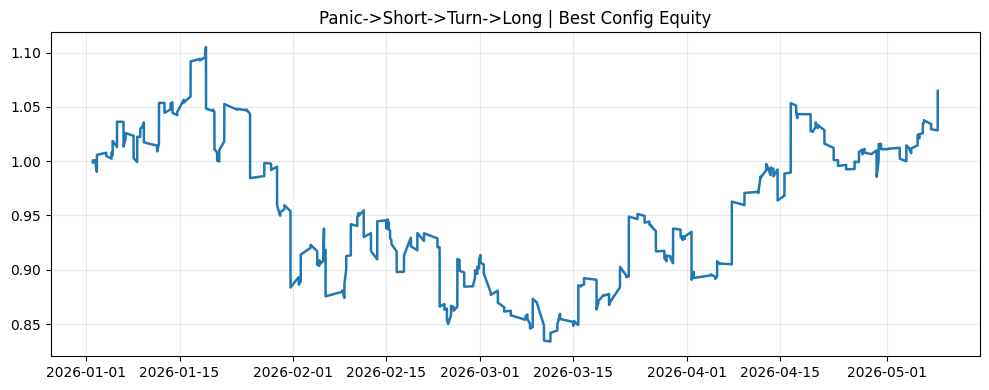

In [19]:
# Backtest v2: panic -> short, turning point -> long, then exit by (fixed / vol-quantile)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

if "sig_copy1" not in globals() or "signal_masks" not in globals():
    raise RuntimeError("Run signal construction cells first (need sig_copy1 and signal_masks).")

# ---------- setup ----------
df_bt = sig_copy1.copy()
close = df_bt["close"].to_numpy(dtype=float)
idx = df_bt.index
n = len(df_bt)
BAR_MIN = 5

# make sure turning features exist
if "cvi_signal" not in df_bt.columns and {"volume", "taker_vol_imb"}.issubset(df_bt.columns):
    df_bt["cvi_signal"] = df_bt["volume"] * df_bt["taker_vol_imb"]
if "cvi_signal" in df_bt.columns and "cvi_z" not in df_bt.columns:
    _mu = df_bt["cvi_signal"].rolling(288, min_periods=60).mean()
    _sd = df_bt["cvi_signal"].rolling(288, min_periods=60).std(ddof=0)
    df_bt["cvi_z"] = (df_bt["cvi_signal"] - _mu) / (_sd + 1e-12)

# vol quantile exits: q50 / q60 rolling threshold
if "volatility" not in df_bt.columns:
    raise RuntimeError("volatility column missing.")
if "vol_q50_dyn" not in df_bt.columns:
    df_bt["vol_q50_dyn"] = df_bt["volatility"].rolling(288, min_periods=72).quantile(0.50)
if "vol_q60_dyn" not in df_bt.columns:
    df_bt["vol_q60_dyn"] = df_bt["volatility"].rolling(288, min_periods=72).quantile(0.60)

vol_arr = df_bt["volatility"].to_numpy(dtype=float)
vol_q50 = df_bt["vol_q50_dyn"].to_numpy(dtype=float)
vol_q60 = df_bt["vol_q60_dyn"].to_numpy(dtype=float)

# panic signal candidates
panic_candidates = [
    "panic_downside_vol_q90_volchg_pos_beta_neg",
    "panic_downside_vol_q90_beta_neg",
    "panic_vol_q90_volchg_pos_beta_neg",
    "panic_vol_q90_beta_neg",
    "panic_vol_q90",
]
panic_candidates = [s for s in panic_candidates if s in signal_masks]
if not panic_candidates:
    panic_candidates = [s for s in signal_masks.keys() if "panic" in s and "baseline" not in s]


def _leading_edge(mask: pd.Series) -> np.ndarray:
    m = mask.fillna(False).to_numpy(dtype=bool)
    prev = np.r_[False, m[:-1]]
    return np.flatnonzero(m & ~prev)


turn_features = [c for c in ["net_absorption_z", "sell_absorption_z", "cvi_signal", "cvi_z"] if c in df_bt.columns]
turn_arrays = {c: df_bt[c].to_numpy(dtype=float) for c in turn_features}


def _cross_neg_to_pos(arr: np.ndarray, t: int) -> bool:
    if t <= 0 or t >= len(arr):
        return False
    prev_v = arr[t - 1]
    cur_v = arr[t]
    return np.isfinite(prev_v) and np.isfinite(cur_v) and (prev_v < 0.0) and (cur_v >= 0.0)


def _first_turn_idx(i_start: int, i_end: int) -> int:
    """First bar t in [i_start, i_end] where any turn feature crosses neg->pos."""
    if len(turn_arrays) == 0:
        return -1
    lo = max(1, i_start)
    hi = min(i_end, n - 1)
    for t in range(lo, hi + 1):
        for arr in turn_arrays.values():
            if _cross_neg_to_pos(arr, t):
                return t
    return -1


def _run_panic_short_turn_long(
    panic_name: str,
    fixed_h_hours: int,
    vol_q_exit: float,
    exit_mode: str = "hybrid_min",  # fixed_only / vol_only / hybrid_min
    short_max_hours: int = 8,
    fee_bps_per_side: float = 3.0,
):
    panic_edges = _leading_edge(signal_masks[panic_name])

    H_fix = int(fixed_h_hours * 60 / BAR_MIN)
    H_short_max = int(short_max_hours * 60 / BAR_MIN)
    vol_ref = vol_q50 if abs(vol_q_exit - 0.5) < 1e-9 else vol_q60

    fee_side = fee_bps_per_side / 1e4

    pos = 0  # 0 flat, -1 short, +1 long
    i = 0
    trades = []
    current = {}

    while i < n - 2:
        if pos == 0:
            # first panic edge at/after i
            jidx = panic_edges[panic_edges >= i]
            if len(jidx) == 0:
                break
            s = int(jidx[0])
            entry_short = s + 1
            if entry_short >= n - 1:
                break
            if not np.isfinite(close[entry_short]) or close[entry_short] <= 0:
                i = s + 1
                continue

            pos = -1
            current = {
                "panic_signal": panic_name,
                "s": s,
                "short_entry_i": entry_short,
                "short_entry_px": float(close[entry_short]),
            }
            i = entry_short + 1
            continue

        if pos == -1:
            # find first turning point while short, capped by short_max horizon
            # turning point = any of [net_absorption_z, sell_absorption_z, cvi_signal, cvi_z] crosses neg->pos
            s = current["s"]
            t_end = min(n - 2, s + H_short_max)
            t_turn = _first_turn_idx(i, t_end)

            if t_turn < 0:
                # no turning: force close short at cap and reset
                ex_i = t_end + 1
                if ex_i < n and np.isfinite(close[ex_i]) and close[ex_i] > 0:
                    ret_short = current["short_entry_px"] / close[ex_i] - 1.0
                    ret_short_net = ret_short - 2 * fee_side
                    trades.append({
                        "panic_signal": panic_name,
                        "leg": "short_only",
                        "s": current["s"],
                        "entry_i": current["short_entry_i"],
                        "exit_i": ex_i,
                        "entry_ts": idx[current["short_entry_i"]],
                        "exit_ts": idx[ex_i],
                        "ret_gross": float(ret_short),
                        "ret_net": float(ret_short_net),
                        "hold_bars": int(ex_i - current["short_entry_i"]),
                        "fixed_h": fixed_h_hours,
                        "vol_q_exit": vol_q_exit,
                        "exit_mode": exit_mode,
                    })
                pos = 0
                current = {}
                i = ex_i + 1
                continue

            rev_i = t_turn + 1  # reverse at next close
            if rev_i >= n - 1 or not np.isfinite(close[rev_i]) or close[rev_i] <= 0:
                pos = 0
                current = {}
                i = rev_i + 1
                continue

            # close short leg at reversal
            ret_short = current["short_entry_px"] / close[rev_i] - 1.0
            ret_short_net = ret_short - 2 * fee_side
            trades.append({
                "panic_signal": panic_name,
                "leg": "short_to_turn",
                "s": current["s"],
                "entry_i": current["short_entry_i"],
                "exit_i": rev_i,
                "entry_ts": idx[current["short_entry_i"]],
                "exit_ts": idx[rev_i],
                "ret_gross": float(ret_short),
                "ret_net": float(ret_short_net),
                "hold_bars": int(rev_i - current["short_entry_i"]),
                "fixed_h": fixed_h_hours,
                "vol_q_exit": vol_q_exit,
                "exit_mode": exit_mode,
            })

            # open long leg at same reversal execution point
            pos = 1
            current = {
                "panic_signal": panic_name,
                "s": current["s"],
                "turn_i": t_turn,
                "long_entry_i": rev_i,
                "long_entry_px": float(close[rev_i]),
            }
            i = rev_i + 1
            continue

        if pos == 1:
            le = current["long_entry_i"]
            ex_fix = min(n - 1, le + H_fix)

            # vol exit: first t with vol <= vol_qX, execute t+1
            cand_v = np.flatnonzero((vol_arr[i : ex_fix + 1] <= vol_ref[i : ex_fix + 1]) & np.isfinite(vol_arr[i : ex_fix + 1]) & np.isfinite(vol_ref[i : ex_fix + 1]))
            ex_vol = int(i + cand_v[0] + 1) if len(cand_v) else None
            if ex_vol is not None:
                ex_vol = min(ex_vol, n - 1)

            if exit_mode == "fixed_only":
                ex_i = ex_fix
            elif exit_mode == "vol_only":
                ex_i = ex_vol if ex_vol is not None else ex_fix
            else:  # hybrid_min
                ex_i = min(ex_fix, ex_vol) if ex_vol is not None else ex_fix

            if ex_i <= le or ex_i >= n or (not np.isfinite(close[ex_i])) or close[ex_i] <= 0:
                pos = 0
                current = {}
                i = max(i + 1, le + 1)
                continue

            ret_long = close[ex_i] / current["long_entry_px"] - 1.0
            ret_long_net = ret_long - 2 * fee_side
            trades.append({
                "panic_signal": panic_name,
                "leg": "turn_to_long_exit",
                "s": current["s"],
                "turn_i": current["turn_i"],
                "entry_i": le,
                "exit_i": ex_i,
                "entry_ts": idx[le],
                "exit_ts": idx[ex_i],
                "ret_gross": float(ret_long),
                "ret_net": float(ret_long_net),
                "hold_bars": int(ex_i - le),
                "fixed_h": fixed_h_hours,
                "vol_q_exit": vol_q_exit,
                "exit_mode": exit_mode,
            })

            pos = 0
            current = {}
            i = ex_i + 1
            continue

    td = pd.DataFrame(trades)
    if len(td) == 0:
        return td, {
            "panic_signal": panic_name,
            "n_legs": 0,
            "n_short": 0,
            "n_long": 0,
            "mean": np.nan,
            "median": np.nan,
            "q10": np.nan,
            "win_rate": np.nan,
            "cum_ret": np.nan,
            "fixed_h": fixed_h_hours,
            "vol_q_exit": vol_q_exit,
            "exit_mode": exit_mode,
        }

    r = td["ret_net"]
    out = {
        "panic_signal": panic_name,
        "n_legs": int(len(td)),
        "n_short": int((td["leg"].str.contains("short")).sum()),
        "n_long": int((td["leg"] == "turn_to_long_exit").sum()),
        "mean": float(r.mean()),
        "median": float(r.median()),
        "q10": float(r.quantile(0.10)),
        "win_rate": float((r > 0).mean()),
        "cum_ret": float(np.prod(1 + r.to_numpy()) - 1.0),
        "fixed_h": fixed_h_hours,
        "vol_q_exit": vol_q_exit,
        "exit_mode": exit_mode,
    }
    return td, out


# ---------------- scan ----------------
scan_rows = []
trade_cache = {}

param_grid = list(product(
    panic_candidates,
    [6, 7, 8],      # fixed-h exit in hours
    [0.5, 0.6],     # vol quantile exit (q50/q60)
    ["fixed_only", "vol_only", "hybrid_min"],
))

for sig, hfix, vq, mode in param_grid:
    td, sm = _run_panic_short_turn_long(
        sig,
        fixed_h_hours=hfix,
        vol_q_exit=vq,
        exit_mode=mode,
        short_max_hours=8,
        fee_bps_per_side=3.0,
    )
    scan_rows.append(sm)
    trade_cache[(sig, hfix, vq, mode)] = td

panic_turn_scan = pd.DataFrame(scan_rows)

rank = panic_turn_scan.copy()
rank = rank[rank["n_legs"] >= 80].copy()
rank["score"] = rank["median"].fillna(-1) * 0.5 + rank["q10"].fillna(-1) * 0.25 + rank["mean"].fillna(-1) * 0.25
rank = rank.sort_values(["score", "n_legs"], ascending=[False, False])

print("Panic->Short then Turn->Long scan (filtered n_legs>=80):")
display(rank.head(30))

if len(rank):
    best = rank.iloc[0]
    key = (
        best["panic_signal"],
        int(best["fixed_h"]),
        float(best["vol_q_exit"]),
        best["exit_mode"],
    )
    best_trades = trade_cache[key].copy()
    best_trades["equity"] = (1.0 + best_trades["ret_net"]).cumprod()

    print("Best config:")
    display(pd.DataFrame([best]))

    print("Best config trade sample:")
    display(best_trades.head(25))

    plt.figure(figsize=(10, 4))
    plt.plot(best_trades["entry_ts"], best_trades["equity"], lw=1.8)
    plt.title("Panic->Short->Turn->Long | Best Config Equity")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# keep outputs
panic_turn_rank = rank.copy()
if "best_trades" in locals():
    panic_turn_best_trades = best_trades.copy()
